# 03 — Interaction Effects and Combination Synergies

This notebook analyzes **pairwise interaction effects** and **combination-level behavior** across modeling strategies.  
The main goal is to move beyond marginal effects and identify whether specific design choices reinforce or weaken each other under a fair comparison framework.

This notebook assumes that **Notebook 01** exported the consolidated `results_seed_level.csv` table and that **Notebook 02** may already have generated factor-level summaries.  
The analyses here focus on metrics that remain comparable across validation strategies, including reconstructed LOO metrics when applicable.

## Main objectives

1. Quantify pairwise interactions between major pipeline components.
2. Identify favorable and unfavorable combinations.
3. Evaluate whether some factors are only beneficial under specific contexts.
4. Produce figures and tables directly reusable in the Results section.


In [12]:
from __future__ import annotations

from pathlib import Path
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_context("talk")
sns.set_style("whitegrid")


In [13]:
# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
PROJECT_ROOT = Path("/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers")
if not (PROJECT_ROOT / "notebooks").exists():
    candidates = [p for p in PROJECT_ROOT.rglob("notebooks/modelling") if p.is_dir()]
    if candidates:
        PROJECT_ROOT = candidates[0].parents[1]

MODELLING_DIR = PROJECT_ROOT / "notebooks" / "modelling"
TABLES_DIR = MODELLING_DIR / "analysis_tables"
FIG_DIR = MODELLING_DIR / "analysis_figures" / "03_interaction_effects"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = TABLES_DIR / "results_seed_level.csv"
RESULTS_SUMMARY_PATH = TABLES_DIR / "results_config_summary.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_PATH exists:", RESULTS_PATH.exists())
print("FIG_DIR:", FIG_DIR)


PROJECT_ROOT: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers
RESULTS_PATH exists: True
FIG_DIR: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects


In [14]:
# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {RESULTS_PATH}. Run Notebook 01 first and ensure it exports results_seed_level.csv."
    )

df = pd.read_csv(RESULTS_PATH)
print(df.shape)
df.head()


(2000588, 34)


,dataset_variant,config_name,run_id,combo_id,val_strategy,seed,threshold,model_key,model_class,model_params,imputer,scaler,pca,pca_params,resampling,resampling_params,n_evaluation_units,n_train,n_test,pos_rate_test,tn,fp,fn,tp,roc_auc,pr_auc,mcc,brier,accuracy,balanced_accuracy,precision,recall,f1,loo_metric_source
0,IMPUTED,config_kfold,20260202_032849,1,kfold,4.781633e+08,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,106,10,24,20,0.803034,0.659453,0.411356,0.151723,0.78750,0.681884,0.658889,0.450000,0.507512,reported_fold_mean
1,IMPUTED,config_kfold,20260202_032849,2,kfold,1.122457e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,107,9,25,19,0.820018,0.680020,0.423810,0.148044,0.78750,0.676510,0.707302,0.430556,0.518162,reported_fold_mean
2,IMPUTED,config_kfold,20260202_032849,3,kfold,1.988882e+08,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,107,9,23,21,0.825377,0.663983,0.462220,0.143389,0.80000,0.700302,0.732698,0.477778,0.545664,reported_fold_mean
3,IMPUTED,config_kfold,20260202_032849,4,kfold,1.648071e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,106,10,21,23,0.814538,0.679425,0.481473,0.148196,0.80625,0.717995,0.697619,0.522222,0.595462,reported_fold_mean
4,IMPUTED,config_kfold,20260202_032849,5,kfold,2.013804e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,103,13,26,18,0.801283,0.652545,0.335151,0.154048,0.75625,0.649577,0.586508,0.411111,0.457560,reported_fold_mean


In [15]:
# ---------------------------------------------------------------------
# Column harmonization helpers
# ---------------------------------------------------------------------
def find_first_existing(candidates: list[str], columns: list[str]) -> str | None:
    for c in candidates:
        if c in columns:
            return c
    return None

DATASET_COL = find_first_existing(
    ["dataset_variant", "dataset_name", "dataset_key", "dataset"], df.columns.tolist()
)
CONFIG_COL = find_first_existing(
    ["config_name", "validation_config", "config"], df.columns.tolist()
)
MODEL_COL = find_first_existing(
    ["model_key", "model_class", "model_name"], df.columns.tolist()
)
SCALER_COL = find_first_existing(
    ["scaler"], df.columns.tolist()
)
RESAMPLING_COL = find_first_existing(
    ["resampling"], df.columns.tolist()
)
PCA_COL = find_first_existing(
    ["pca"], df.columns.tolist()
)
SEED_COL = find_first_existing(
    ["seed"], df.columns.tolist()
)

required_context = [DATASET_COL, CONFIG_COL, MODEL_COL, SCALER_COL, RESAMPLING_COL, PCA_COL, SEED_COL]
missing_context = [c for c in required_context if c is None]
if missing_context:
    raise ValueError(f"Missing required context columns: {missing_context}")

METRIC_CANDIDATES = ["mcc", "balanced_accuracy", "f1", "accuracy", "precision", "recall"]
AVAILABLE_METRICS = [m for m in METRIC_CANDIDATES if m in df.columns]
if not AVAILABLE_METRICS:
    raise ValueError("No comparable metrics were found in the consolidated table.")

PRIMARY_METRIC = "mcc" if "mcc" in AVAILABLE_METRICS else AVAILABLE_METRICS[0]

print("Resolved columns:")
print({
    "DATASET_COL": DATASET_COL,
    "CONFIG_COL": CONFIG_COL,
    "MODEL_COL": MODEL_COL,
    "SCALER_COL": SCALER_COL,
    "RESAMPLING_COL": RESAMPLING_COL,
    "PCA_COL": PCA_COL,
    "SEED_COL": SEED_COL,
    "PRIMARY_METRIC": PRIMARY_METRIC,
    "AVAILABLE_METRICS": AVAILABLE_METRICS,
})


Resolved columns:
{'DATASET_COL': 'dataset_variant', 'CONFIG_COL': 'config_name', 'MODEL_COL': 'model_key', 'SCALER_COL': 'scaler', 'RESAMPLING_COL': 'resampling', 'PCA_COL': 'pca', 'SEED_COL': 'seed', 'PRIMARY_METRIC': 'mcc', 'AVAILABLE_METRICS': ['mcc', 'balanced_accuracy', 'f1', 'accuracy', 'precision', 'recall']}


In [16]:
# ---------------------------------------------------------------------
# Basic cleaning and standardization
# ---------------------------------------------------------------------
analysis_df = df.copy()

for col in [DATASET_COL, CONFIG_COL, MODEL_COL, SCALER_COL, RESAMPLING_COL, PCA_COL]:
    analysis_df[col] = analysis_df[col].astype(str).fillna("missing")

analysis_df[PCA_COL] = (
    analysis_df[PCA_COL]
    .replace({"True": "pca_on", "False": "pca_off", "1": "pca_on", "0": "pca_off"})
    .fillna("unknown")
    .astype(str)
)

# Keep only rows with non-null primary metric for interaction analyses
analysis_df = analysis_df[analysis_df[PRIMARY_METRIC].notna()].copy()

print("Filtered analysis_df shape:", analysis_df.shape)
analysis_df[[DATASET_COL, CONFIG_COL, MODEL_COL, SCALER_COL, RESAMPLING_COL, PCA_COL, PRIMARY_METRIC]].head()


Filtered analysis_df shape: (2000409, 34)


,dataset_variant,config_name,model_key,scaler,resampling,pca,mcc
0,IMPUTED,config_kfold,LogisticRegression,none,none,off,0.411356
1,IMPUTED,config_kfold,LogisticRegression,none,none,off,0.423810
2,IMPUTED,config_kfold,LogisticRegression,none,none,off,0.462220
3,IMPUTED,config_kfold,LogisticRegression,none,none,off,0.481473
4,IMPUTED,config_kfold,LogisticRegression,none,none,off,0.335151


## Helper functions

The following utilities generate summary tables, effect contrasts, and interaction heatmaps.  
The focus is on **mean performance**, **variability**, and **sample support** per combination.


In [17]:
def save_current_figure(name: str) -> Path:
    outpath = FIG_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    return outpath


def summarize_pairwise_interaction(
    data: pd.DataFrame,
    row_factor: str,
    col_factor: str,
    metric: str,
) -> pd.DataFrame:
    grouped = (
        data.groupby([row_factor, col_factor], dropna=False)[metric]
        .agg(["mean", "std", "count", "median"])
        .reset_index()
        .sort_values(["mean", "count"], ascending=[False, False])
    )
    return grouped


def build_heatmap_table(
    data: pd.DataFrame,
    row_factor: str,
    col_factor: str,
    metric: str,
    aggfunc: str = "mean",
) -> pd.DataFrame:
    return data.pivot_table(
        values=metric,
        index=row_factor,
        columns=col_factor,
        aggfunc=aggfunc,
        dropna=False,
    )


def contrast_within_context(
    data: pd.DataFrame,
    context_col: str,
    factor_col: str,
    metric: str,
) -> pd.DataFrame:
    rows = []
    for context_value, subdf in data.groupby(context_col):
        stats = (
            subdf.groupby(factor_col)[metric]
            .agg(["mean", "std", "count"])
            .reset_index()
            .sort_values("mean", ascending=False)
        )
        if stats.shape[0] < 2:
            continue
        best = stats.iloc[0]
        worst = stats.iloc[-1]
        rows.append(
            {
                context_col: context_value,
                "best_level": best[factor_col],
                "best_mean": best["mean"],
                "best_std": best["std"],
                "best_count": best["count"],
                "worst_level": worst[factor_col],
                "worst_mean": worst["mean"],
                "worst_std": worst["std"],
                "worst_count": worst["count"],
                "delta_best_worst": best["mean"] - worst["mean"],
            }
        )
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("delta_best_worst", ascending=False)


def plot_heatmap(
    table: pd.DataFrame,
    title: str,
    filename: str,
    center: float | None = None,
    annot: bool = True,
    fmt: str = ".3f",
):
    plt.figure(figsize=(max(15, table.shape[1] * 1.2), max(15, table.shape[0] * 0.8)))
    sns.heatmap(table, annot=annot, fmt=fmt, cmap="viridis", center=center)
    plt.title(title)
    plt.xlabel(table.columns.name if table.columns.name else "")
    plt.ylabel(table.index.name if table.index.name else "")
    out = save_current_figure(filename)
    plt.show()
    print("Saved:", out)


## 1. Global interaction landscape

We begin by defining the pairwise interactions of highest practical interest.  
These comparisons target the combinations most likely to influence downstream conclusions and reviewer-facing methodological claims.


In [18]:
PAIRWISE_FACTORS = [
    (DATASET_COL, SCALER_COL),
    (DATASET_COL, RESAMPLING_COL),
    (DATASET_COL, PCA_COL),
    (MODEL_COL, SCALER_COL),
    (MODEL_COL, RESAMPLING_COL),
    (MODEL_COL, PCA_COL),
    (SCALER_COL, RESAMPLING_COL),
    (SCALER_COL, PCA_COL),
    (RESAMPLING_COL, PCA_COL),
    (CONFIG_COL, MODEL_COL),
]

pairwise_tables = {}
for row_factor, col_factor in PAIRWISE_FACTORS:
    tbl = summarize_pairwise_interaction(analysis_df, row_factor, col_factor, PRIMARY_METRIC)
    key = f"{row_factor}__{col_factor}"
    pairwise_tables[key] = tbl
    out_csv = TABLES_DIR / f"03_pairwise_summary_{key}.csv"
    tbl.to_csv(out_csv, index=False)

print(f"Generated {len(pairwise_tables)} pairwise summary tables.")
list(pairwise_tables.keys())[:5]


Generated 10 pairwise summary tables.


['dataset_variant__scaler',
 'dataset_variant__resampling',
 'dataset_variant__pca',
 'model_key__scaler',
 'model_key__resampling']

In [19]:
# Preview one pairwise summary table
example_key = list(pairwise_tables.keys())[0]
print("Example:", example_key)
pairwise_tables[example_key].head(15)


Example: dataset_variant__scaler


,dataset_variant,scaler,mean,std,count,median
3,IMPUTED,standard,0.411978,0.134019,299860,0.409890
7,STRICT,standard,0.404829,0.125307,308452,0.407550
5,STRICT,none,0.400383,0.104137,91242,0.407550
1,IMPUTED,none,0.396801,0.129028,85193,0.396604
2,IMPUTED,robust,0.387311,0.145328,299624,0.385795
4,STRICT,maxabs,0.381311,0.146241,308195,0.398869
0,IMPUTED,maxabs,0.380667,0.156629,299301,0.391142
6,STRICT,robust,0.380009,0.142187,308542,0.388807


## 2. Mean-performance heatmaps for key pairwise interactions

These heatmaps summarize average performance for each combination, making it easier to detect synergy, incompatibility, and context-specific effects.


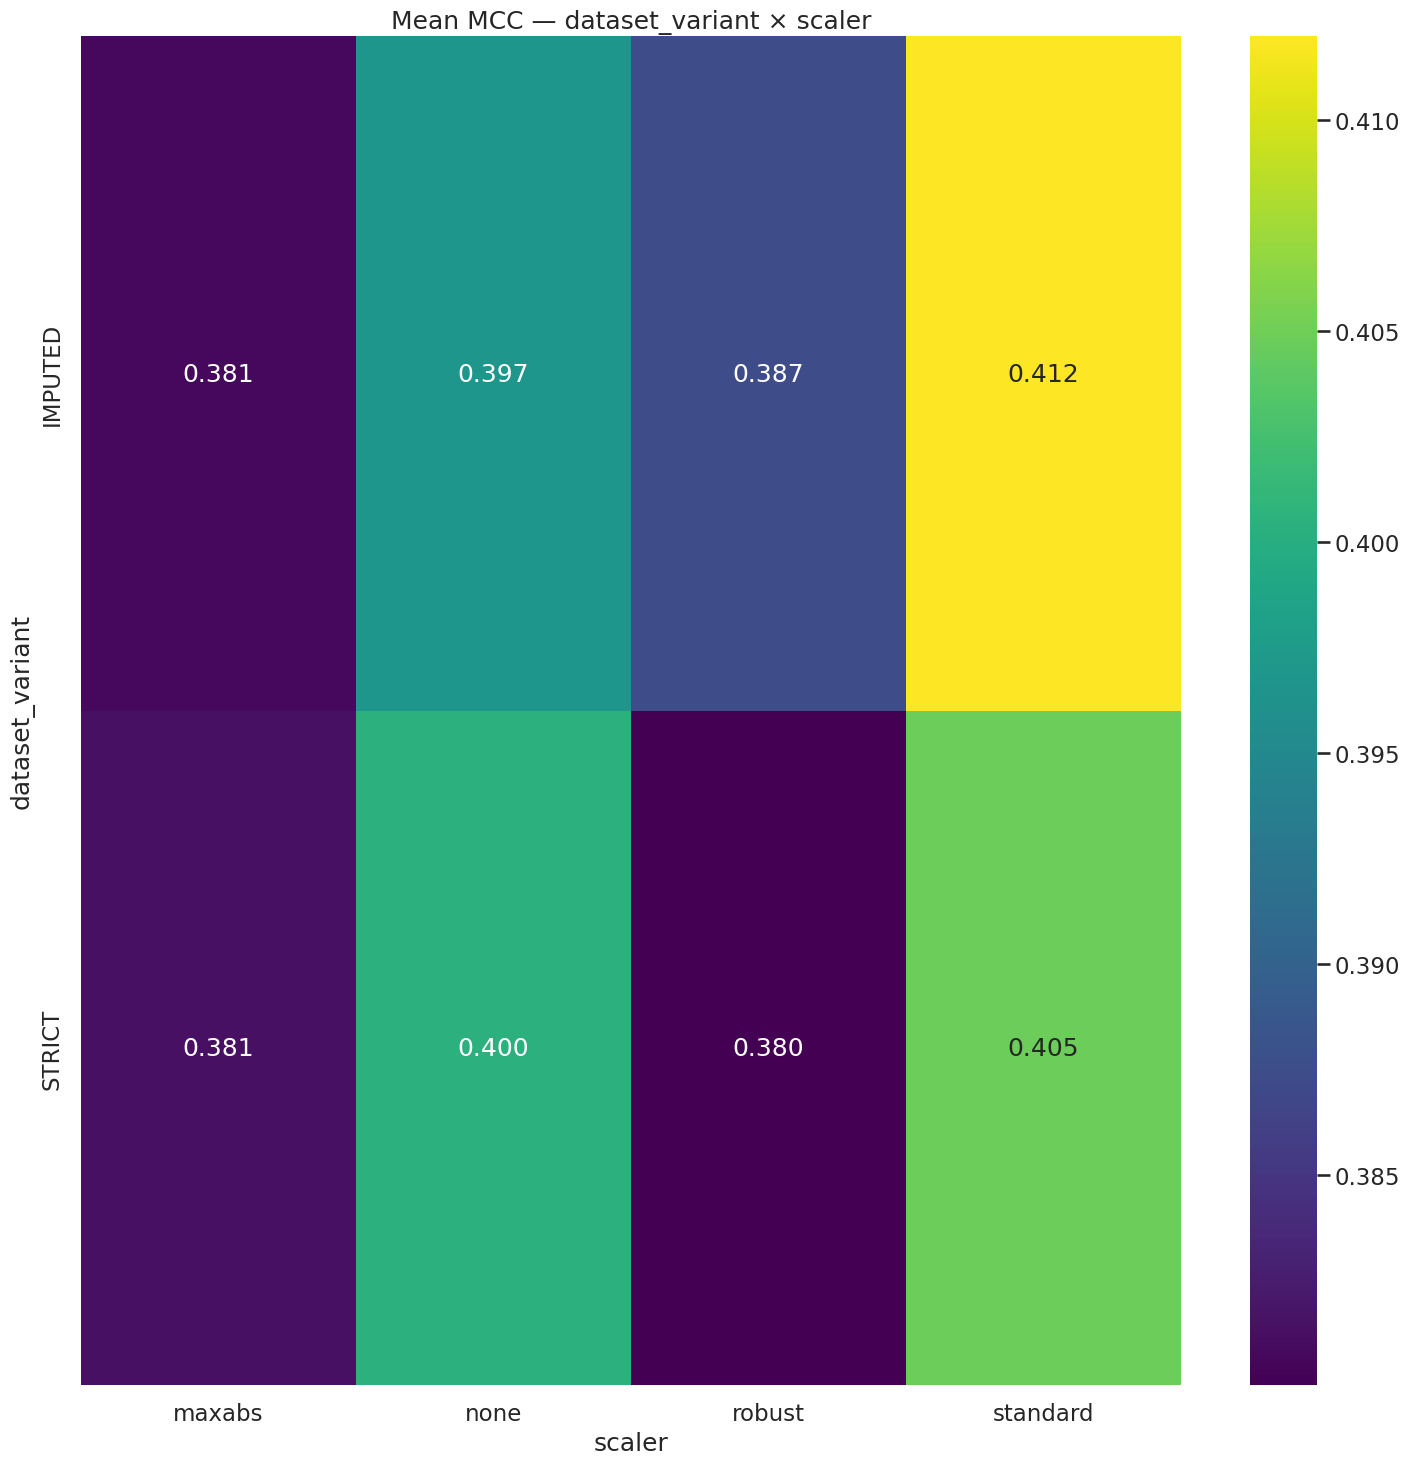

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_mcc_dataset_variant_x_scaler.png


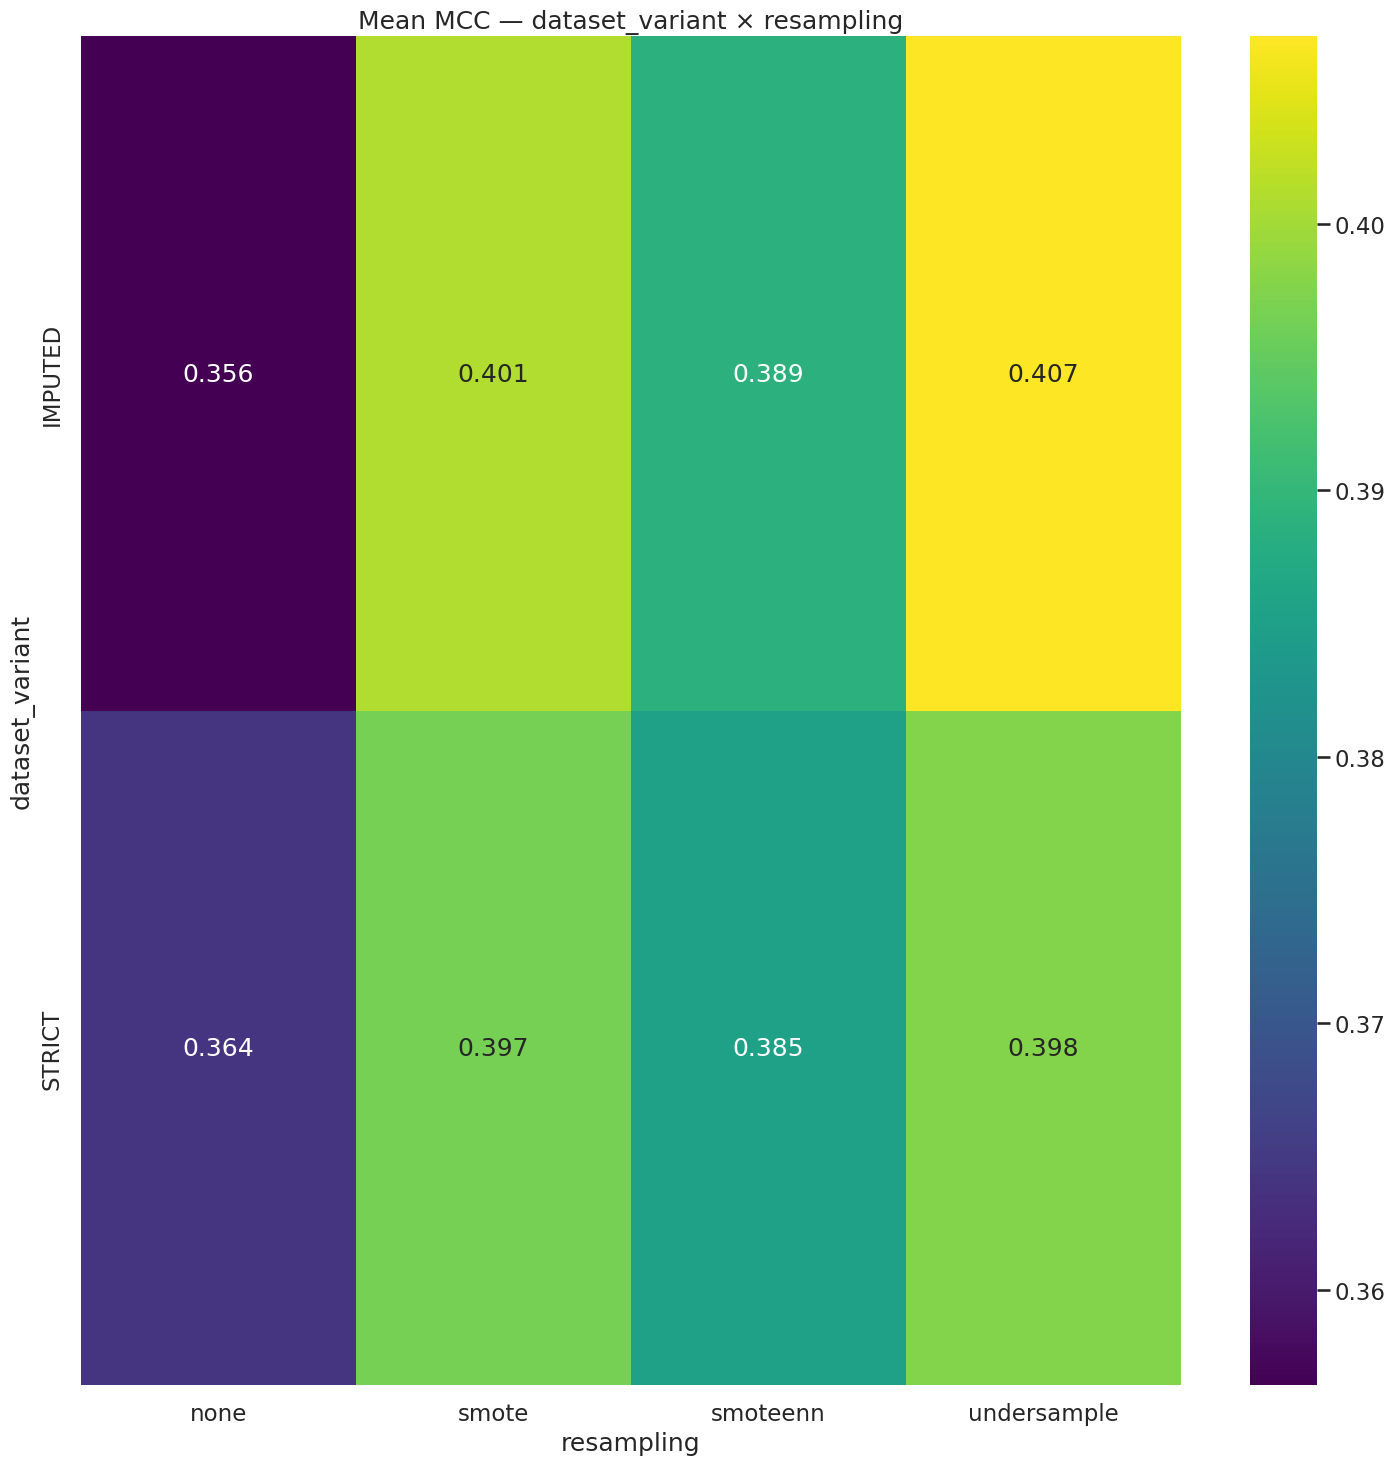

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_mcc_dataset_variant_x_resampling.png


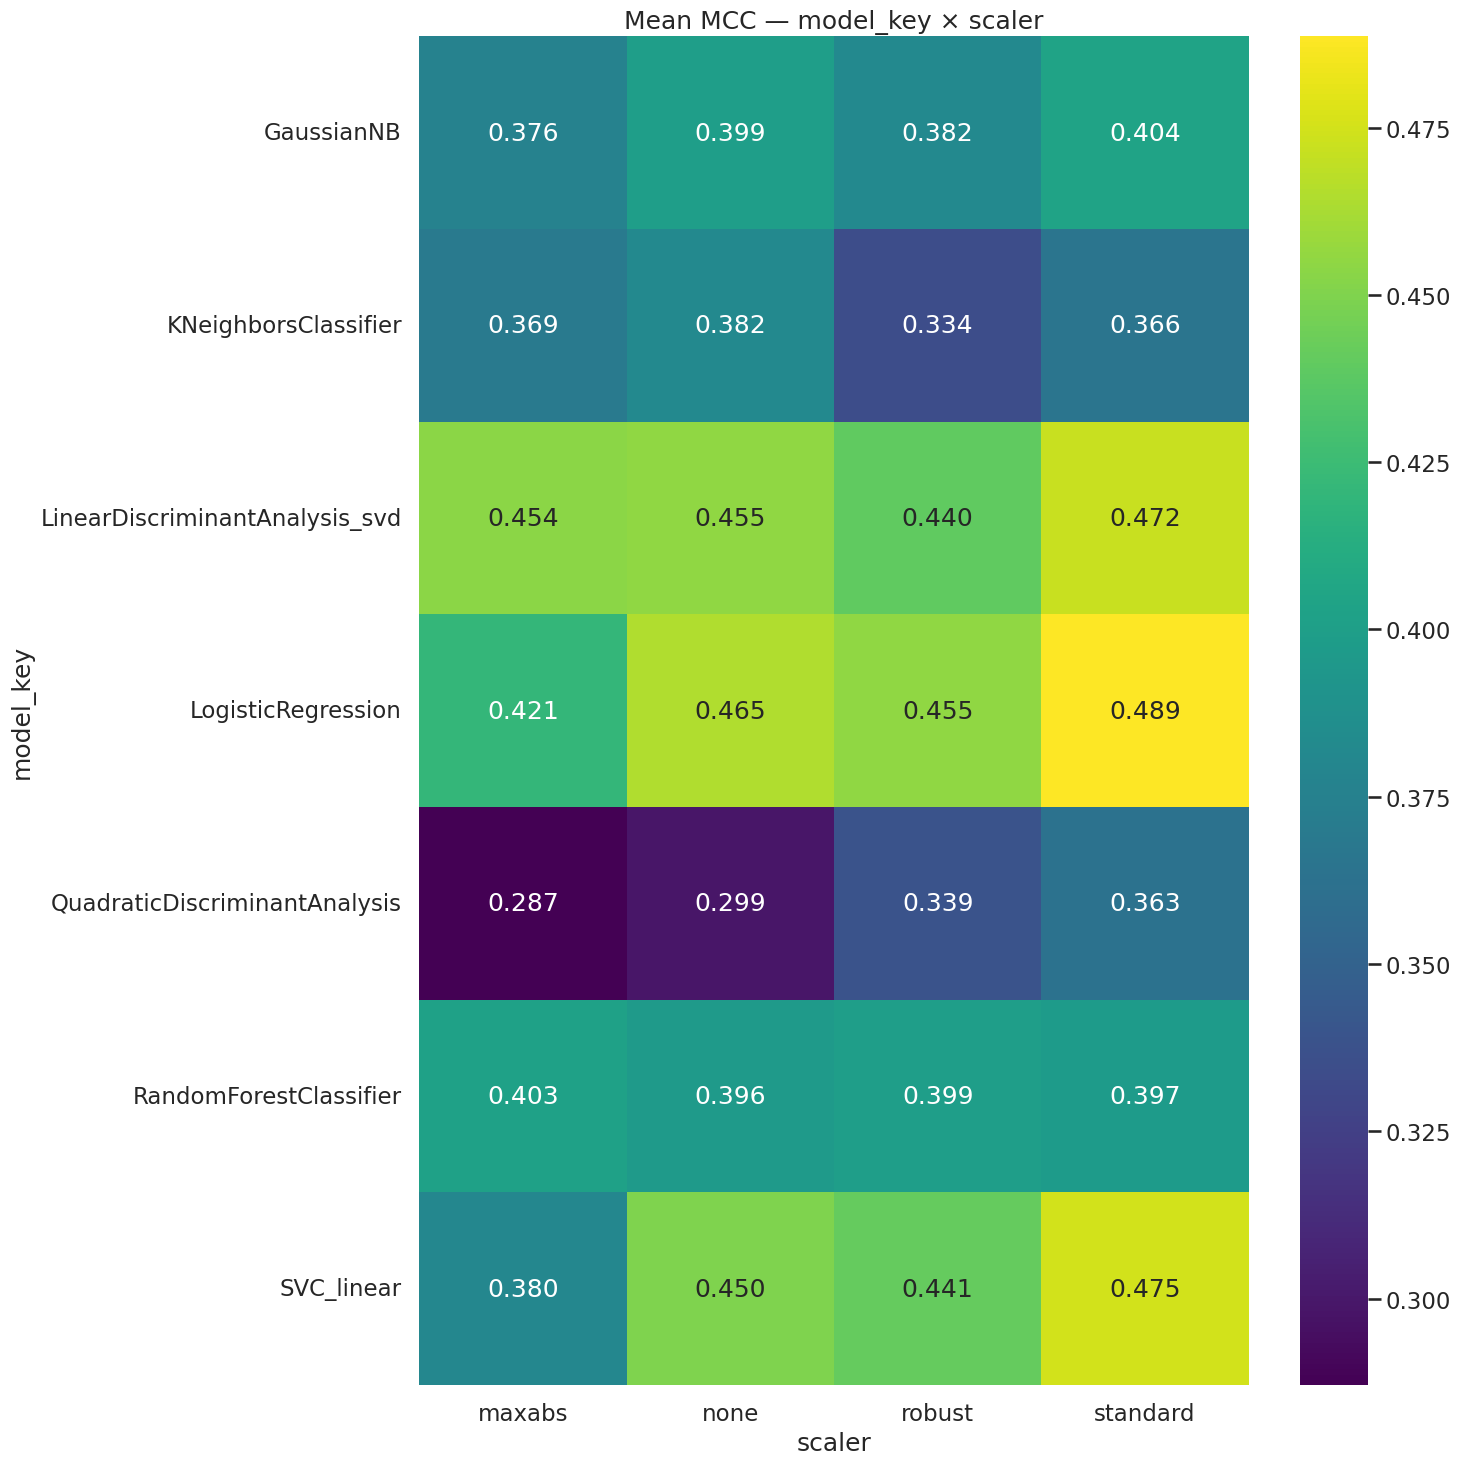

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_mcc_model_key_x_scaler.png


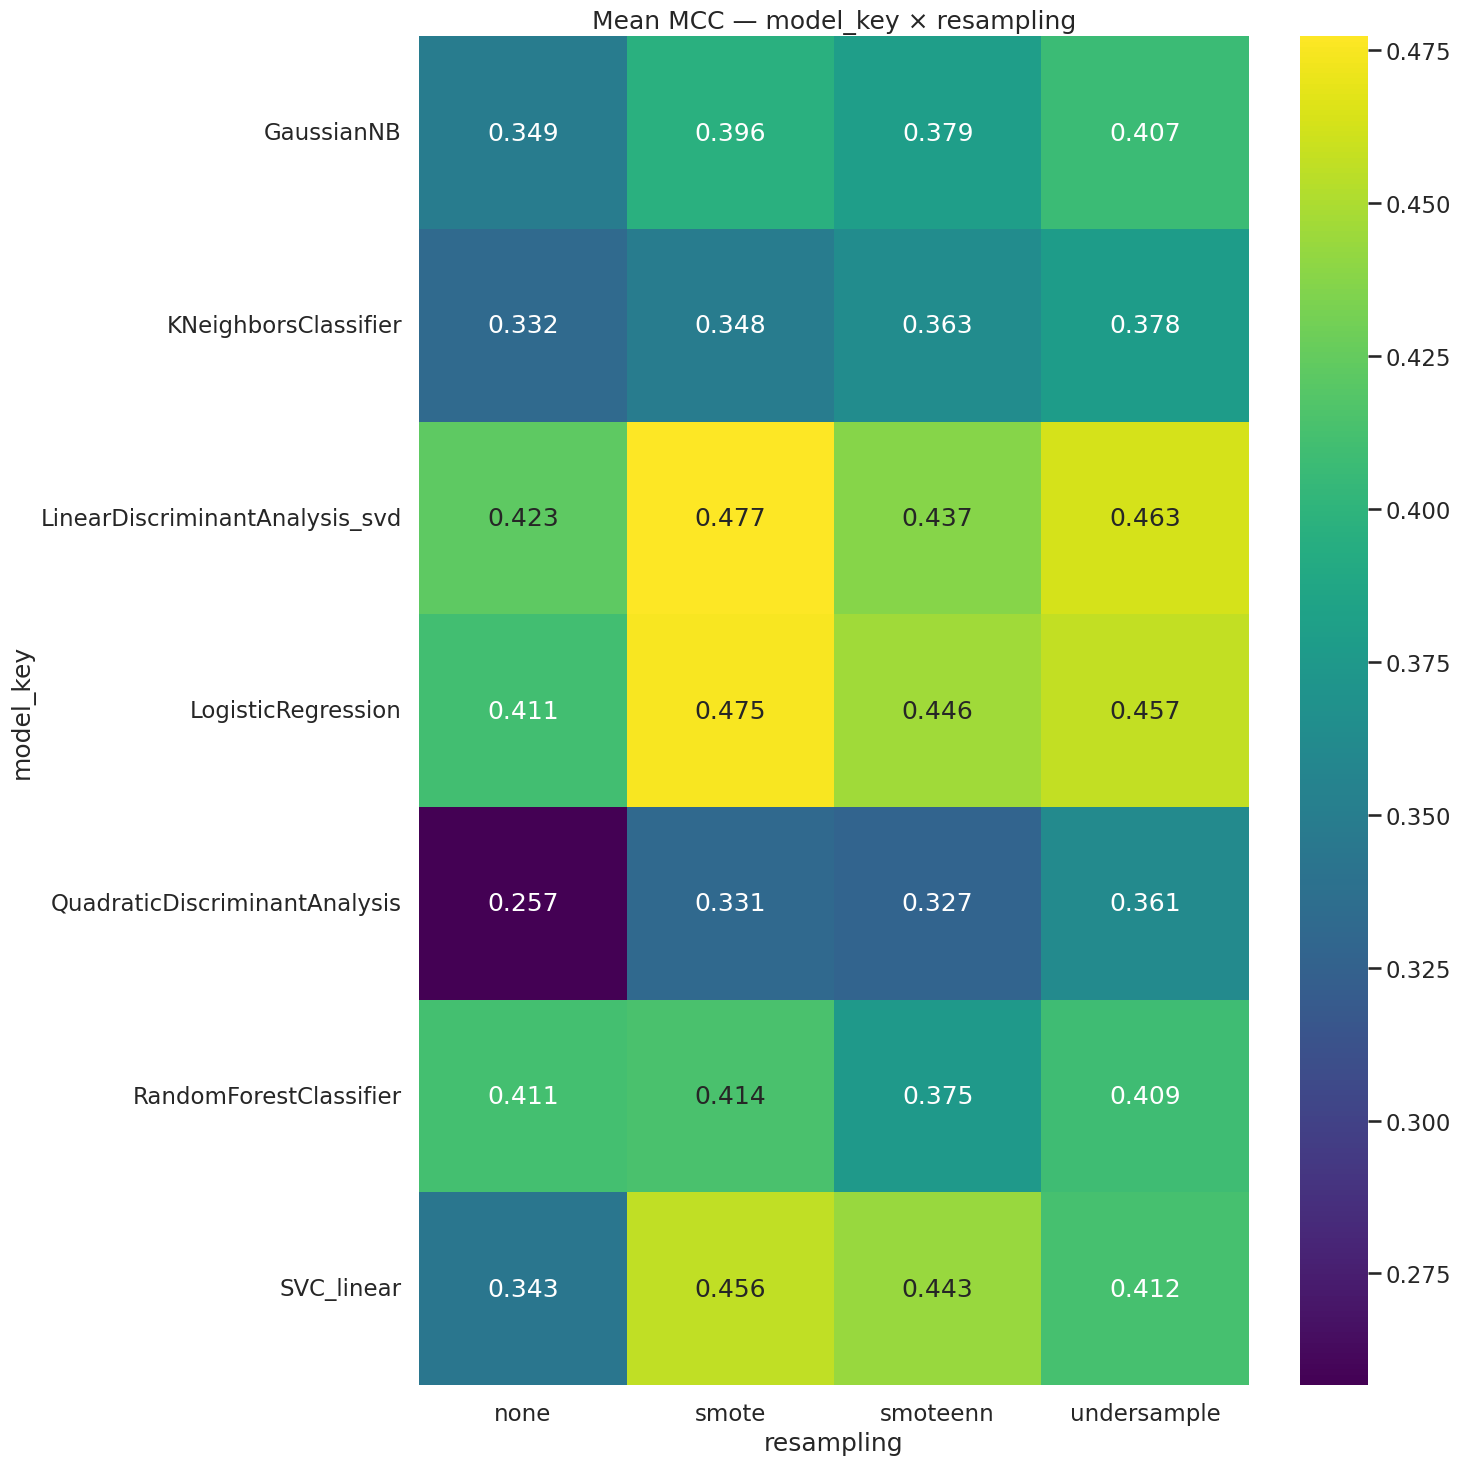

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_mcc_model_key_x_resampling.png


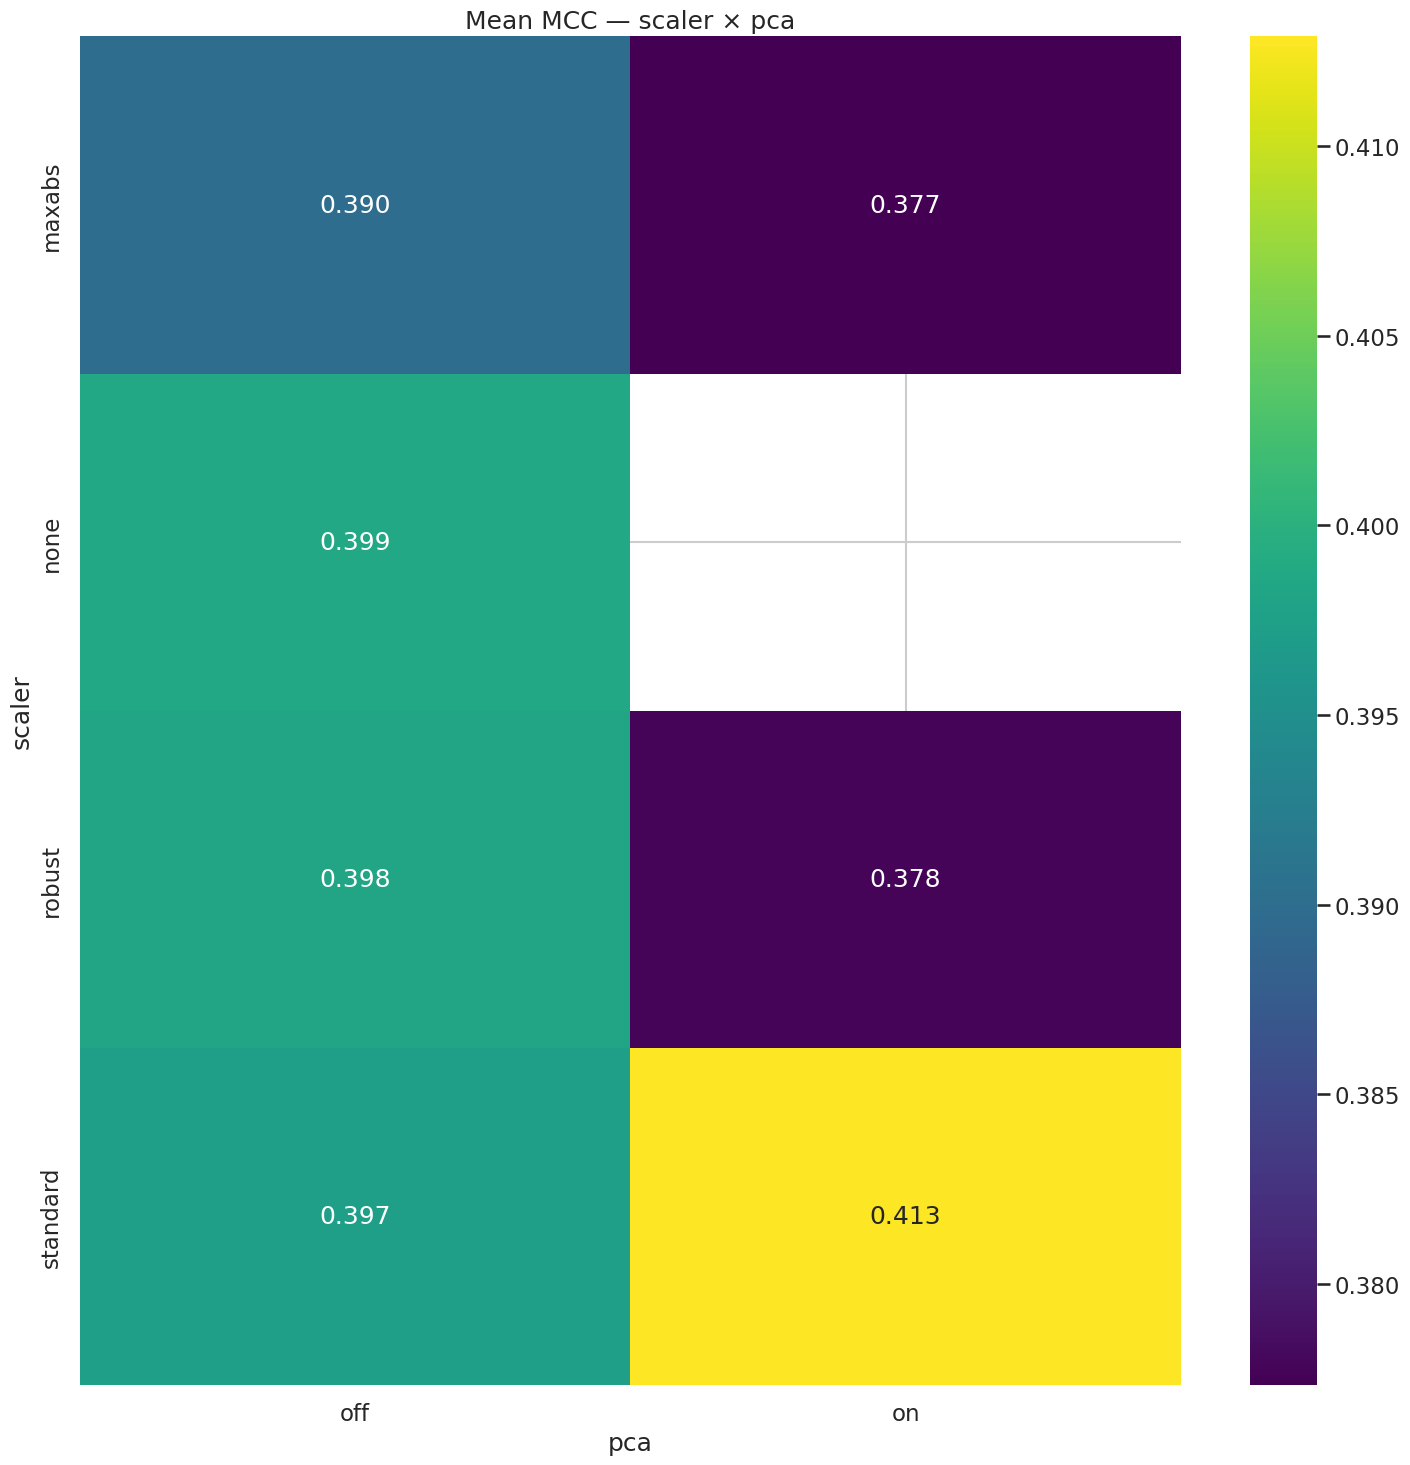

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_mcc_scaler_x_pca.png


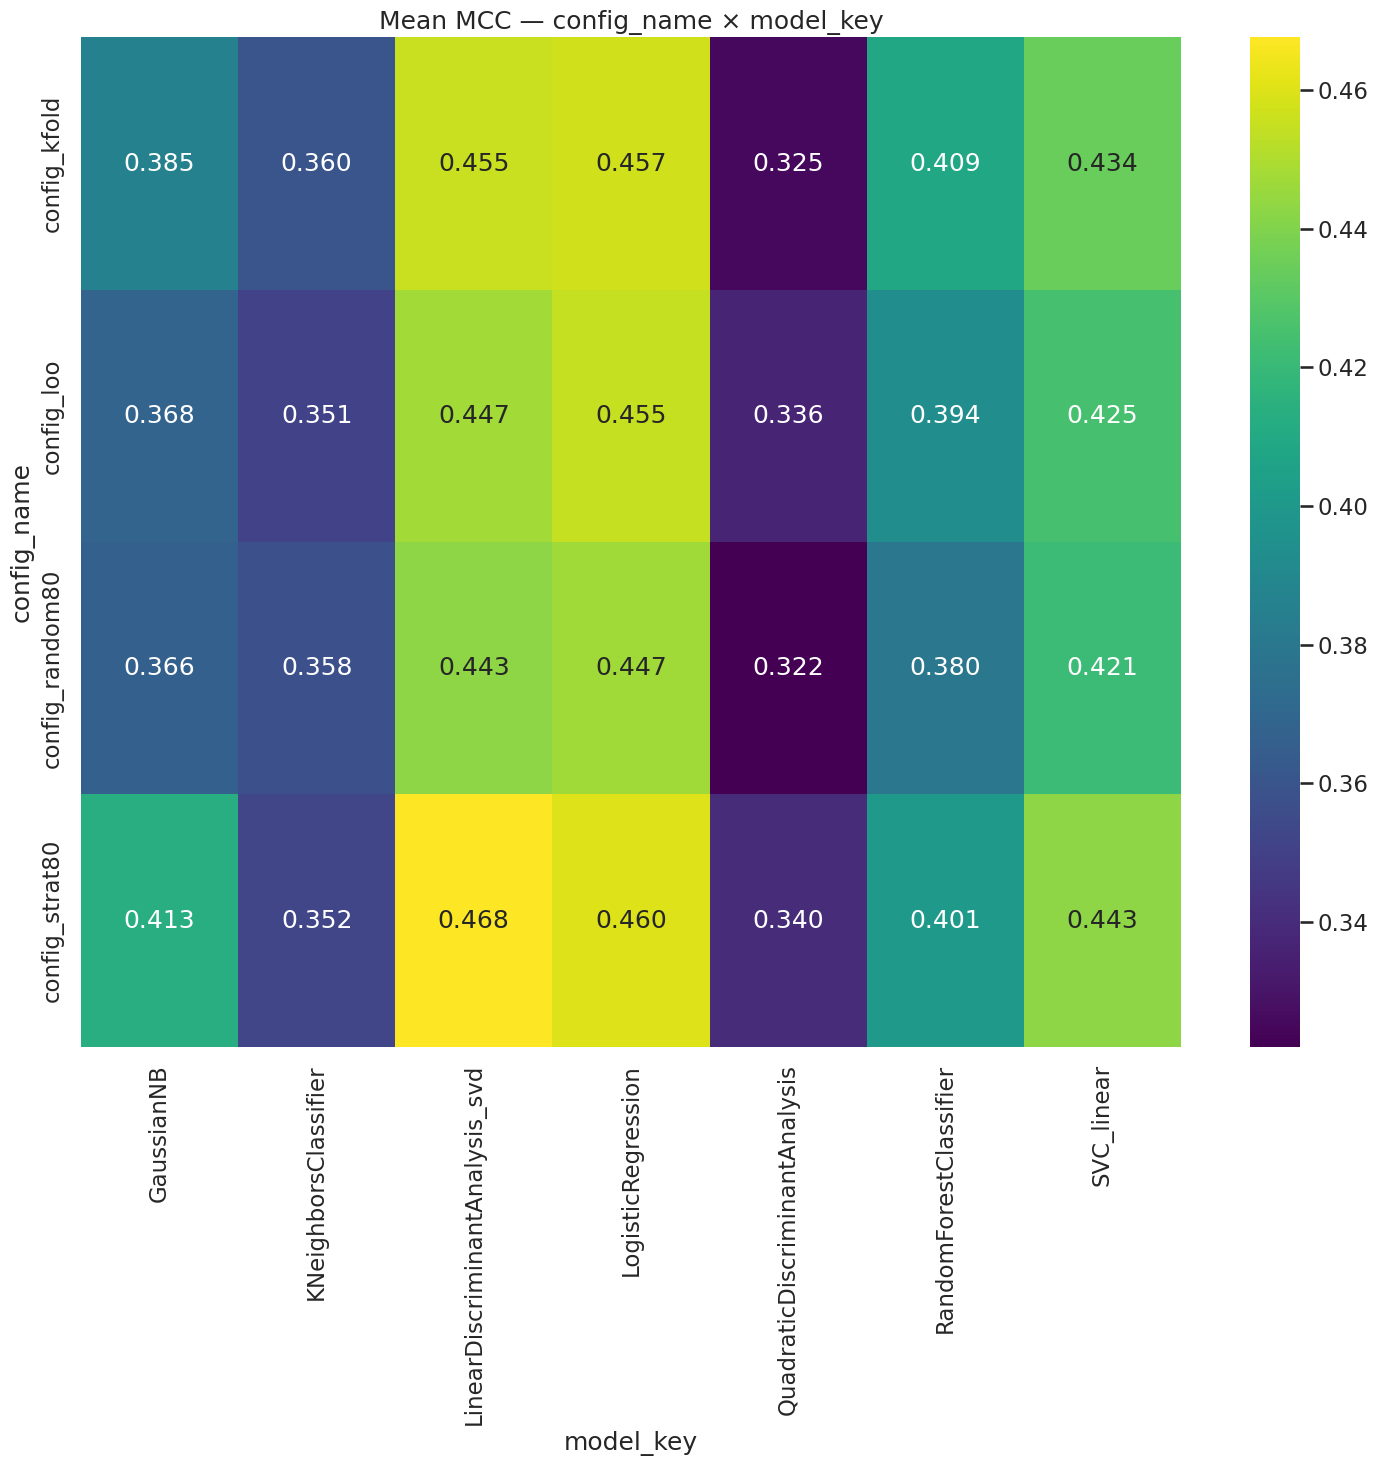

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_mcc_config_name_x_model_key.png


In [20]:
KEY_HEATMAPS = [
    (DATASET_COL, SCALER_COL),
    (DATASET_COL, RESAMPLING_COL),
    (MODEL_COL, SCALER_COL),
    (MODEL_COL, RESAMPLING_COL),
    (SCALER_COL, PCA_COL),
    (CONFIG_COL, MODEL_COL),
]

for row_factor, col_factor in KEY_HEATMAPS:
    heat = build_heatmap_table(analysis_df, row_factor, col_factor, PRIMARY_METRIC, aggfunc="mean")
    plot_heatmap(
        heat,
        title=f"Mean {PRIMARY_METRIC.upper()} — {row_factor} × {col_factor}",
        filename=f"heatmap_mean_{PRIMARY_METRIC}_{row_factor}_x_{col_factor}",
        center=None,
        annot=True,
        fmt=".3f",
    )


## 3. Support heatmaps

Mean values can be misleading when some combinations are represented by very few runs.  
To contextualize performance patterns, we also visualize the number of observations supporting each interaction cell.


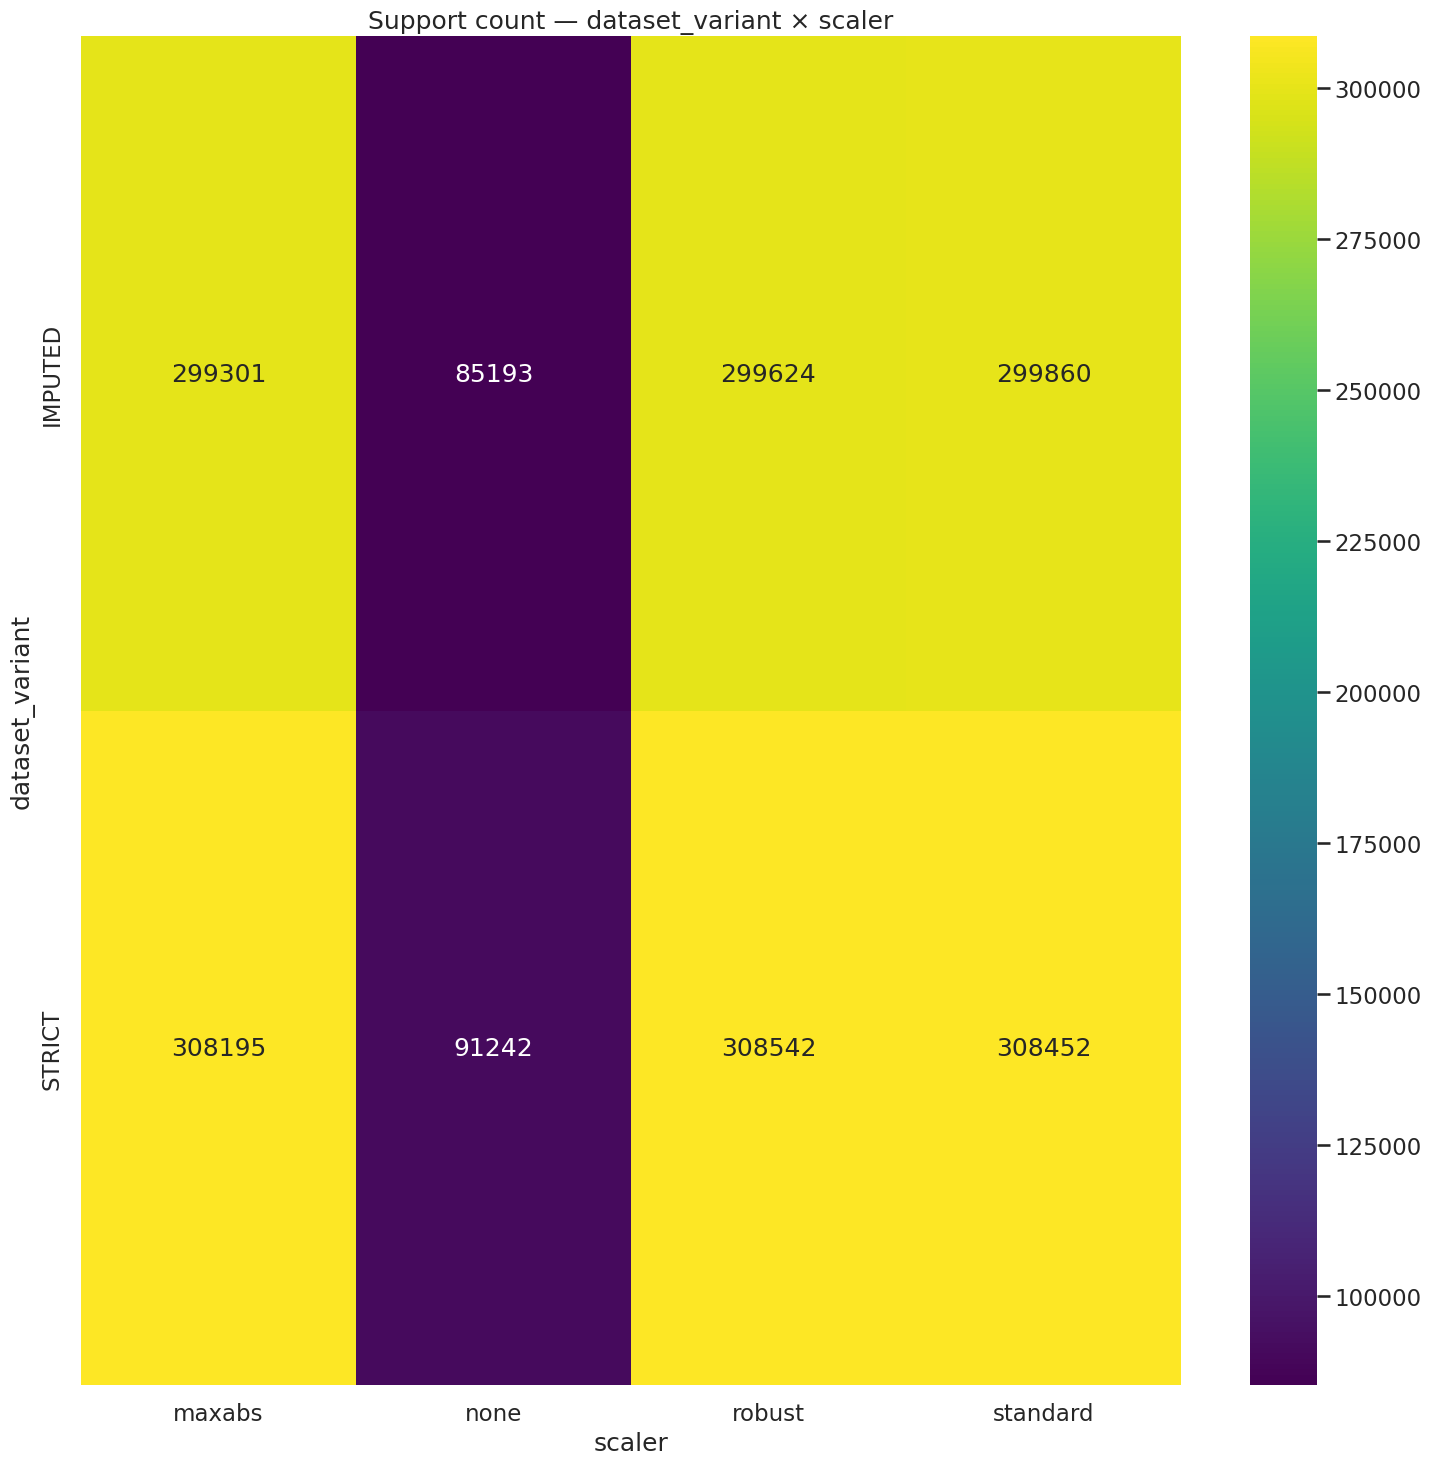

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_count_dataset_variant_x_scaler.png


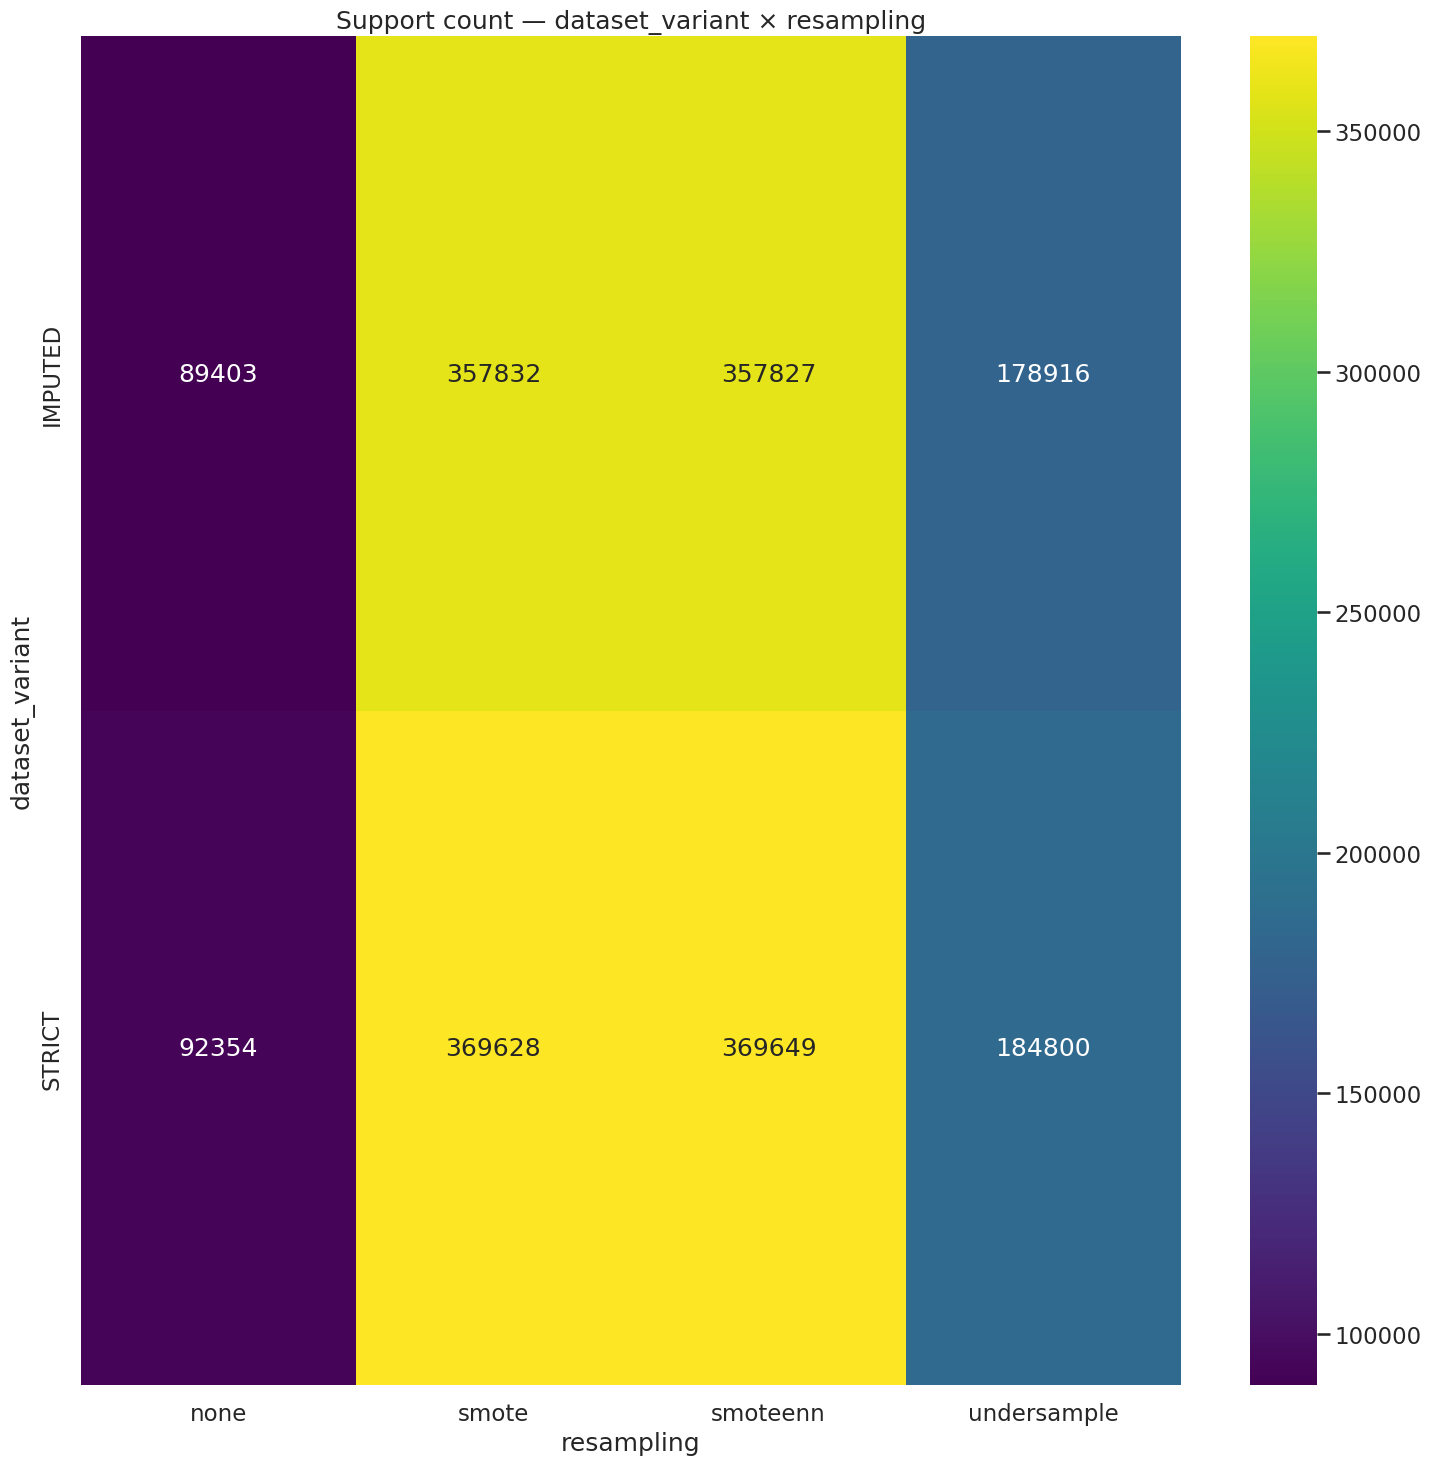

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_count_dataset_variant_x_resampling.png


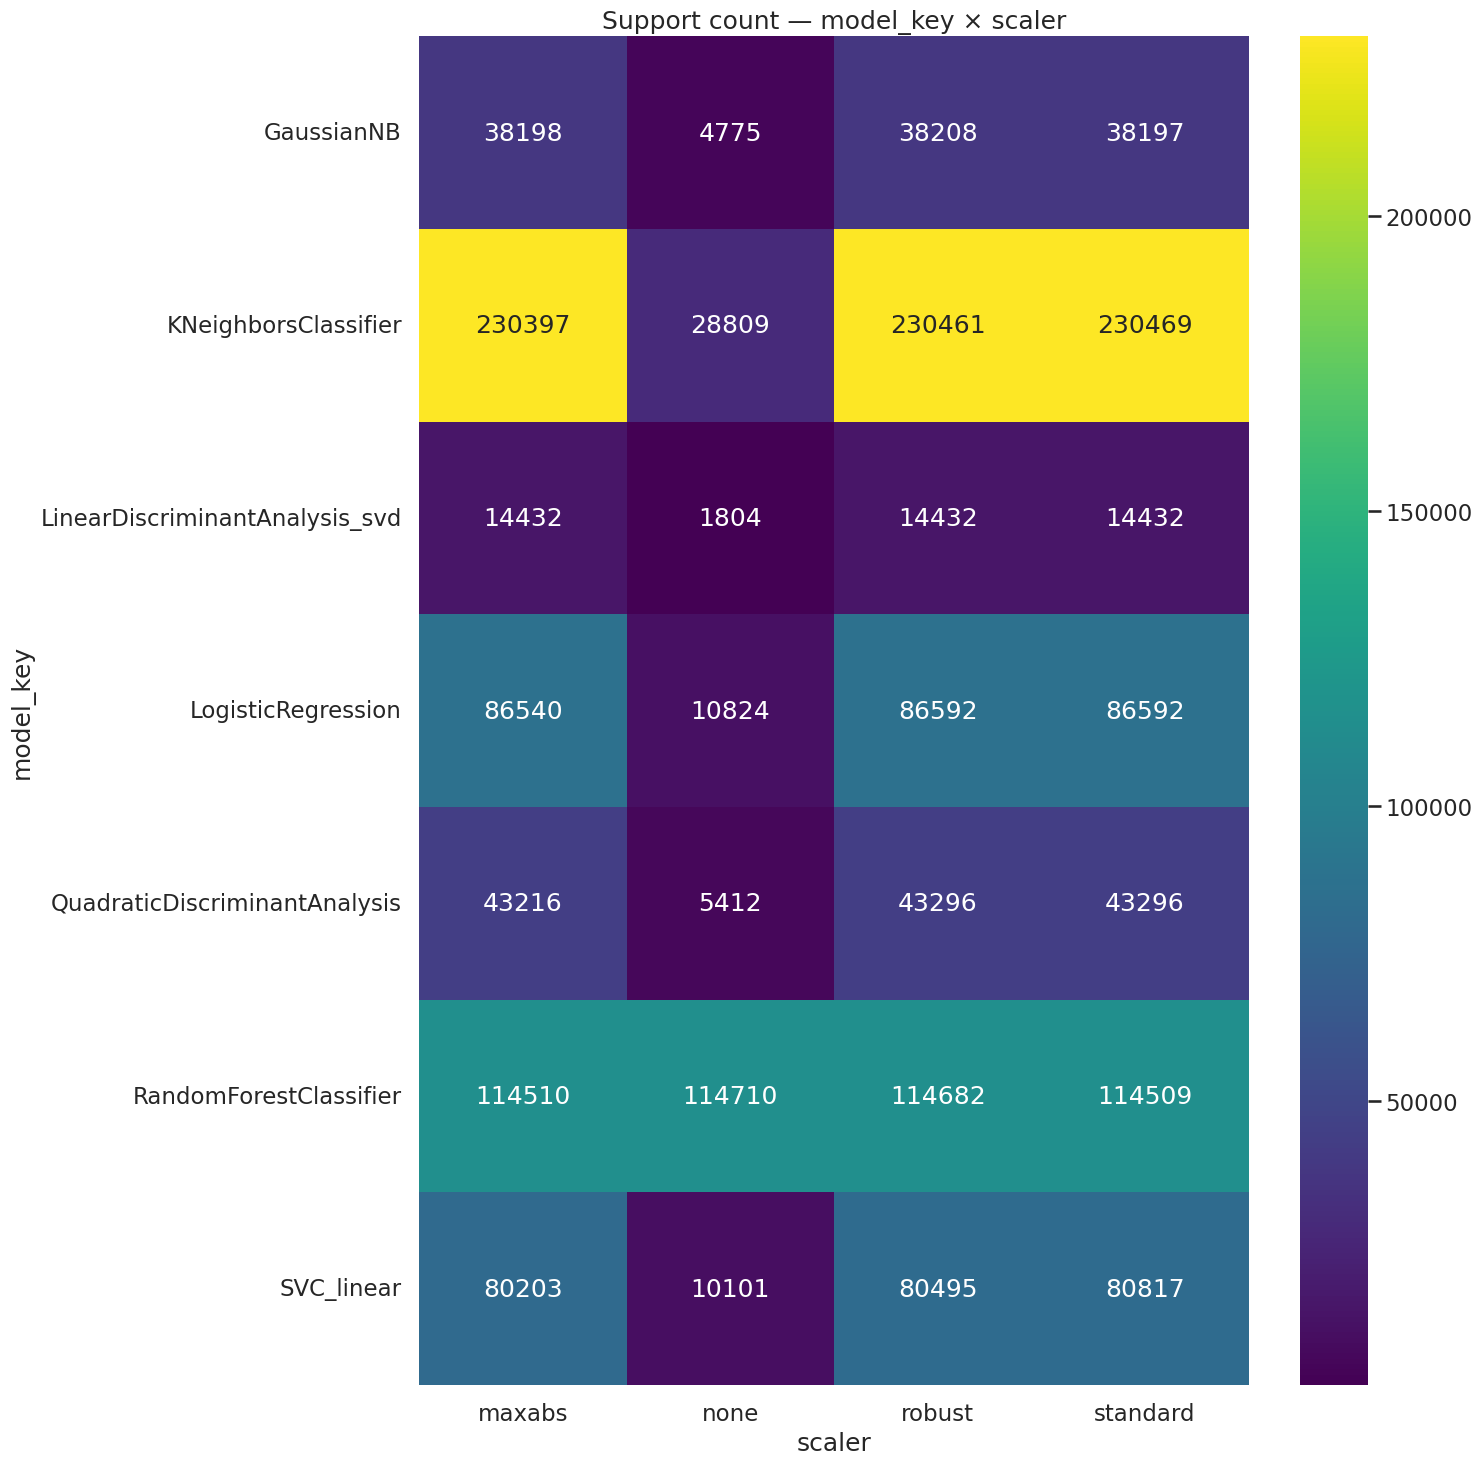

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_count_model_key_x_scaler.png


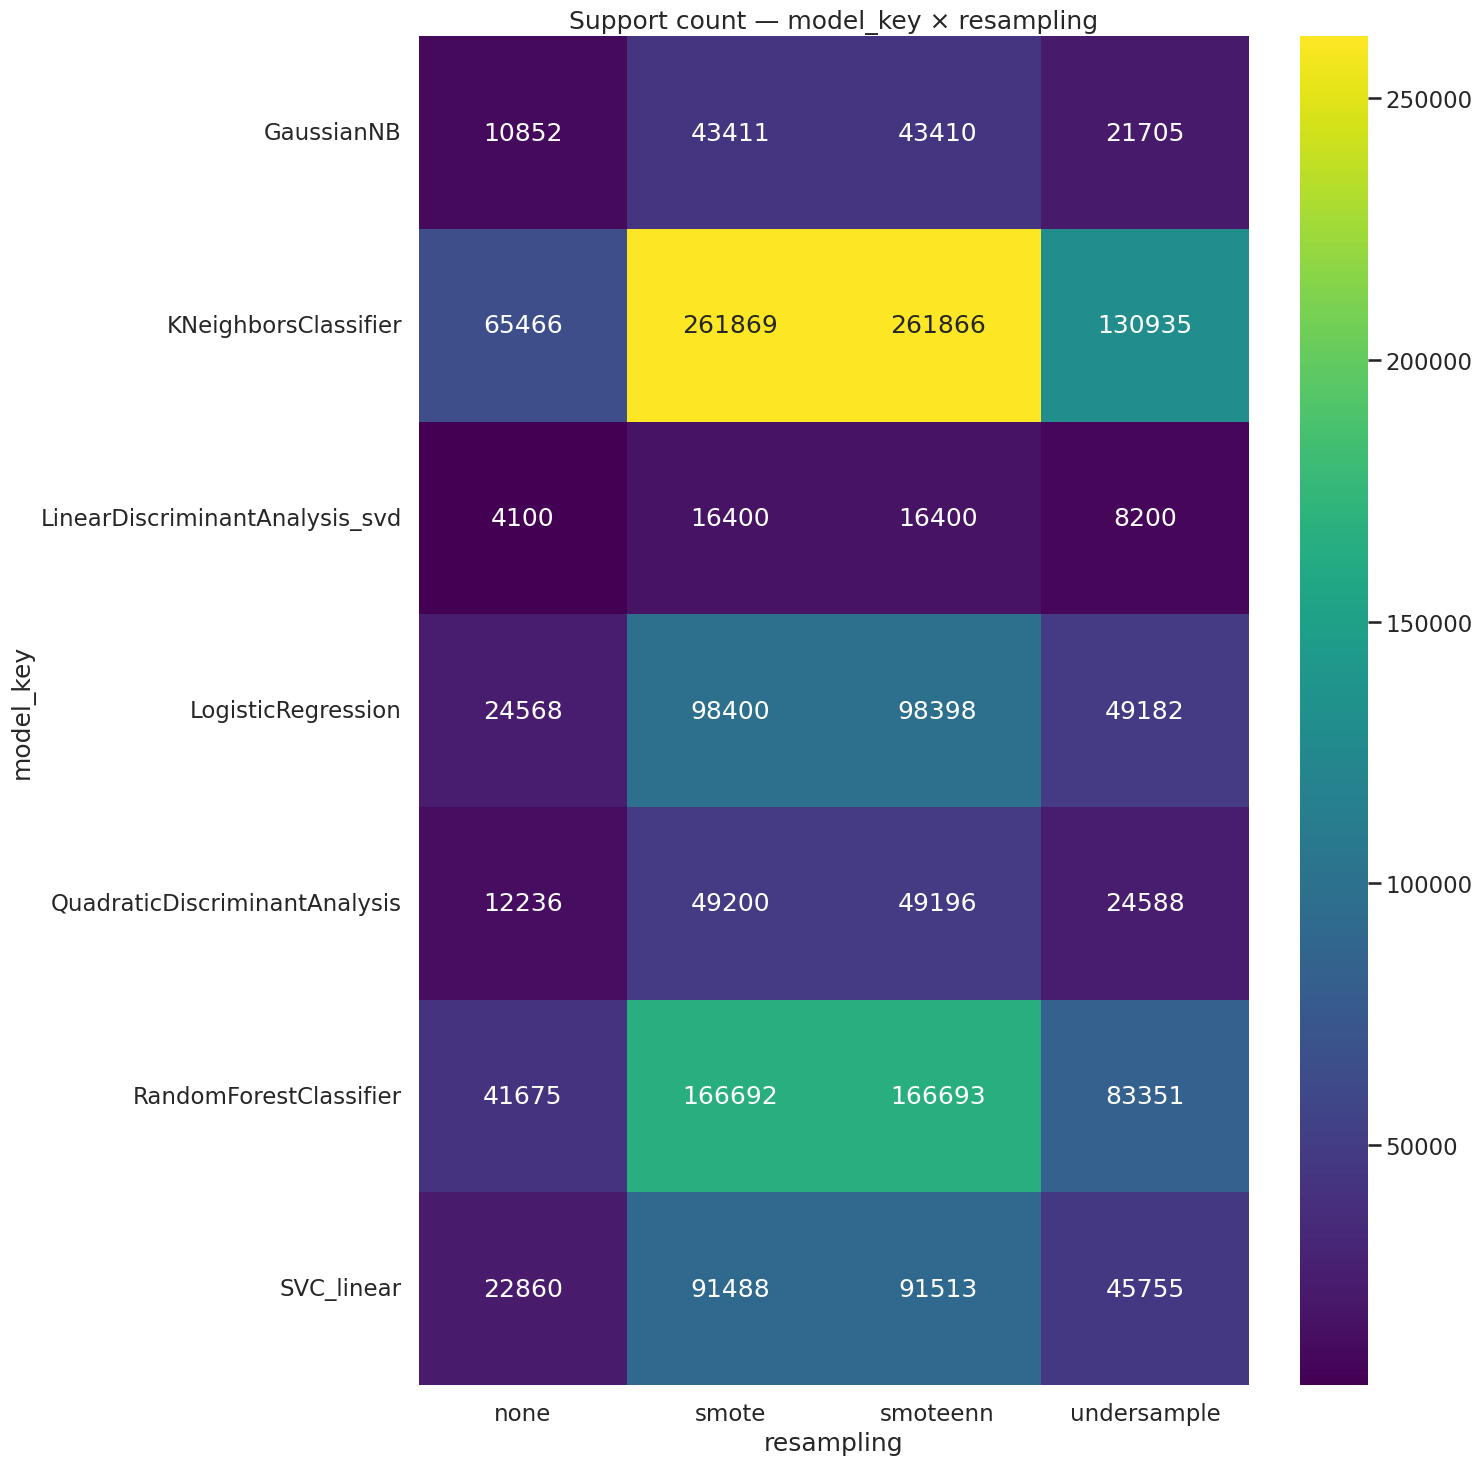

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_count_model_key_x_resampling.png


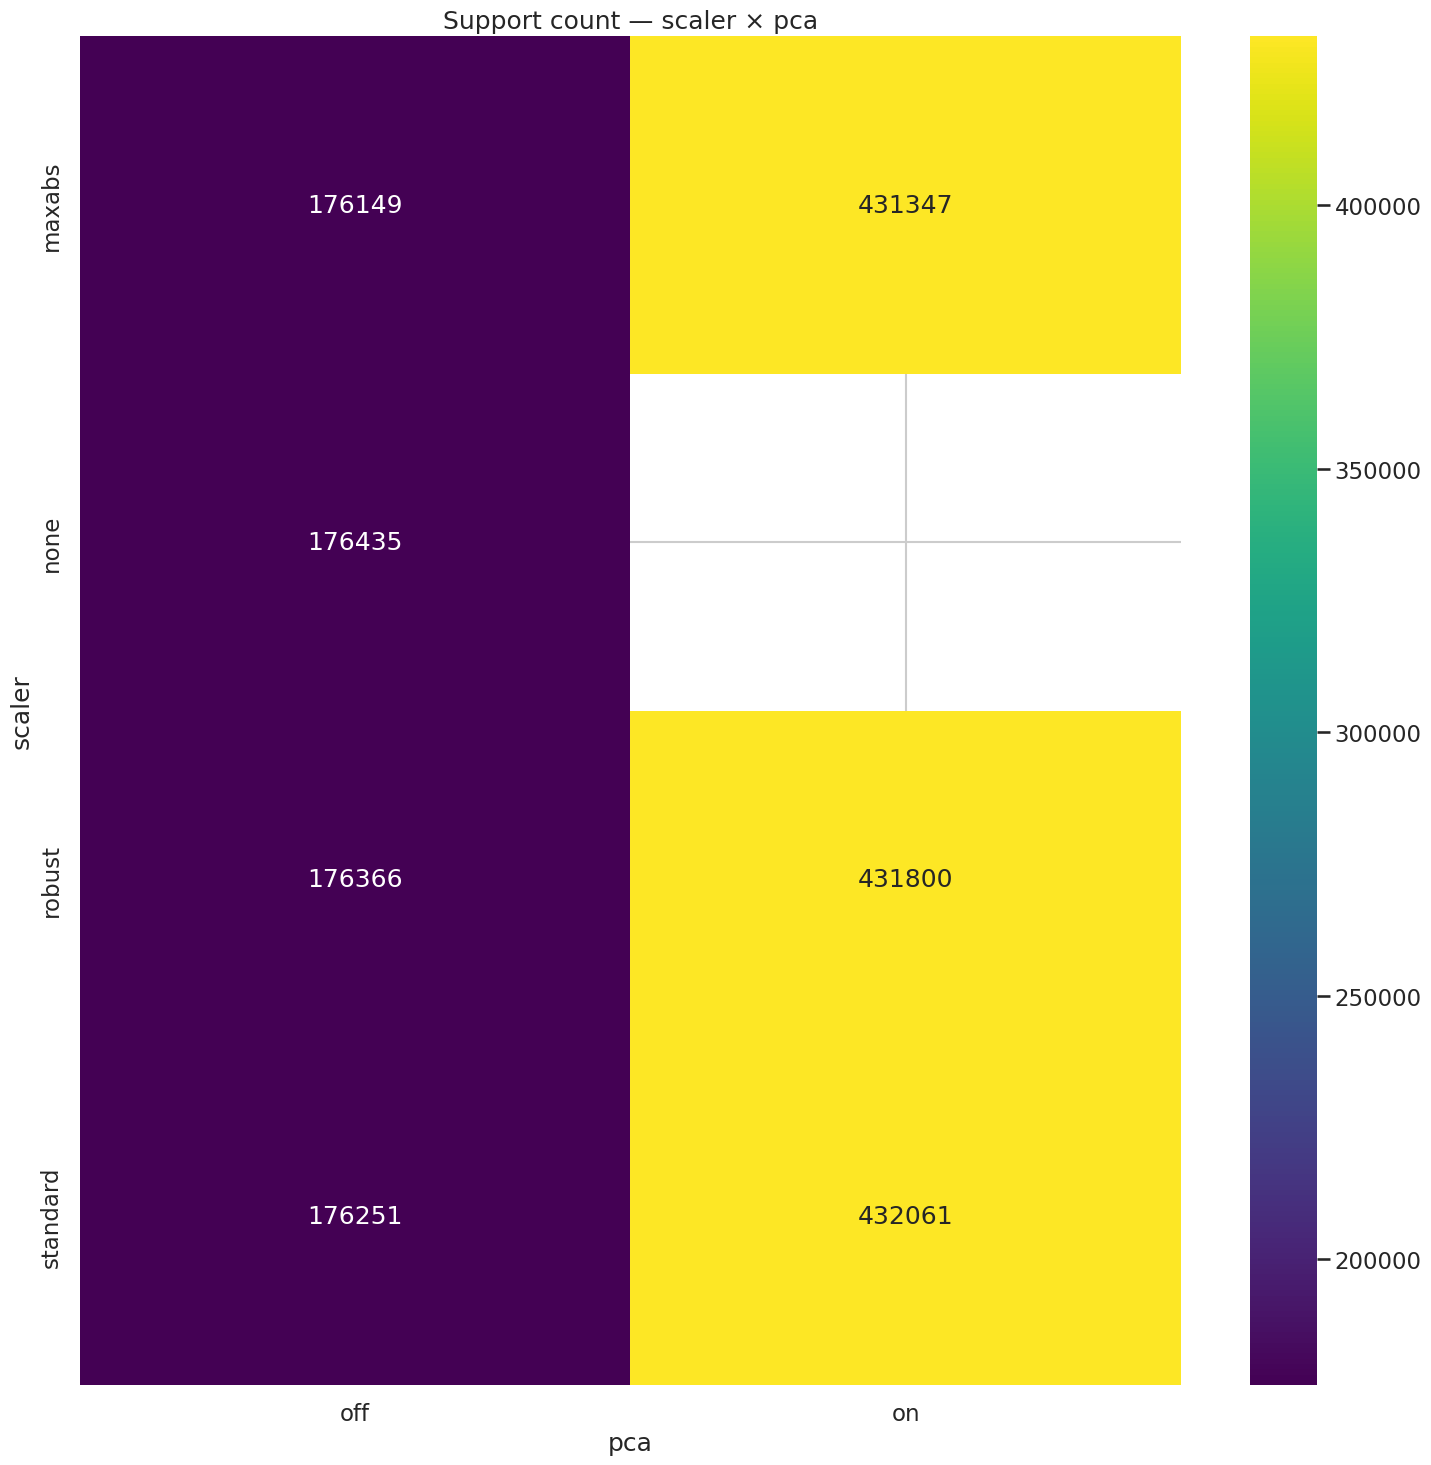

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_count_scaler_x_pca.png


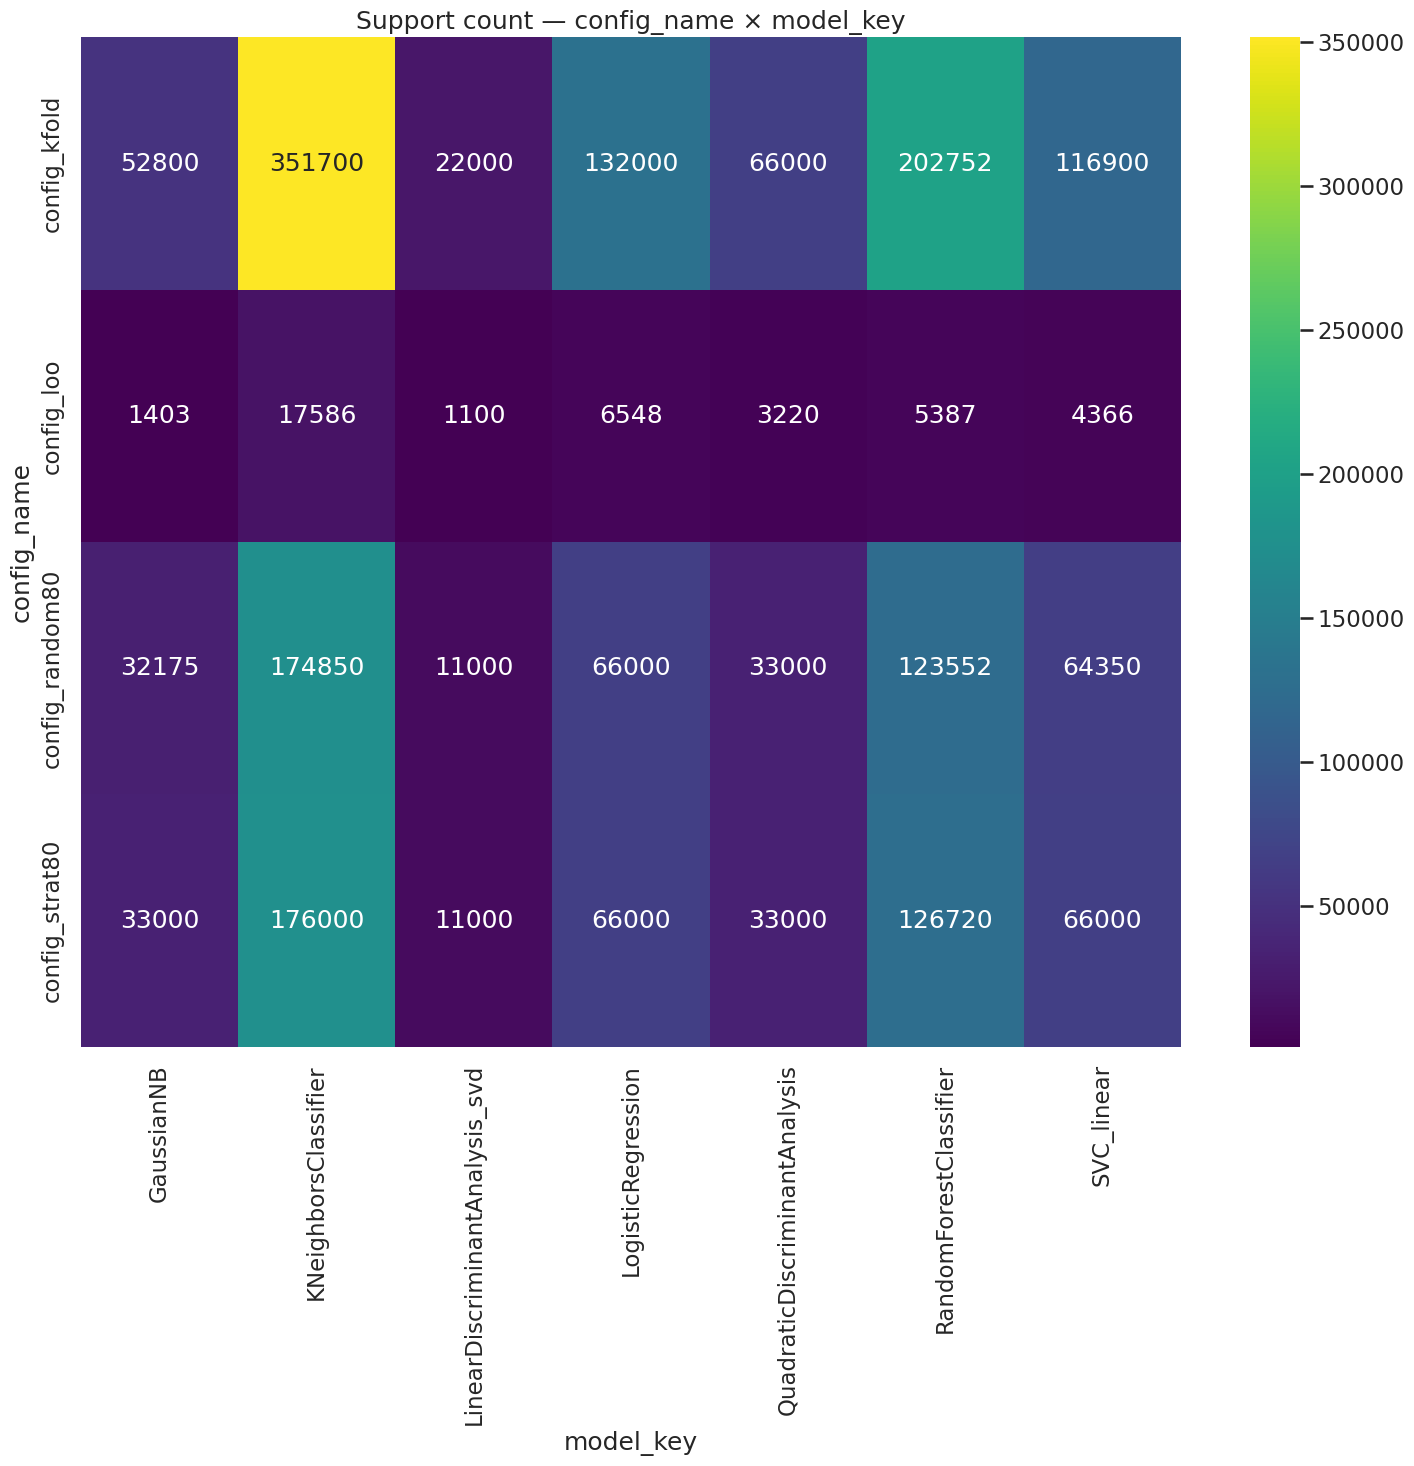

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_count_config_name_x_model_key.png


In [21]:
for row_factor, col_factor in KEY_HEATMAPS:
    heat_count = build_heatmap_table(analysis_df, row_factor, col_factor, PRIMARY_METRIC, aggfunc="count")
    plot_heatmap(
        heat_count,
        title=f"Support count — {row_factor} × {col_factor}",
        filename=f"heatmap_count_{row_factor}_x_{col_factor}",
        center=None,
        annot=True,
        fmt=".0f",
    )


## 4. Variability heatmaps

To distinguish robust combinations from unstable ones, we examine the within-cell standard deviation for the primary metric.


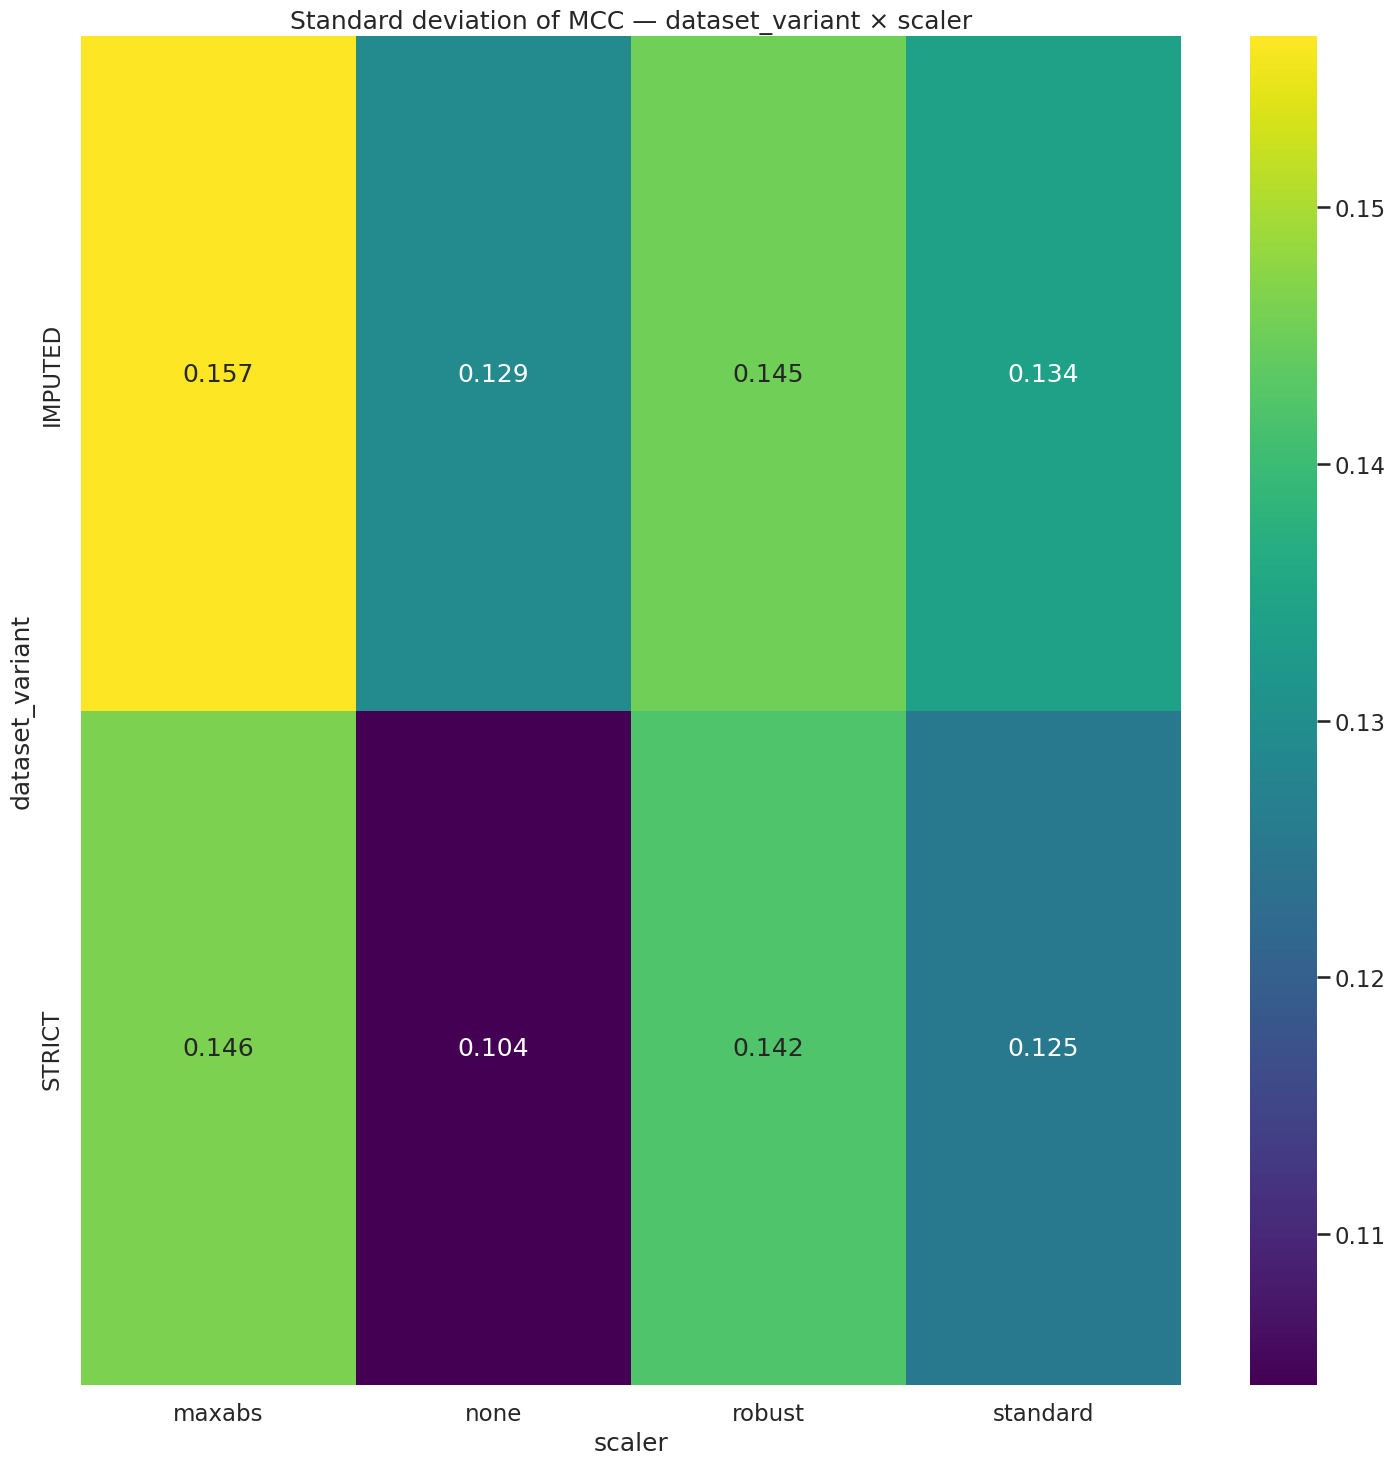

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_std_mcc_dataset_variant_x_scaler.png


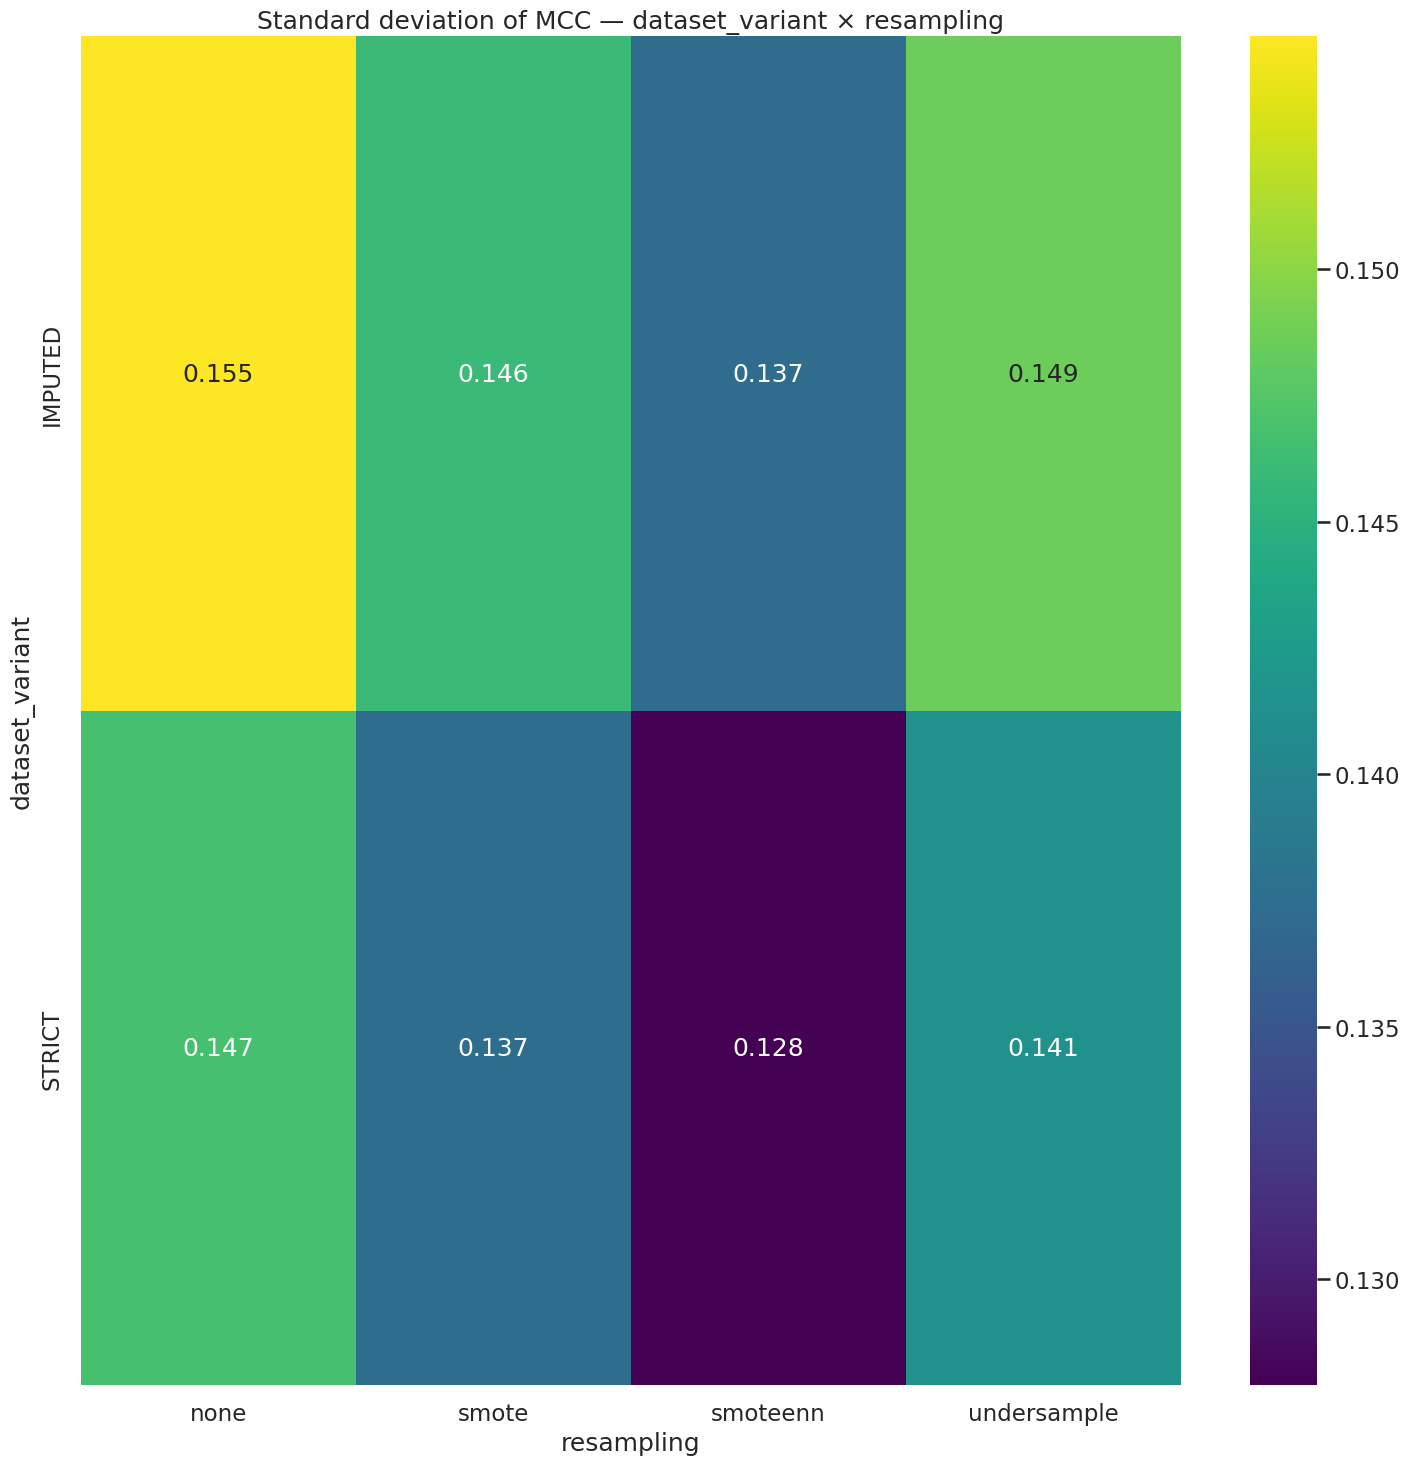

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_std_mcc_dataset_variant_x_resampling.png


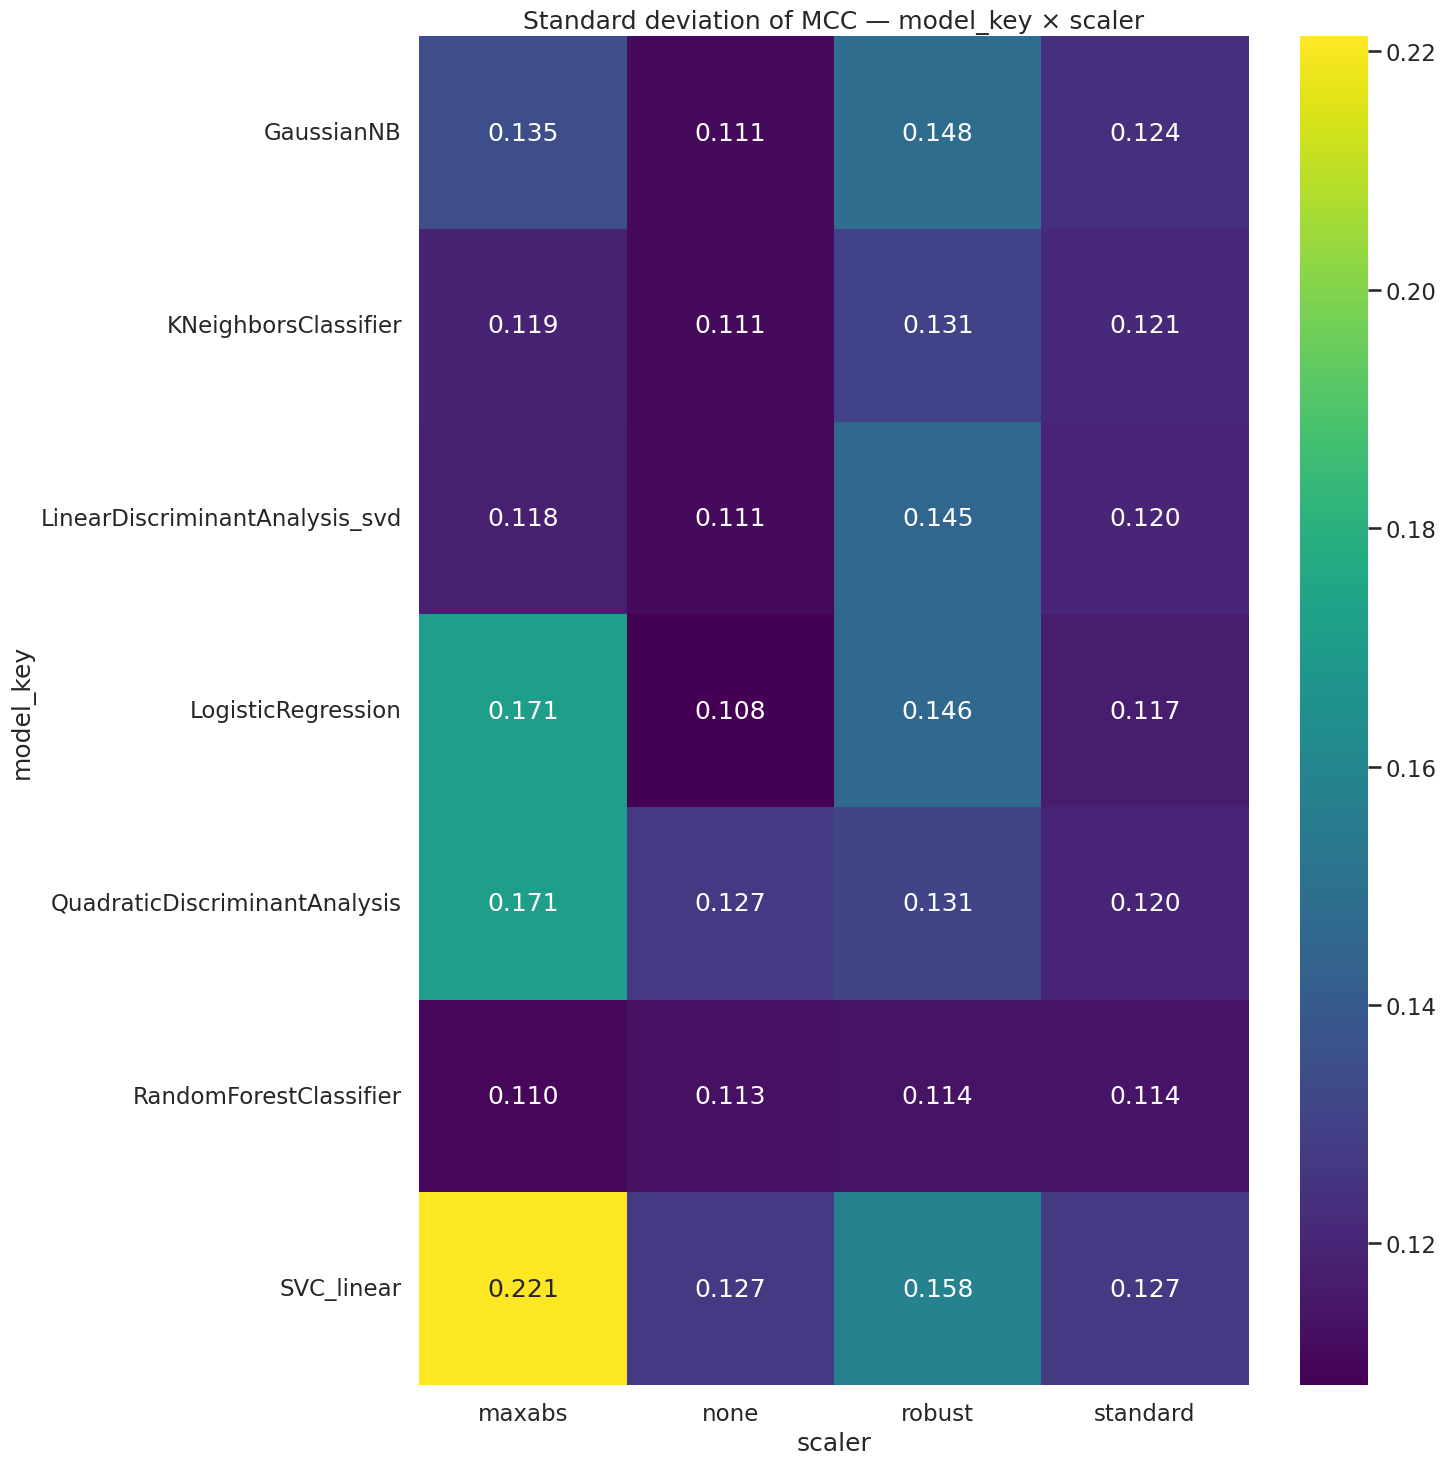

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_std_mcc_model_key_x_scaler.png


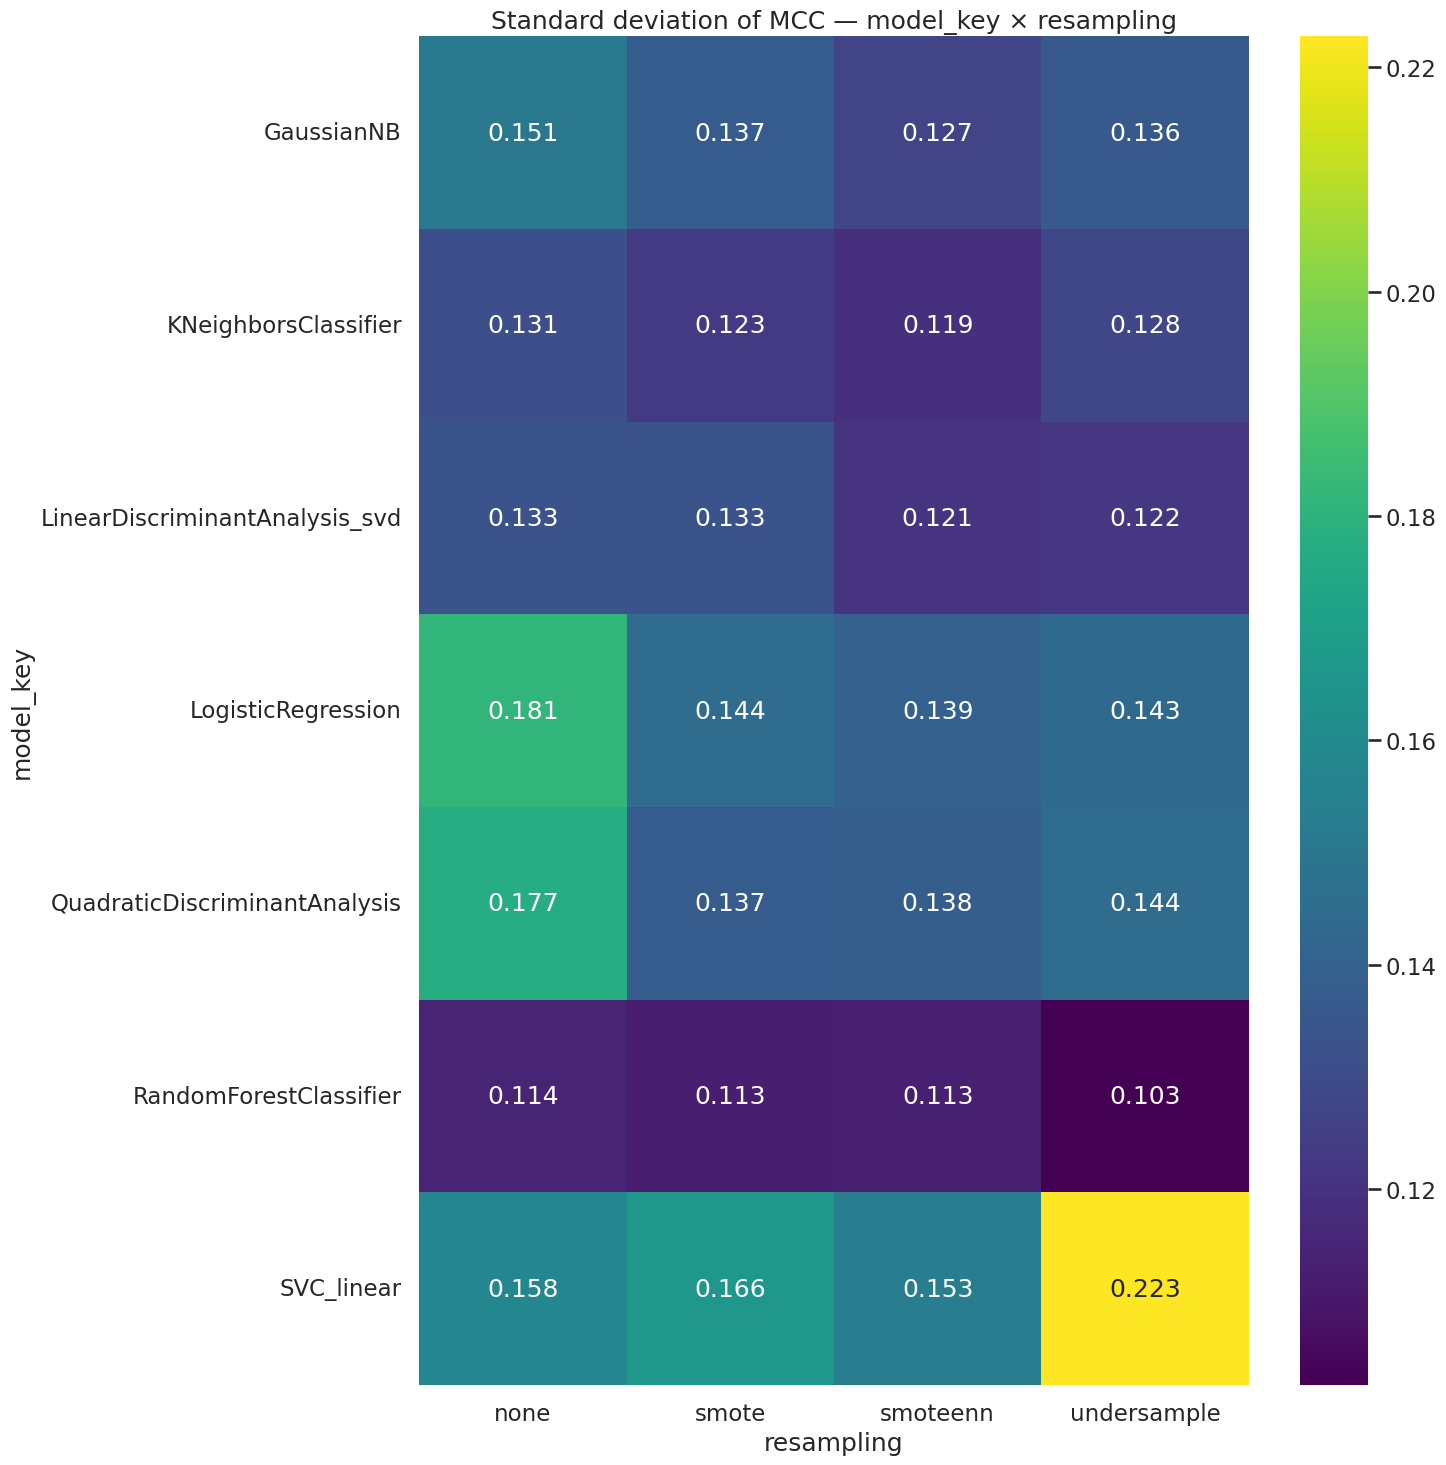

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_std_mcc_model_key_x_resampling.png


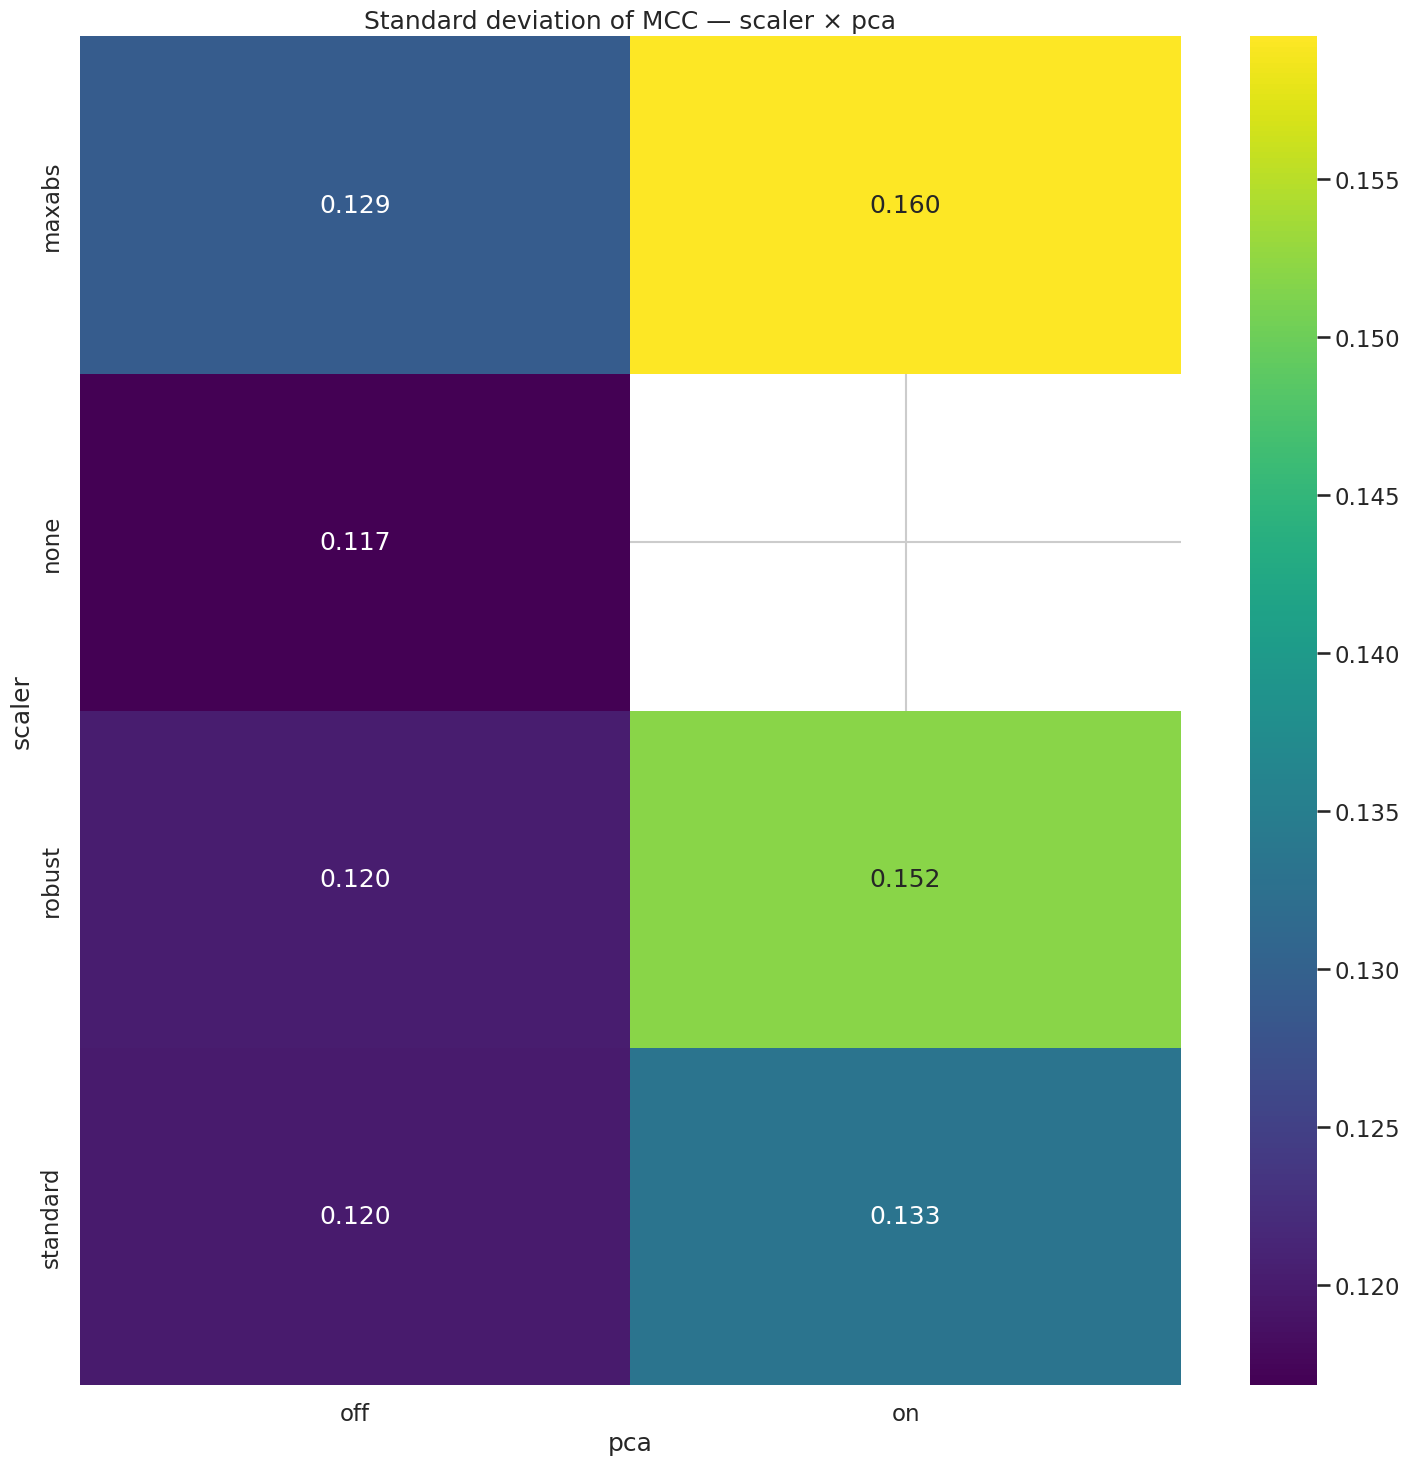

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_std_mcc_scaler_x_pca.png


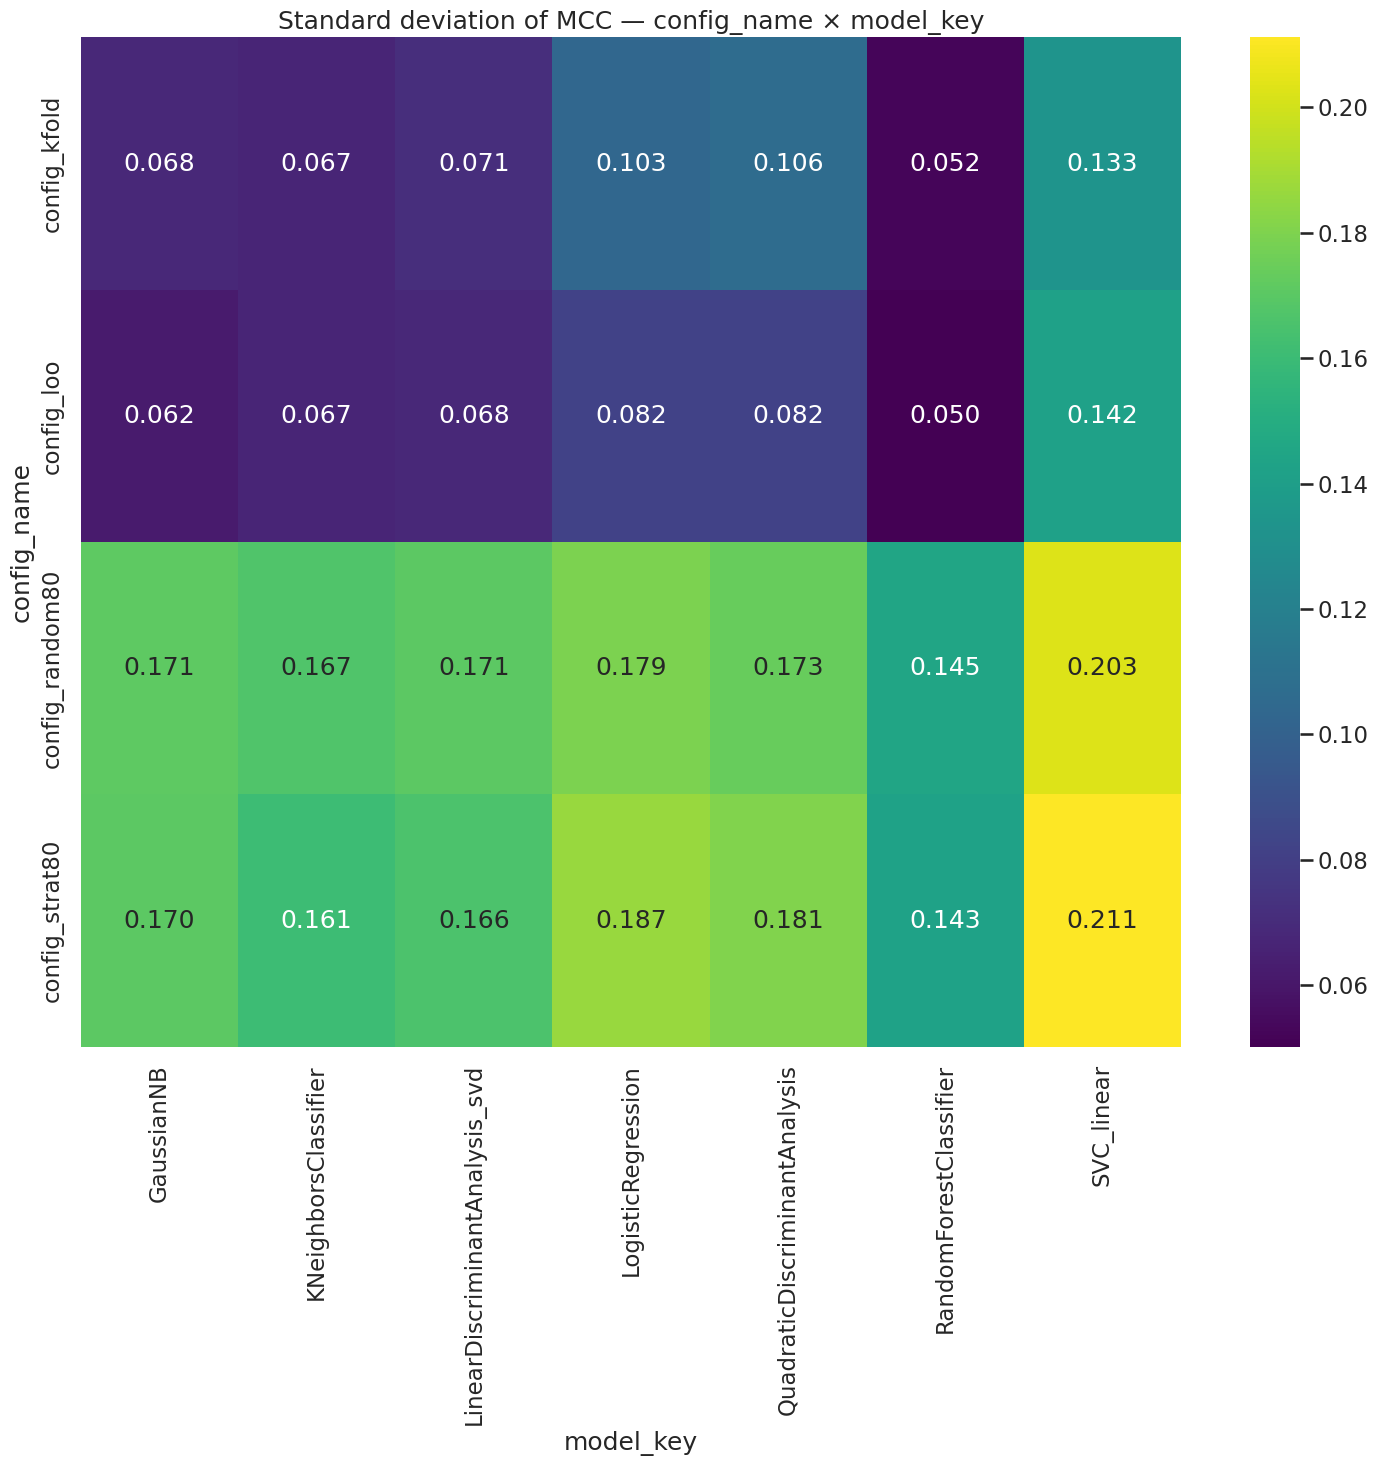

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_std_mcc_config_name_x_model_key.png


In [22]:
for row_factor, col_factor in KEY_HEATMAPS:
    heat_std = build_heatmap_table(analysis_df, row_factor, col_factor, PRIMARY_METRIC, aggfunc="std")
    plot_heatmap(
        heat_std,
        title=f"Standard deviation of {PRIMARY_METRIC.upper()} — {row_factor} × {col_factor}",
        filename=f"heatmap_std_{PRIMARY_METRIC}_{row_factor}_x_{col_factor}",
        center=None,
        annot=True,
        fmt=".3f",
    )


## 5. Context-specific contrasts

The next analyses ask whether a factor behaves differently depending on context.  
For example, a resampling strategy may look favorable overall, but only under a subset of models or only for one dataset representation.


In [23]:
contrast_specs = [
    (MODEL_COL, RESAMPLING_COL),
    (MODEL_COL, SCALER_COL),
    (DATASET_COL, RESAMPLING_COL),
    (DATASET_COL, SCALER_COL),
    (CONFIG_COL, MODEL_COL),
]

contrast_results = {}
for context_col, factor_col in contrast_specs:
    out = contrast_within_context(analysis_df, context_col, factor_col, PRIMARY_METRIC)
    key = f"{context_col}__{factor_col}"
    contrast_results[key] = out
    out_csv = TABLES_DIR / f"03_context_contrast_{key}.csv"
    out.to_csv(out_csv, index=False)

for key, out in contrast_results.items():
    print("\n", "=" * 80)
    print(key)
    display(out.head(15))



model_key__resampling


,model_key,best_level,best_mean,best_std,best_count,worst_level,worst_mean,worst_std,worst_count,delta_best_worst
6,SVC_linear,smote,0.456068,0.166233,91488,none,0.343480,0.157807,22860,0.112588
4,QuadraticDiscriminantAnalysis,undersample,0.361314,0.144494,24588,none,0.256756,0.176814,12236,0.104558
3,LogisticRegression,smote,0.475329,0.144392,98400,none,0.410870,0.181278,24568,0.064459
0,GaussianNB,undersample,0.406654,0.135872,21705,none,0.348756,0.150855,10852,0.057898
2,LinearDiscriminantAnalysis_svd,smote,0.477228,0.133270,16400,none,0.422768,0.133330,4100,0.054461
1,KNeighborsClassifier,undersample,0.377646,0.128316,130935,none,0.332212,0.131244,65466,0.045433
5,RandomForestClassifier,smote,0.414343,0.112540,166692,smoteenn,0.374821,0.113069,166693,0.039522



model_key__scaler


,model_key,best_level,best_mean,best_std,best_count,worst_level,worst_mean,worst_std,worst_count,delta_best_worst
6,SVC_linear,standard,0.475148,0.126768,80817,maxabs,0.380205,0.221270,80203,0.094943
4,QuadraticDiscriminantAnalysis,standard,0.363130,0.120021,43296,maxabs,0.287095,0.170976,43216,0.076035
3,LogisticRegression,standard,0.488630,0.116740,86592,maxabs,0.420835,0.170931,86540,0.067795
1,KNeighborsClassifier,none,0.382317,0.110813,28809,robust,0.334137,0.130606,230461,0.048180
2,LinearDiscriminantAnalysis_svd,standard,0.472013,0.119670,14432,robust,0.439750,0.145333,14432,0.032263
0,GaussianNB,standard,0.403970,0.123753,38197,maxabs,0.376257,0.134645,38198,0.027713
5,RandomForestClassifier,maxabs,0.402676,0.110189,114510,none,0.395819,0.112647,114710,0.006856



dataset_variant__resampling


,dataset_variant,best_level,best_mean,best_std,best_count,worst_level,worst_mean,worst_std,worst_count,delta_best_worst
0,IMPUTED,undersample,0.407045,0.148627,178916,none,0.356416,0.154613,89403,0.050629
1,STRICT,undersample,0.397673,0.141330,184800,none,0.364130,0.146785,92354,0.033543



dataset_variant__scaler


,dataset_variant,best_level,best_mean,best_std,best_count,worst_level,worst_mean,worst_std,worst_count,delta_best_worst
0,IMPUTED,standard,0.411978,0.134019,299860,maxabs,0.380667,0.156629,299301,0.031311
1,STRICT,standard,0.404829,0.125307,308452,robust,0.380009,0.142187,308542,0.024820



config_name__model_key


,config_name,best_level,best_mean,best_std,best_count,worst_level,worst_mean,worst_std,worst_count,delta_best_worst
0,config_kfold,LogisticRegression,0.457378,0.103030,132000,QuadraticDiscriminantAnalysis,0.325304,0.106475,66000,0.132074
3,config_strat80,LinearDiscriminantAnalysis_svd,0.467625,0.165523,11000,QuadraticDiscriminantAnalysis,0.340152,0.180897,33000,0.127472
2,config_random80,LogisticRegression,0.446662,0.179349,66000,QuadraticDiscriminantAnalysis,0.321962,0.173480,33000,0.124700
1,config_loo,LogisticRegression,0.454609,0.081691,6548,QuadraticDiscriminantAnalysis,0.336464,0.081831,3220,0.118145


## 6. Combination ranking under fair comparison

Here we rank **full combinations** using the primary metric while preserving comparable evaluation settings.  
This helps identify which full pipeline designs dominate not only on average, but also in terms of stability and support.


In [24]:
combination_cols = [DATASET_COL, CONFIG_COL, MODEL_COL, SCALER_COL, RESAMPLING_COL, PCA_COL]

combo_summary = (
    analysis_df.groupby(combination_cols, dropna=False)[AVAILABLE_METRICS]
    .agg(["mean", "std", "count", "median"])
)

combo_summary.columns = ["__".join(col).strip("_") for col in combo_summary.columns]
combo_summary = combo_summary.reset_index()

primary_mean_col = f"{PRIMARY_METRIC}__mean"
primary_std_col = f"{PRIMARY_METRIC}__std"
primary_count_col = f"{PRIMARY_METRIC}__count"

combo_summary = combo_summary.sort_values(
    by=[primary_mean_col, primary_count_col],
    ascending=[False, False],
).reset_index(drop=True)

combo_summary.to_csv(TABLES_DIR / "03_combination_ranking.csv", index=False)
combo_summary.head(25)


,dataset_variant,config_name,model_key,scaler,resampling,pca,mcc__mean,mcc__std,mcc__count,mcc__median,balanced_accuracy__mean,balanced_accuracy__std,balanced_accuracy__count,balanced_accuracy__median,f1__mean,f1__std,f1__count,f1__median,accuracy__mean,accuracy__std,accuracy__count,accuracy__median,precision__mean,precision__std,precision__count,precision__median,recall__mean,recall__std,recall__count,recall__median
0,IMPUTED,config_strat80,SVC_linear,robust,smote,off,0.564179,0.172716,480,0.571635,0.800705,0.088281,480,0.814010,0.690950,0.118900,480,0.695652,0.790885,0.080142,480,0.781250,0.608111,0.135847,480,0.577381,0.823148,0.151962,480,0.888889
1,IMPUTED,config_strat80,LogisticRegression,robust,smote,off,0.562464,0.173211,480,0.571635,0.800010,0.087132,480,0.814010,0.688245,0.118239,480,0.695652,0.783203,0.082471,480,0.781250,0.600047,0.145987,480,0.562500,0.838426,0.155899,480,0.888889
2,IMPUTED,config_strat80,SVC_linear,standard,smote,off,0.559993,0.175007,480,0.569191,0.796860,0.088020,480,0.804348,0.688092,0.121515,480,0.692308,0.790625,0.081685,480,0.781250,0.611904,0.143404,480,0.571429,0.811111,0.151353,480,0.888889
3,IMPUTED,config_strat80,SVC_linear,standard,smote,on,0.556998,0.172693,3360,0.569191,0.794097,0.087274,3360,0.801932,0.684355,0.119333,3360,0.695652,0.789025,0.080324,3360,0.781250,0.612769,0.146112,3360,0.571429,0.805688,0.159802,3360,0.888889
4,IMPUTED,config_strat80,LogisticRegression,standard,smote,off,0.554603,0.172395,480,0.569191,0.797252,0.087445,480,0.814010,0.683494,0.118405,480,0.692308,0.777214,0.083379,480,0.750000,0.588735,0.139725,480,0.538462,0.843056,0.153679,480,0.888889
5,IMPUTED,config_strat80,LinearDiscriminantAnalysis_svd,maxabs,smote,off,0.553450,0.178322,80,0.593180,0.795652,0.091410,80,0.812802,0.684097,0.122979,80,0.710000,0.782813,0.086107,80,0.781250,0.596987,0.138185,80,0.572917,0.825000,0.153894,80,0.888889
6,IMPUTED,config_strat80,LinearDiscriminantAnalysis_svd,standard,smote,off,0.550009,0.187299,80,0.547925,0.791727,0.093175,80,0.803140,0.682320,0.129257,80,0.679487,0.782031,0.091545,80,0.765625,0.602817,0.155532,80,0.553977,0.813889,0.150817,80,0.888889
7,IMPUTED,config_strat80,LogisticRegression,none,smote,off,0.549983,0.165168,480,0.569191,0.793926,0.083860,480,0.814010,0.679915,0.113580,480,0.692308,0.778711,0.077339,480,0.781250,0.591019,0.134639,480,0.562500,0.828704,0.156409,480,0.888889
8,IMPUTED,config_strat80,LogisticRegression,standard,smote,on,0.543917,0.164758,3360,0.526660,0.791117,0.084106,3360,0.792271,0.676446,0.112552,3360,0.666667,0.773400,0.081094,3360,0.750000,0.584962,0.135133,3360,0.538462,0.831614,0.151286,3360,0.888889
9,IMPUTED,config_strat80,LogisticRegression,none,none,off,0.543736,0.159801,120,0.543955,0.768398,0.082040,120,0.778986,0.656721,0.114270,120,0.666667,0.794271,0.073660,120,0.812500,0.670357,0.185504,120,0.625874,0.709259,0.203804,120,0.777778


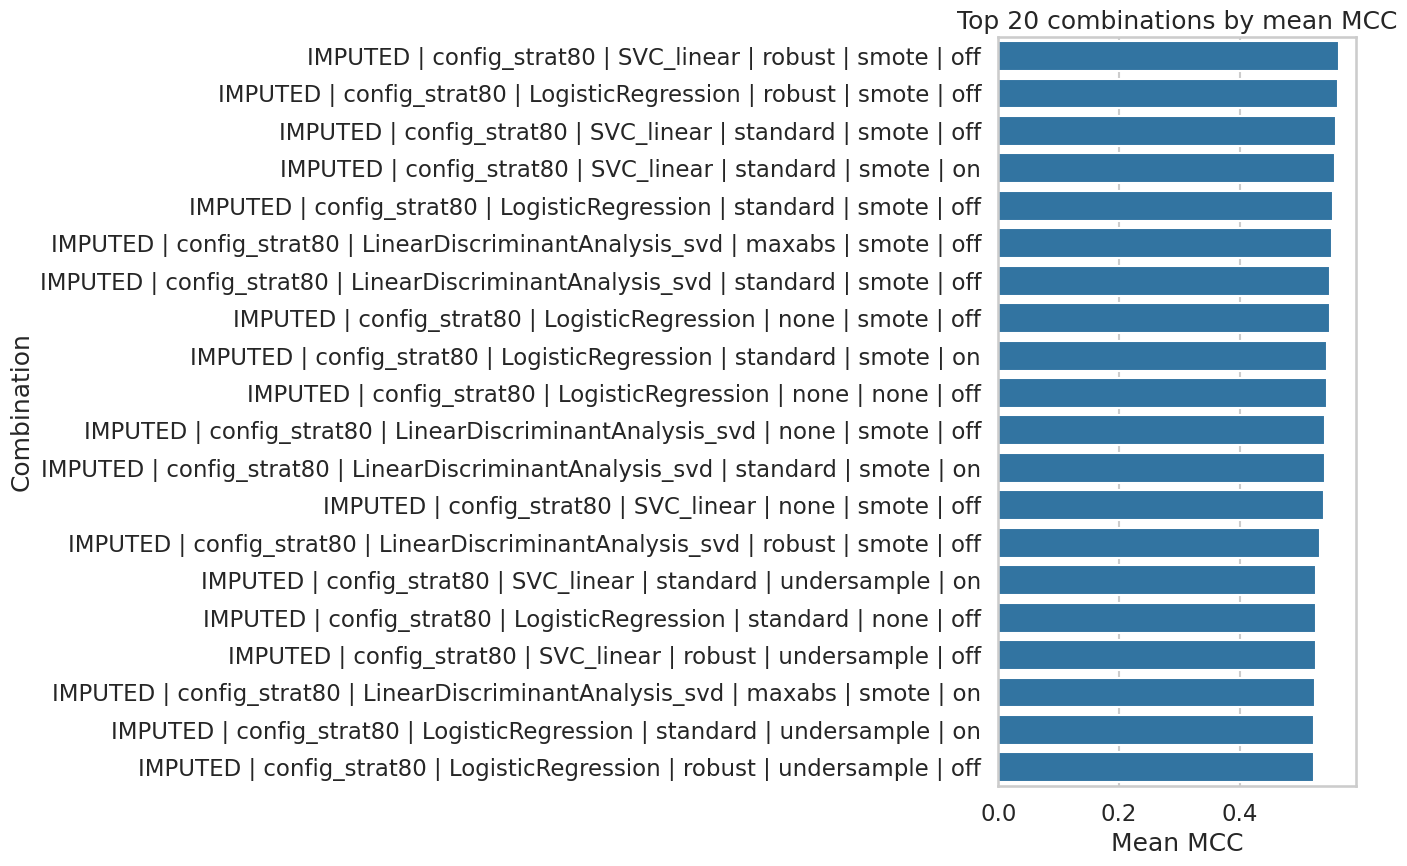

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/top_20_combinations_by_mcc.png


In [25]:
# Plot top combinations by primary metric
top_n = 20
plot_df = combo_summary.head(top_n).copy()
plot_df["combo_label"] = (
    plot_df[DATASET_COL].astype(str) + " | " +
    plot_df[CONFIG_COL].astype(str) + " | " +
    plot_df[MODEL_COL].astype(str) + " | " +
    plot_df[SCALER_COL].astype(str) + " | " +
    plot_df[RESAMPLING_COL].astype(str) + " | " +
    plot_df[PCA_COL].astype(str)
)

plt.figure(figsize=(14, max(8, top_n * 0.45)))
sns.barplot(data=plot_df, y="combo_label", x=primary_mean_col)
plt.title(f"Top {top_n} combinations by mean {PRIMARY_METRIC.upper()}")
plt.xlabel(f"Mean {PRIMARY_METRIC.upper()}")
plt.ylabel("Combination")
out = save_current_figure(f"top_{top_n}_combinations_by_{PRIMARY_METRIC}")
plt.show()
print("Saved:", out)


## 7. Dominance of factor levels within top-performing combinations

This section evaluates whether some factor levels are overrepresented among the strongest combinations, which can help justify downstream model selection decisions.


In [26]:
top_fraction = 0.20
k = max(1, int(np.ceil(combo_summary.shape[0] * top_fraction)))
top_combo_df = combo_summary.head(k).copy()

dominance_tables = {}
for factor in [DATASET_COL, CONFIG_COL, MODEL_COL, SCALER_COL, RESAMPLING_COL, PCA_COL]:
    tbl = (
        top_combo_df[factor]
        .value_counts(dropna=False)
        .rename_axis(factor)
        .reset_index(name="count_top")
    )
    tbl["fraction_top"] = tbl["count_top"] / tbl["count_top"].sum()

    global_counts = (
        combo_summary[factor]
        .value_counts(dropna=False)
        .rename_axis(factor)
        .reset_index(name="count_global")
    )
    tbl = tbl.merge(global_counts, on=factor, how="left")
    tbl["fraction_global"] = tbl["count_global"] / tbl["count_global"].sum()
    tbl["enrichment_top_vs_global"] = tbl["fraction_top"] / tbl["fraction_global"]
    tbl = tbl.sort_values("enrichment_top_vs_global", ascending=False)

    dominance_tables[factor] = tbl
    tbl.to_csv(TABLES_DIR / f"03_top_combination_dominance_{factor}.csv", index=False)

for factor, tbl in dominance_tables.items():
    print("\n", "=" * 80)
    print(factor)
    display(tbl.head(15))



dataset_variant


,dataset_variant,count_top,fraction_top,count_global,fraction_global,enrichment_top_vs_global
0,IMPUTED,173,0.588435,734,0.500341,1.176069
1,STRICT,121,0.411565,733,0.499659,0.823691



config_name


,config_name,count_top,fraction_top,count_global,fraction_global,enrichment_top_vs_global
0,config_strat80,86,0.292517,368,0.250852,1.166094
1,config_kfold,78,0.265306,368,0.250852,1.057620
2,config_random80,70,0.238095,368,0.250852,0.949146
3,config_loo,60,0.204082,363,0.247444,0.824760



model_key


...

,scaler,count_top,fraction_top,count_global,fraction_global,enrichment_top_vs_global
0,standard,128,0.435374,415,0.282890,1.539021
2,none,48,0.163265,223,0.152011,1.074037
1,robust,81,0.275510,415,0.282890,0.973912
3,maxabs,37,0.125850,414,0.282209,0.445948



resampling


,resampling,count_top,fraction_top,count_global,fraction_global,enrichment_top_vs_global
0,smote,115,0.391156,368,0.250852,1.559311
1,undersample,73,0.248299,367,0.250170,0.992521
2,none,53,0.180272,364,0.248125,0.726536
3,smoteenn,53,0.180272,368,0.250852,0.718639



pca


,pca,count_top,fraction_top,count_global,fraction_global,enrichment_top_vs_global
0,off,179,0.608844,891,0.607362,1.002439
1,on,115,0.391156,576,0.392638,0.996227


## 8. Interaction analyses across multiple metrics

To ensure that conclusions are not driven by a single metric, we repeat the main interaction summaries across all metrics that remain comparable under the current evaluation framework.


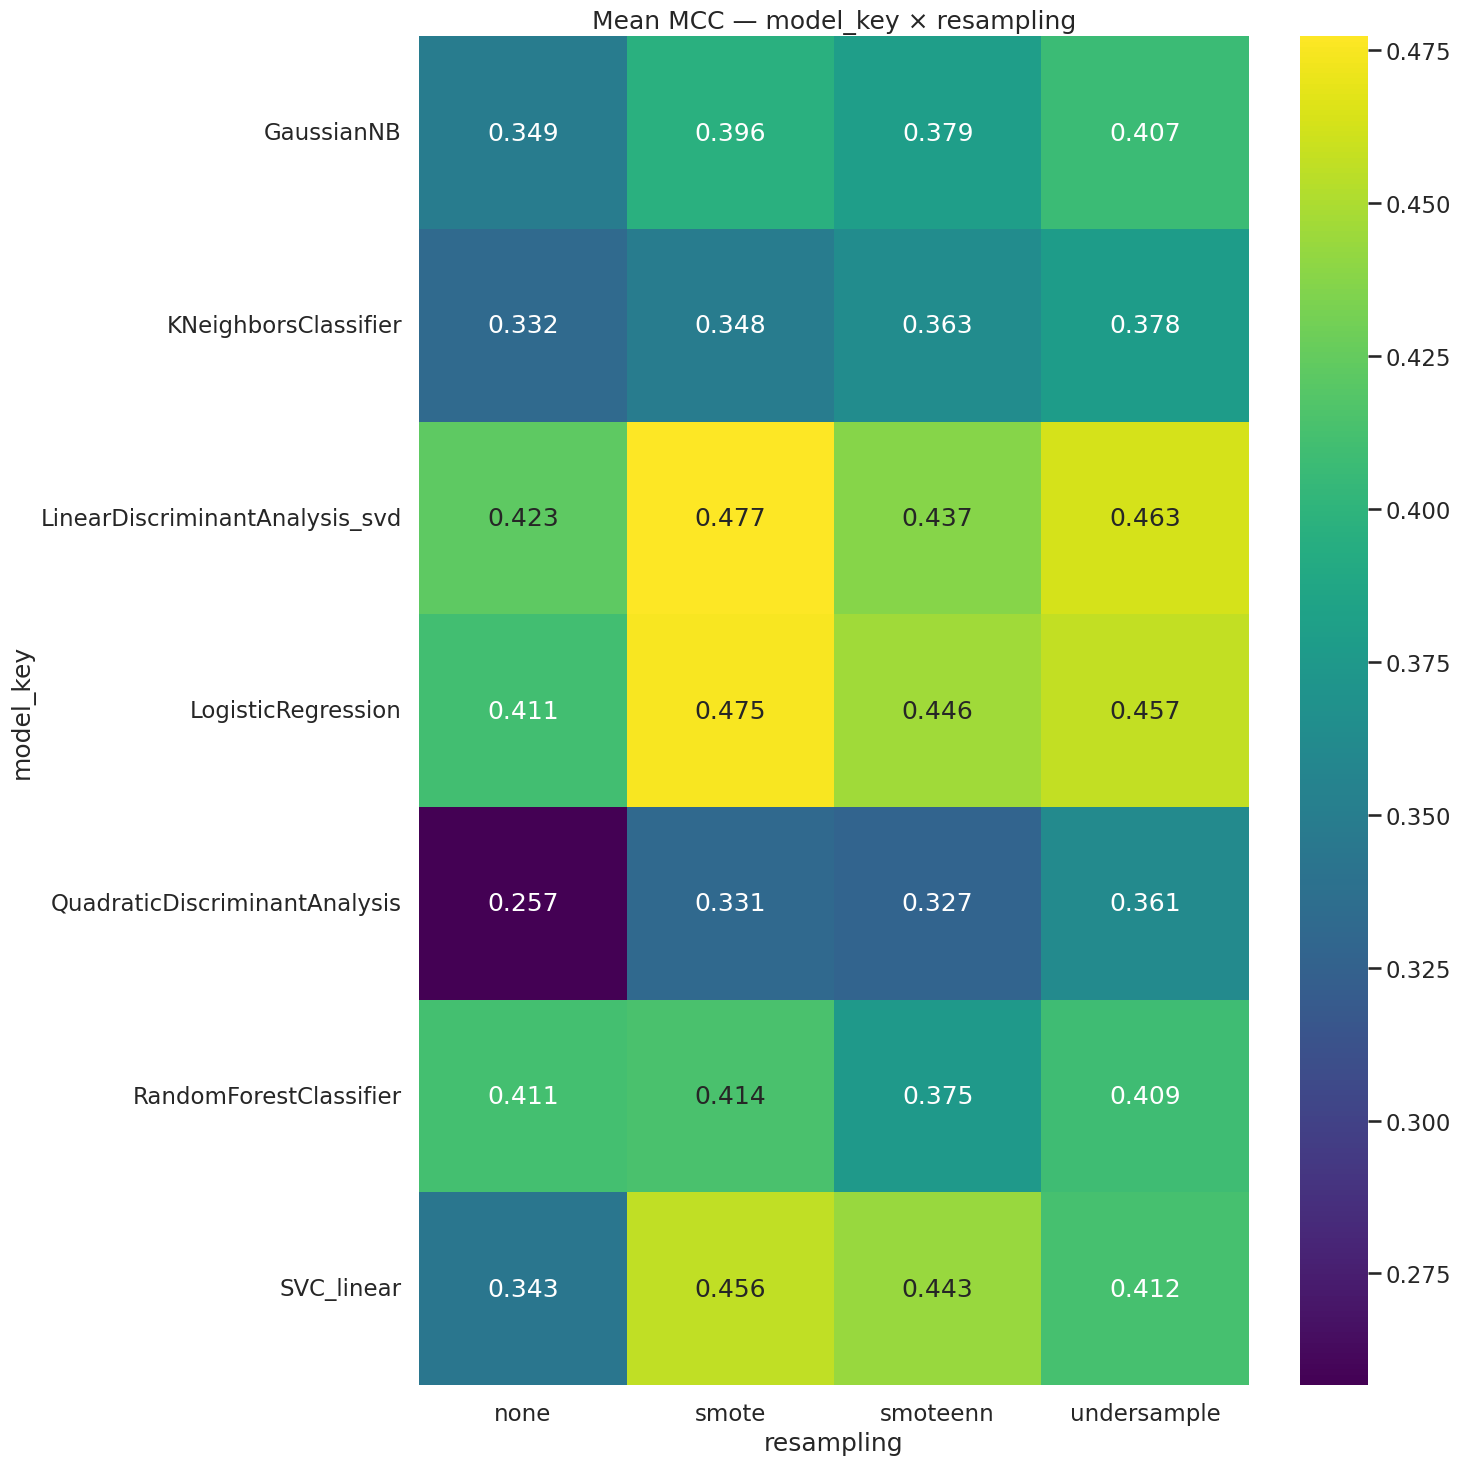

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_mcc_model_key_x_resampling.png


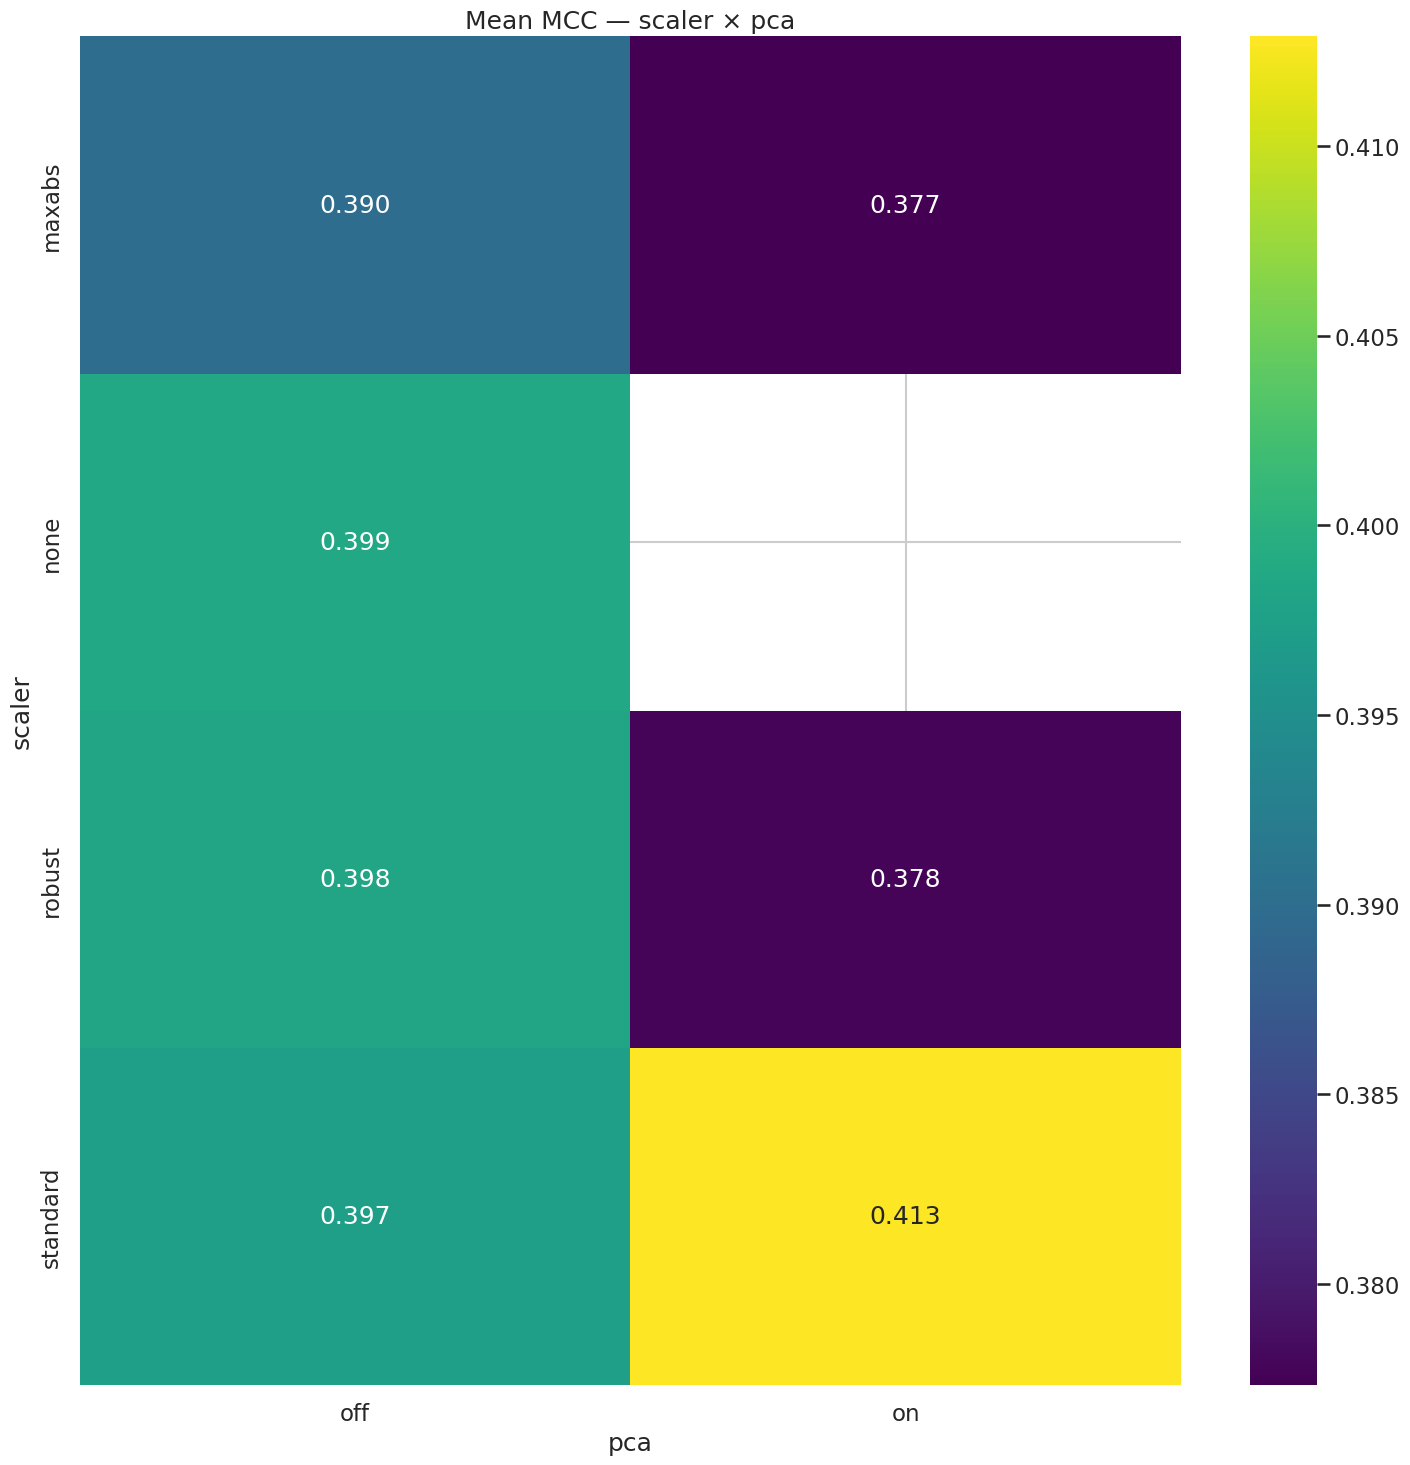

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_mcc_scaler_x_pca.png


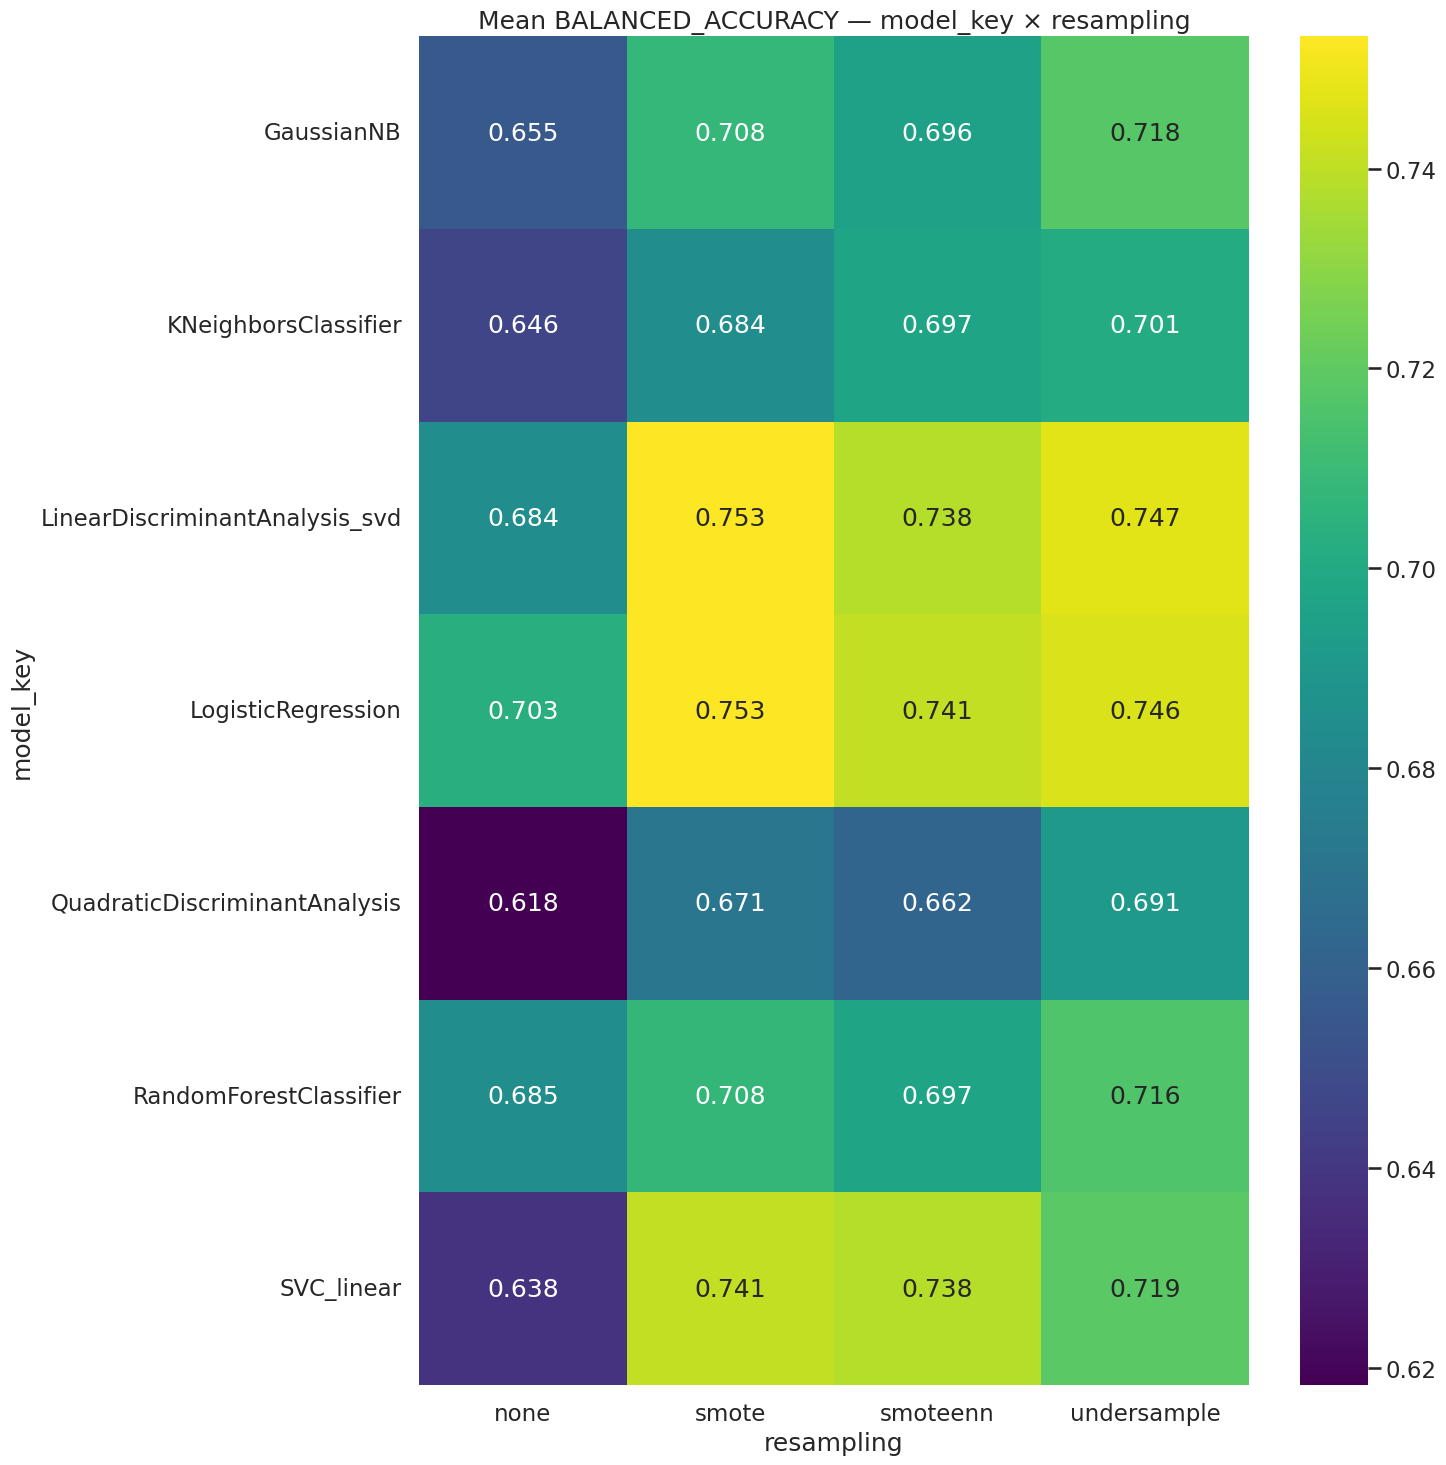

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_balanced_accuracy_model_key_x_resampling.png


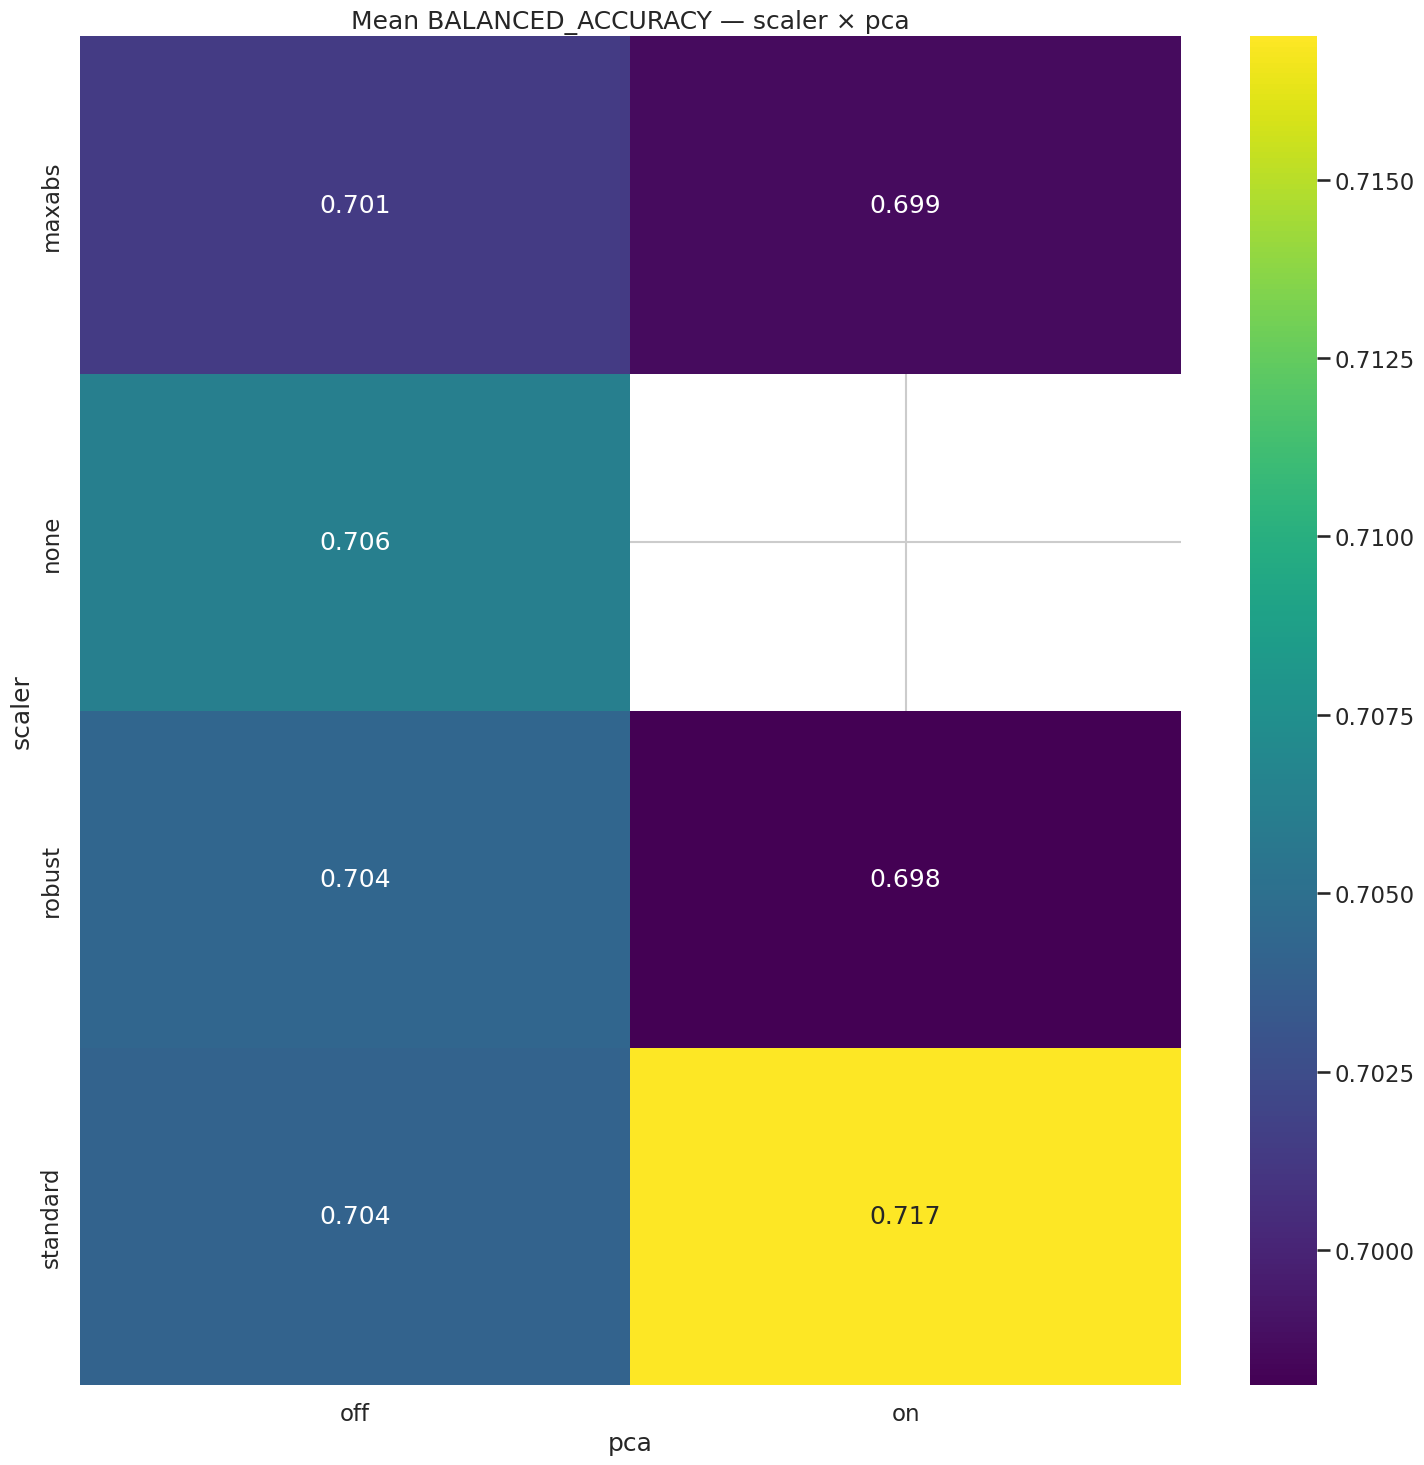

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_balanced_accuracy_scaler_x_pca.png


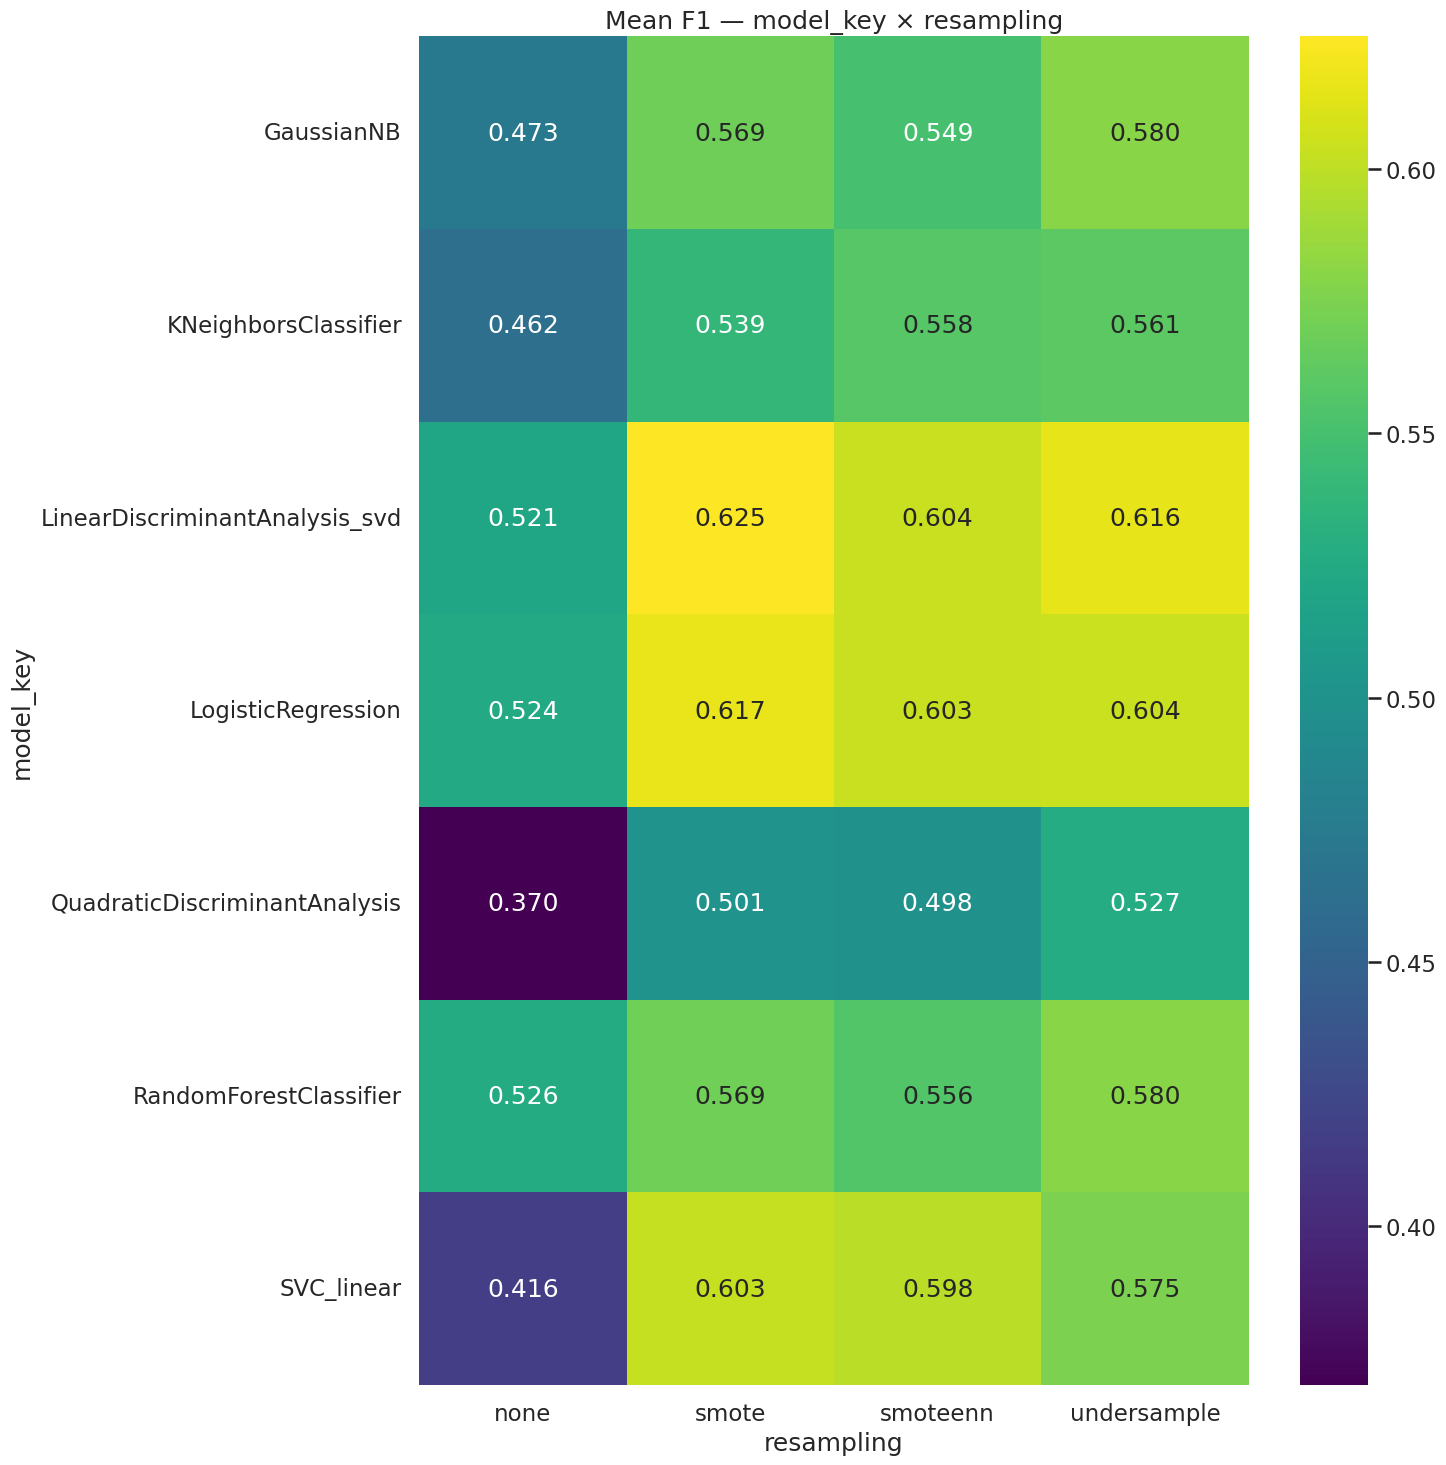

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_f1_model_key_x_resampling.png


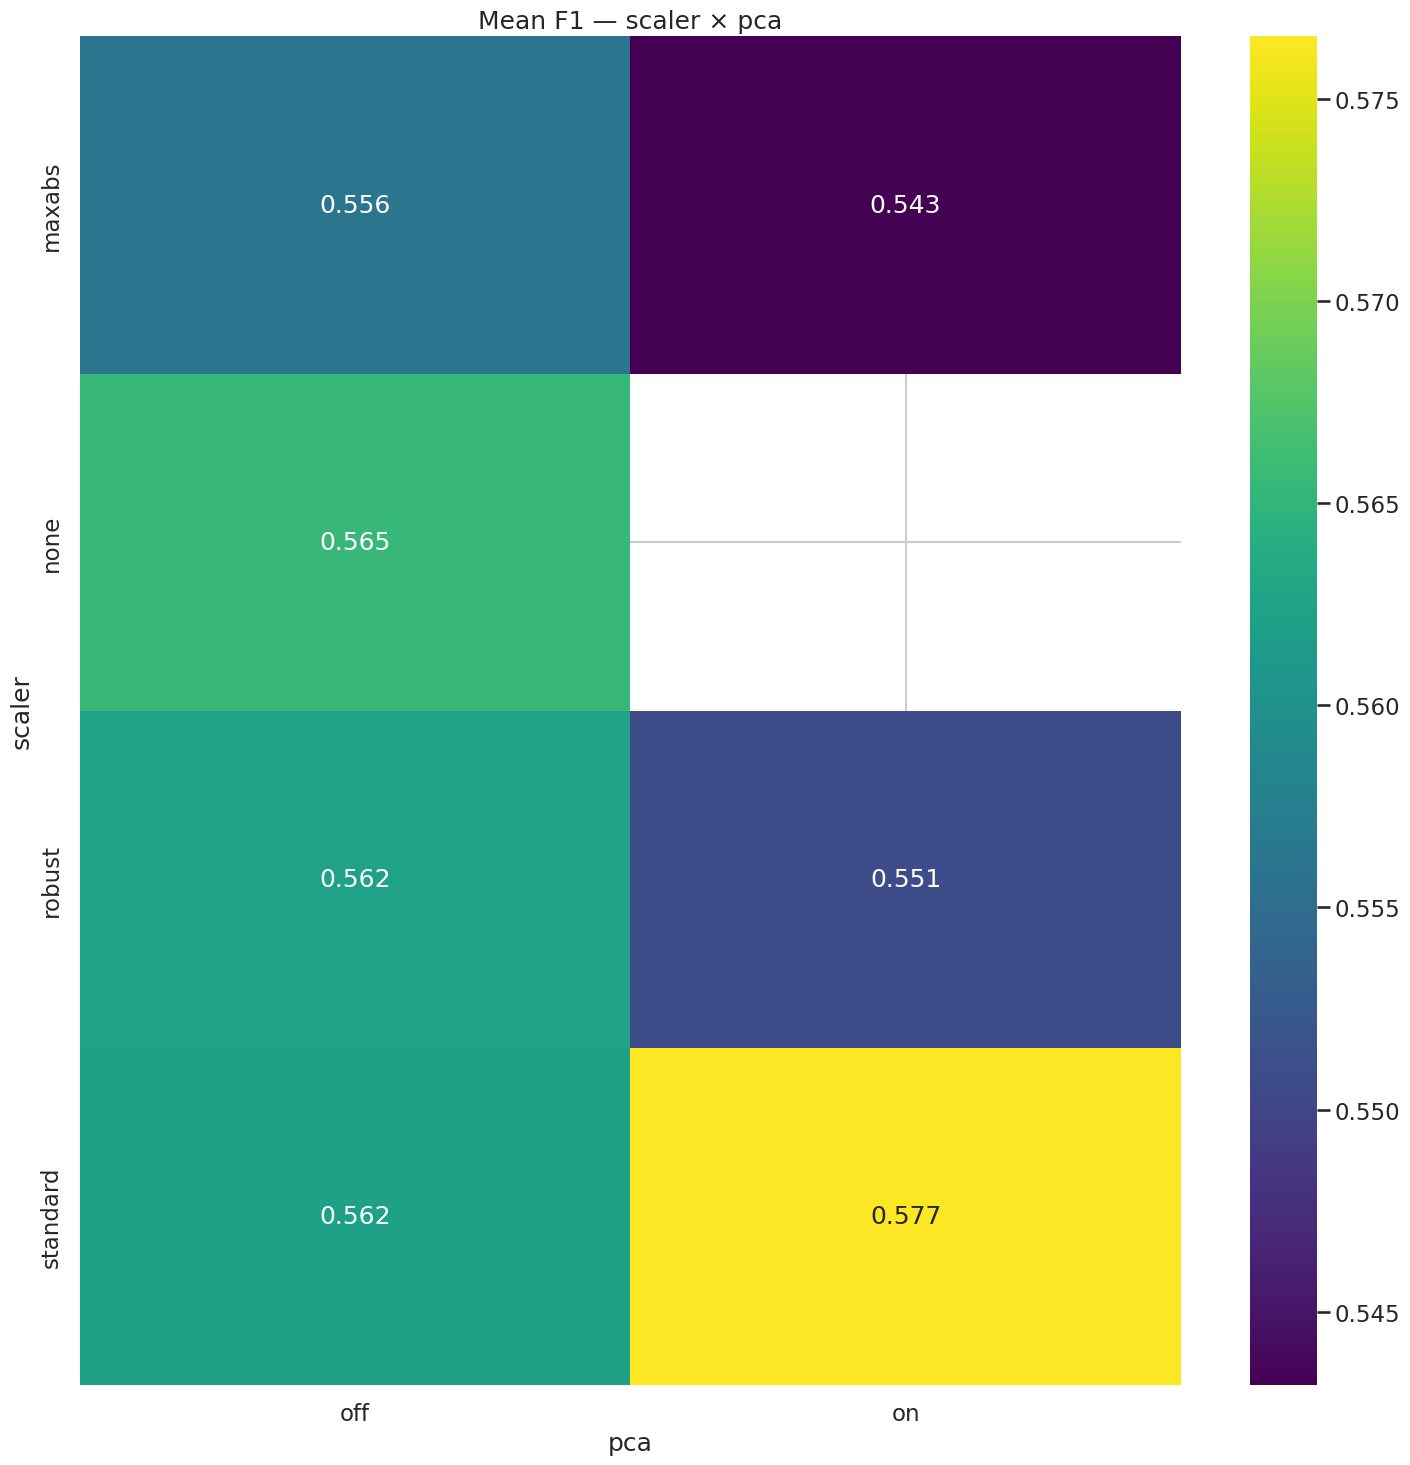

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_f1_scaler_x_pca.png


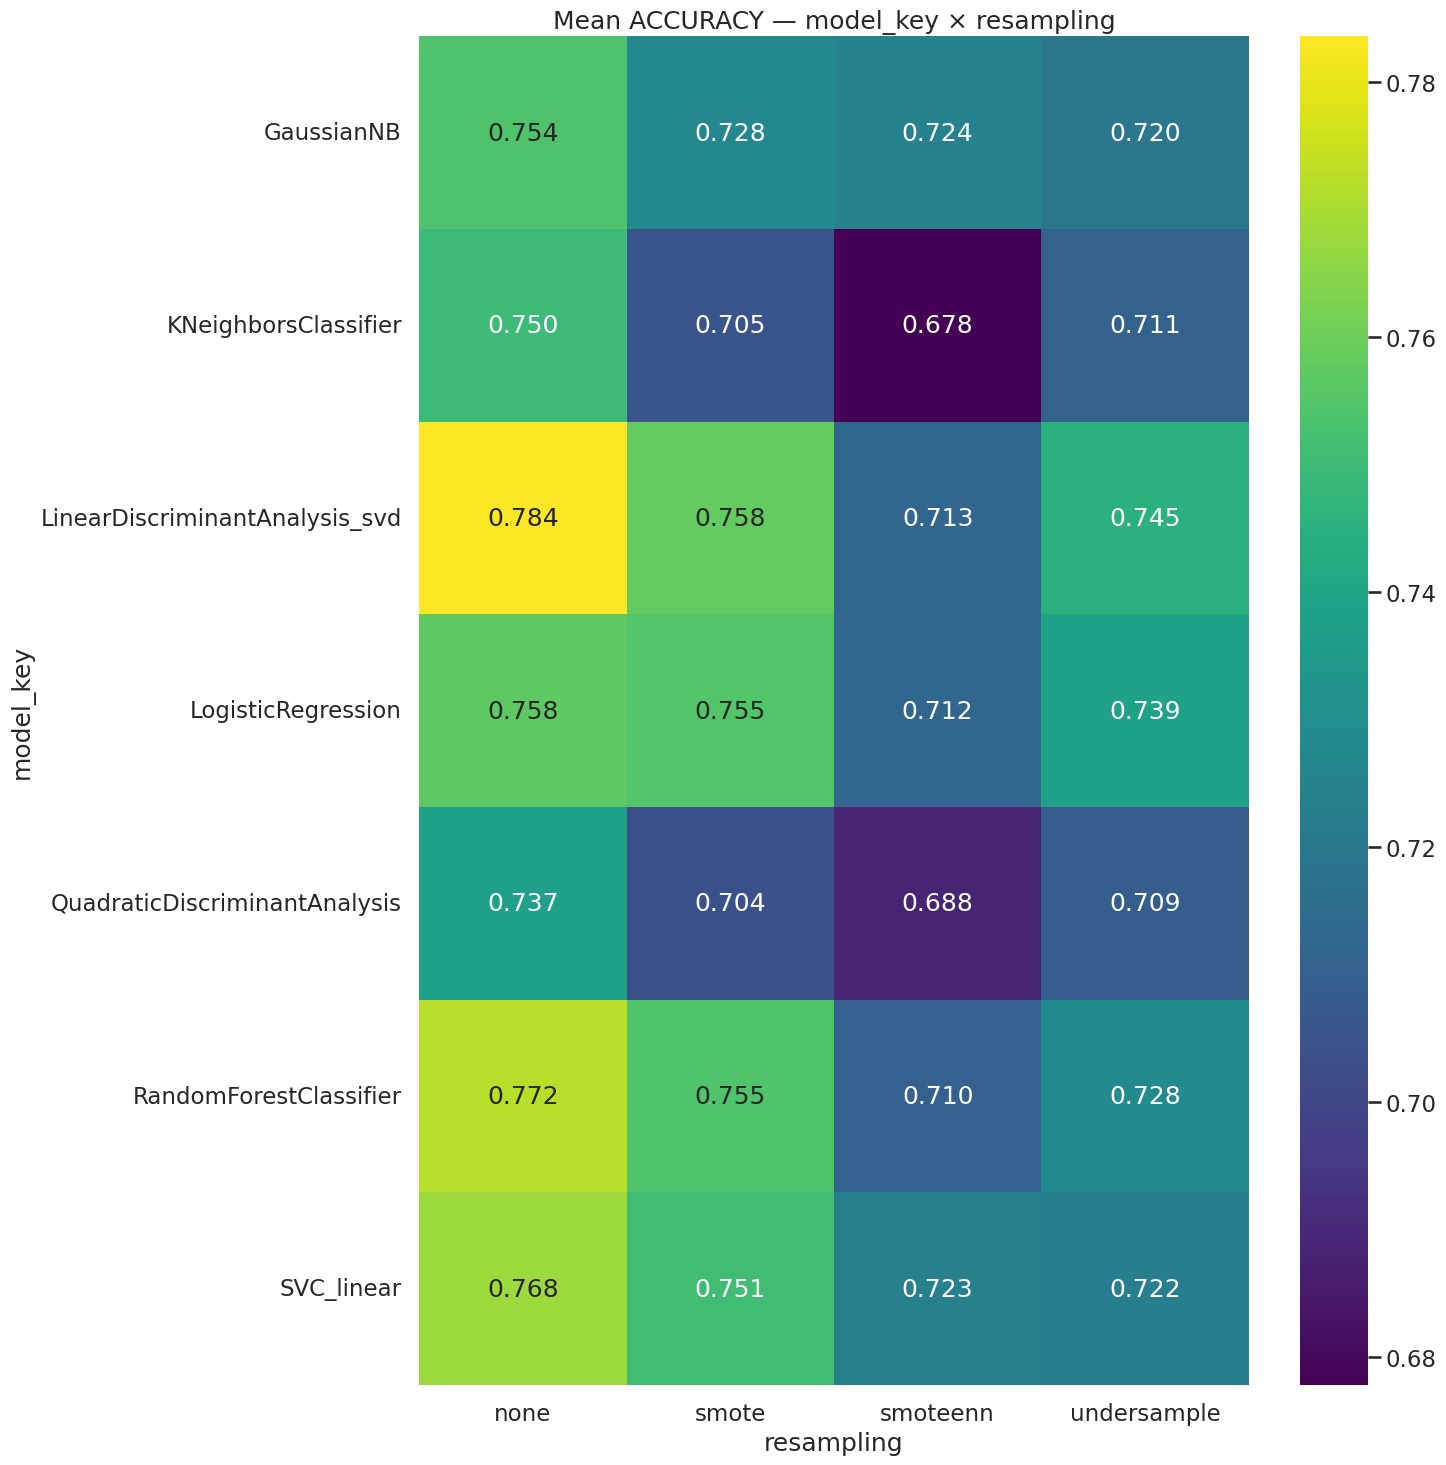

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_accuracy_model_key_x_resampling.png


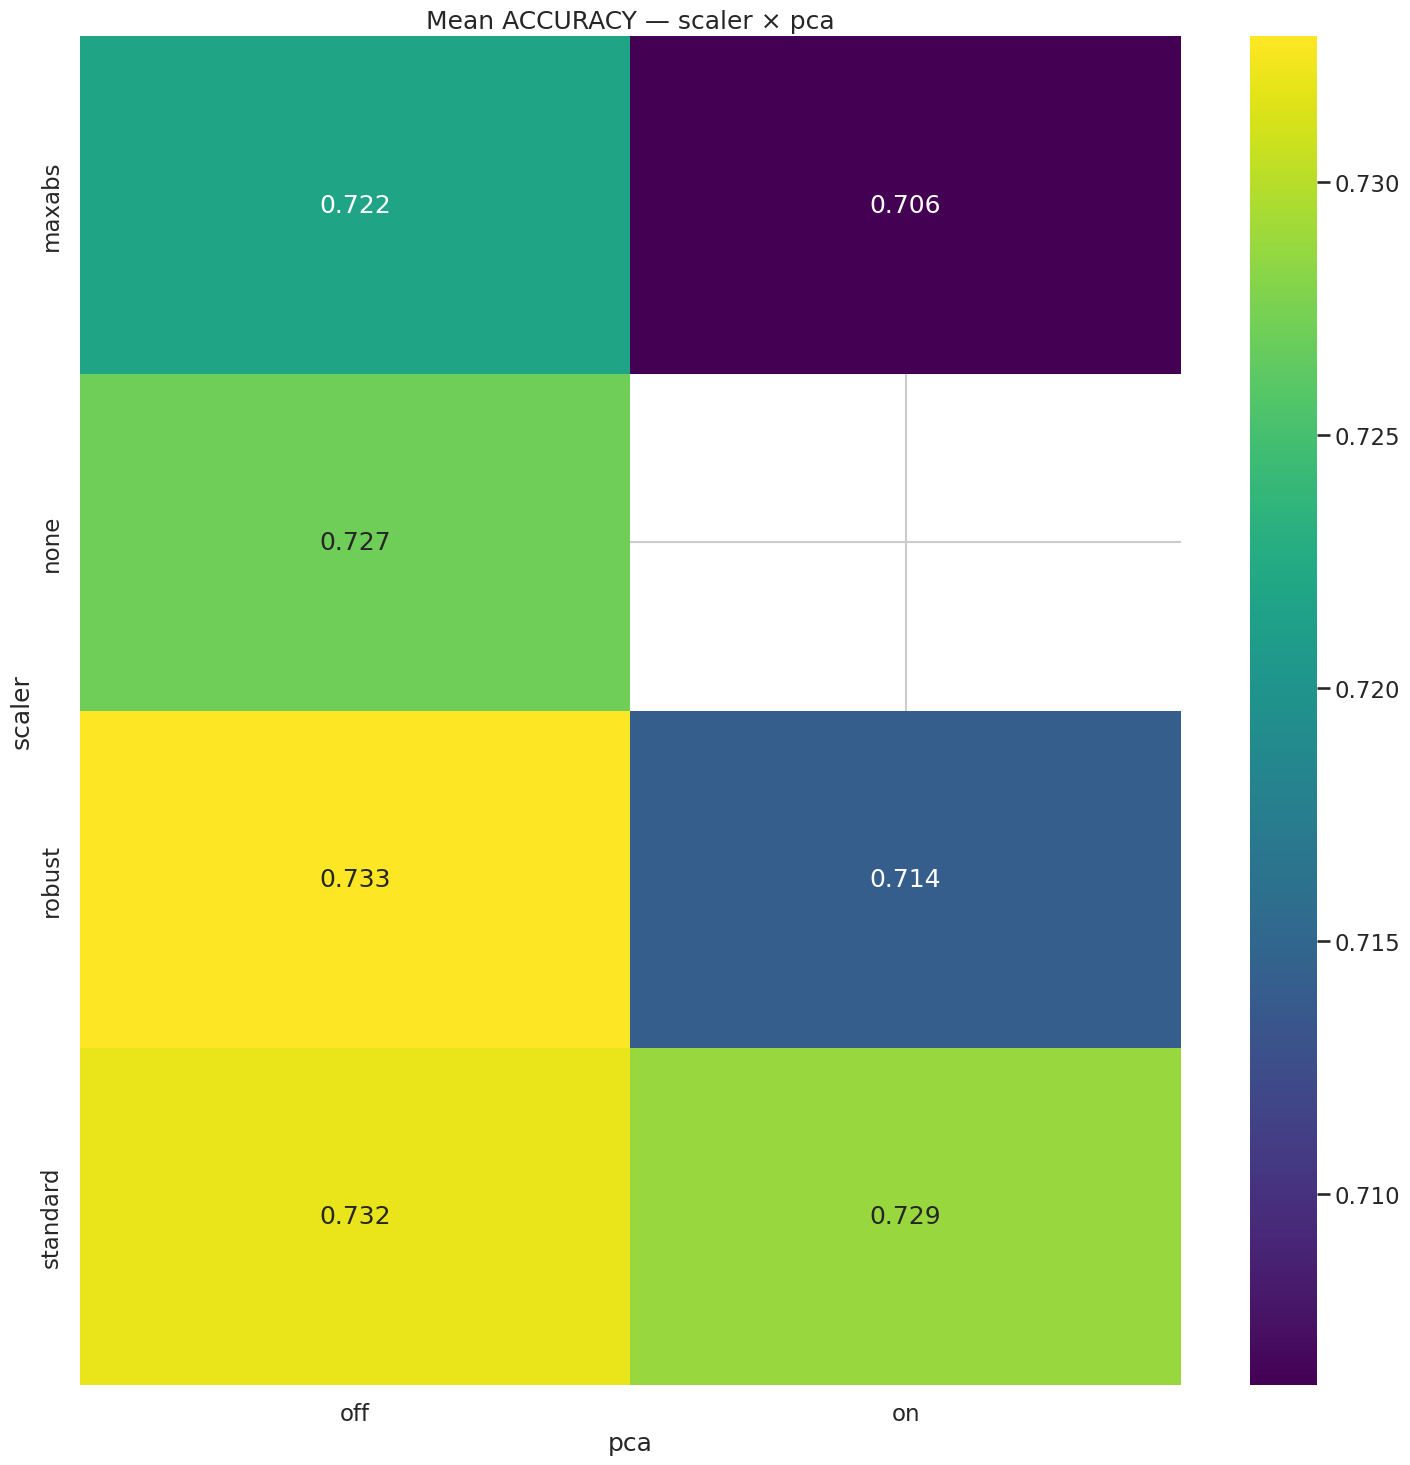

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_accuracy_scaler_x_pca.png


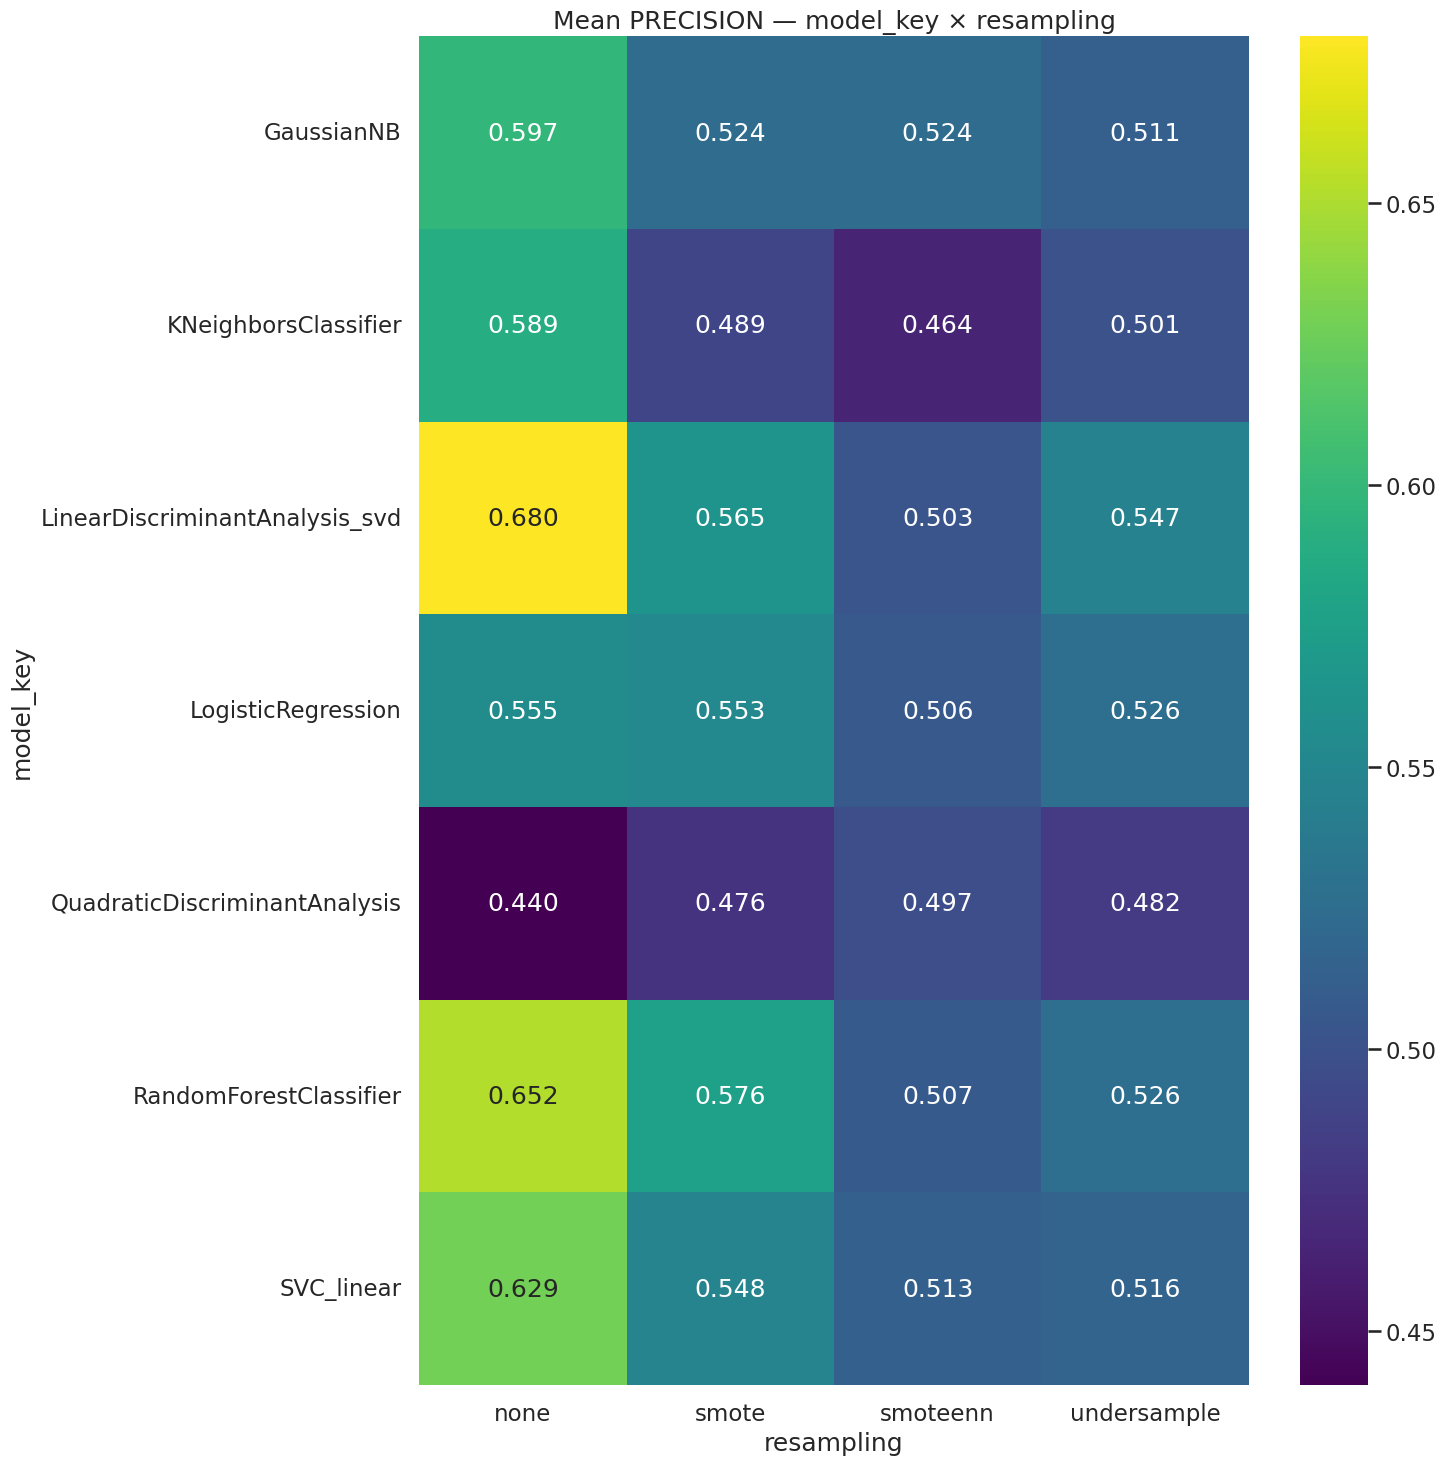

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_precision_model_key_x_resampling.png


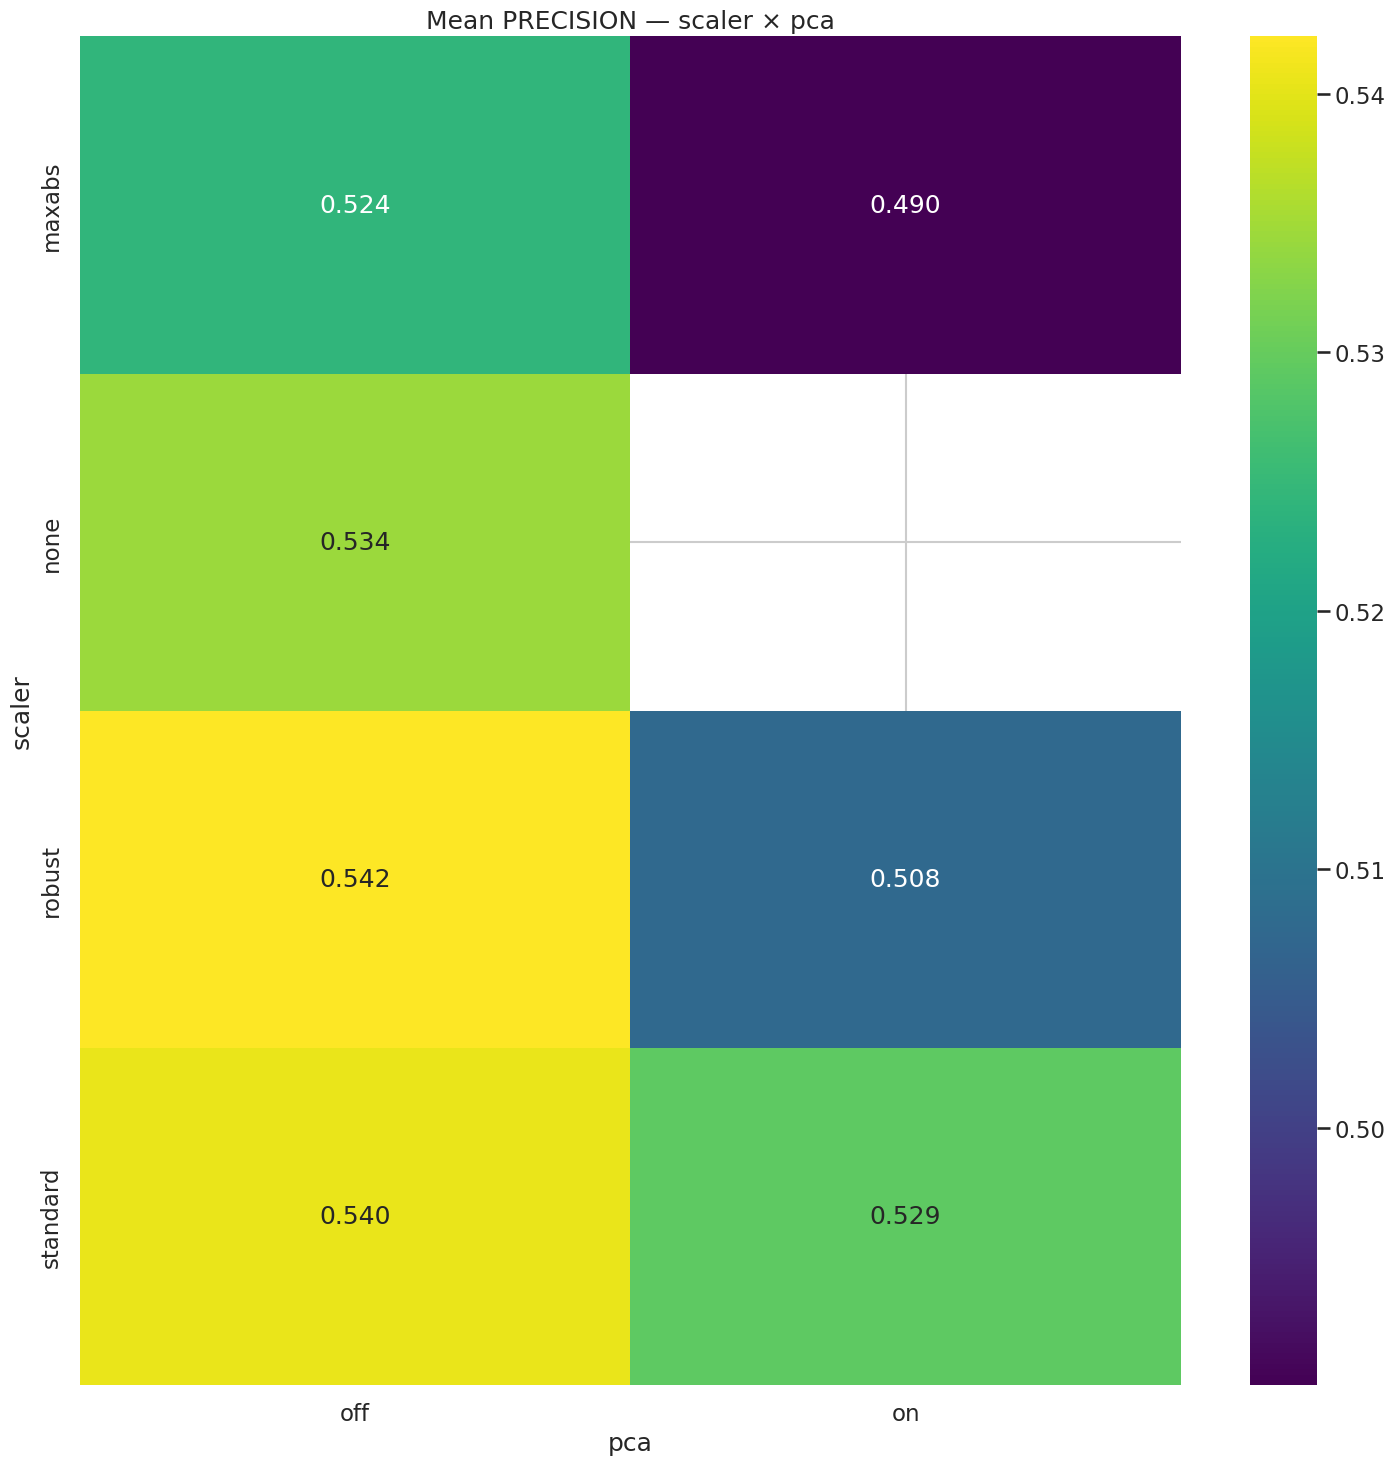

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_precision_scaler_x_pca.png


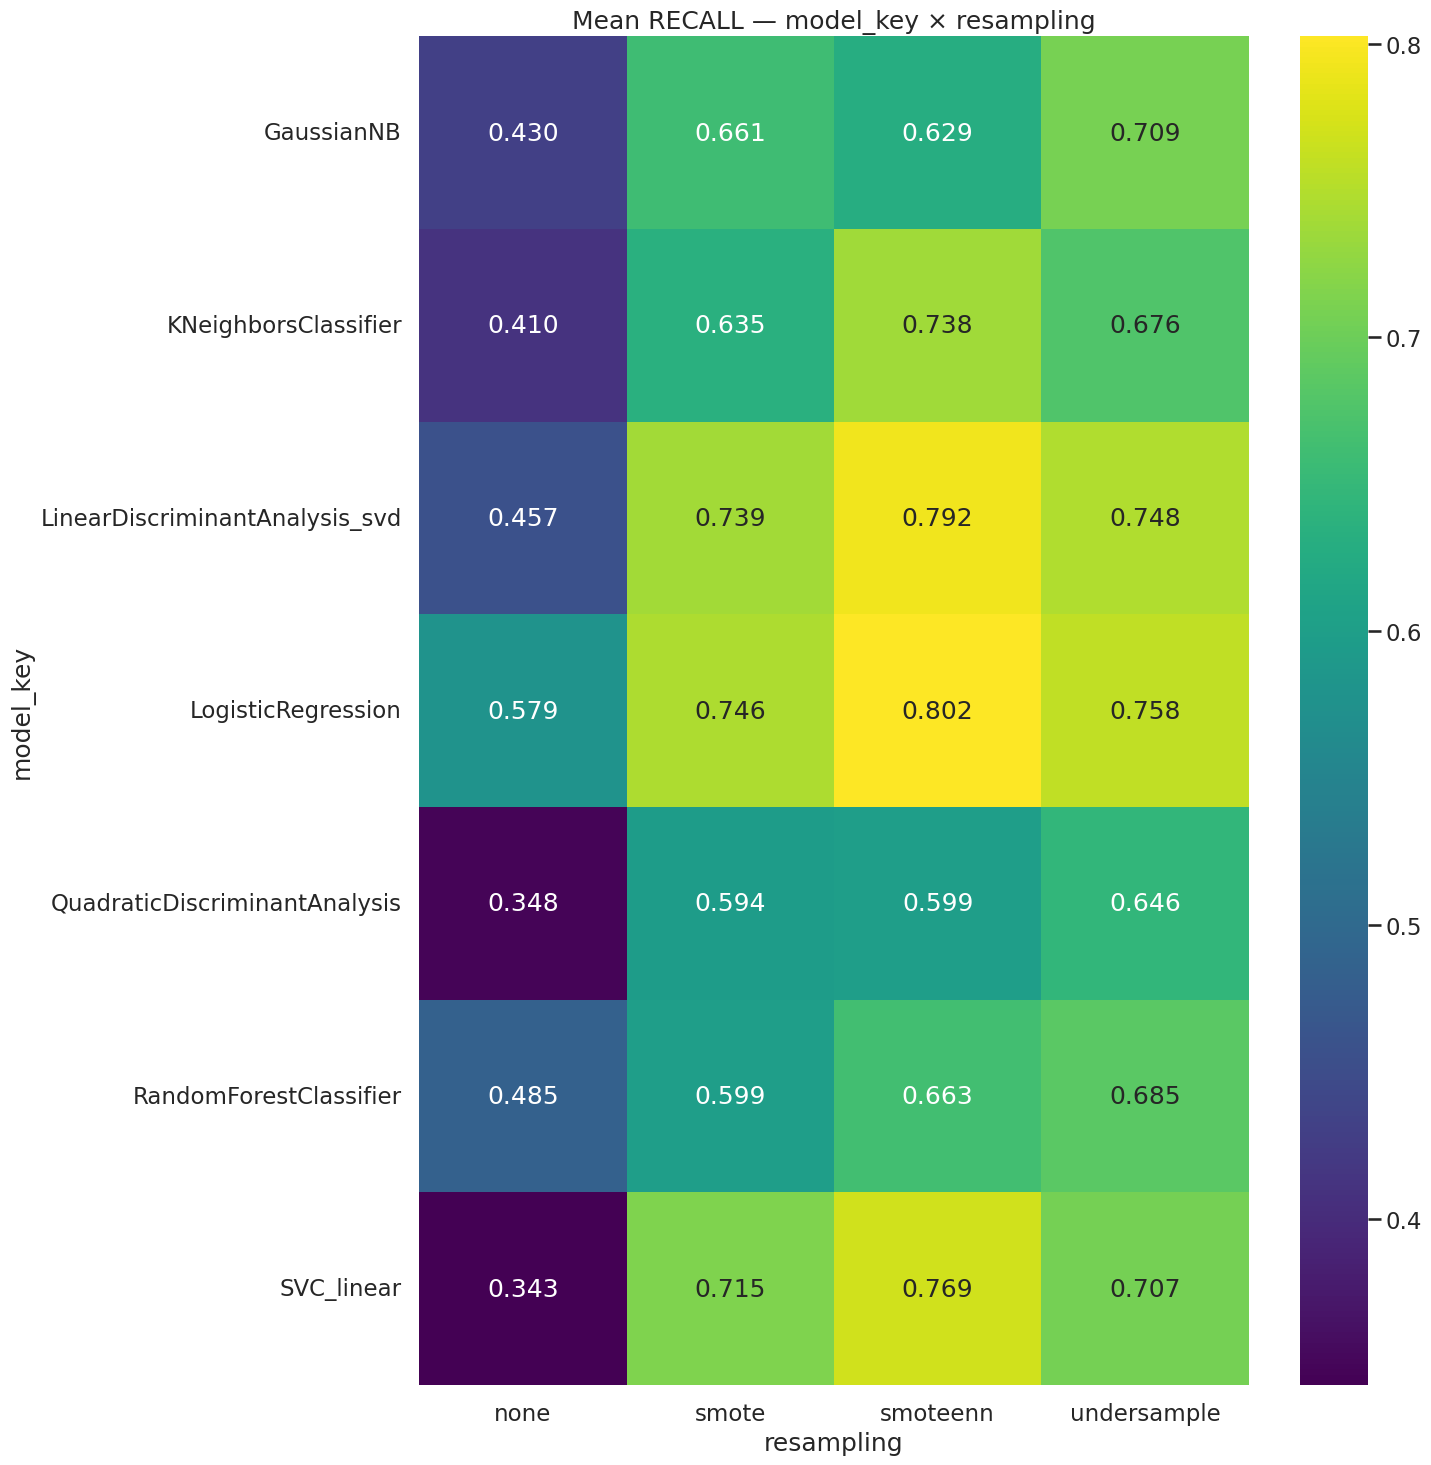

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_recall_model_key_x_resampling.png


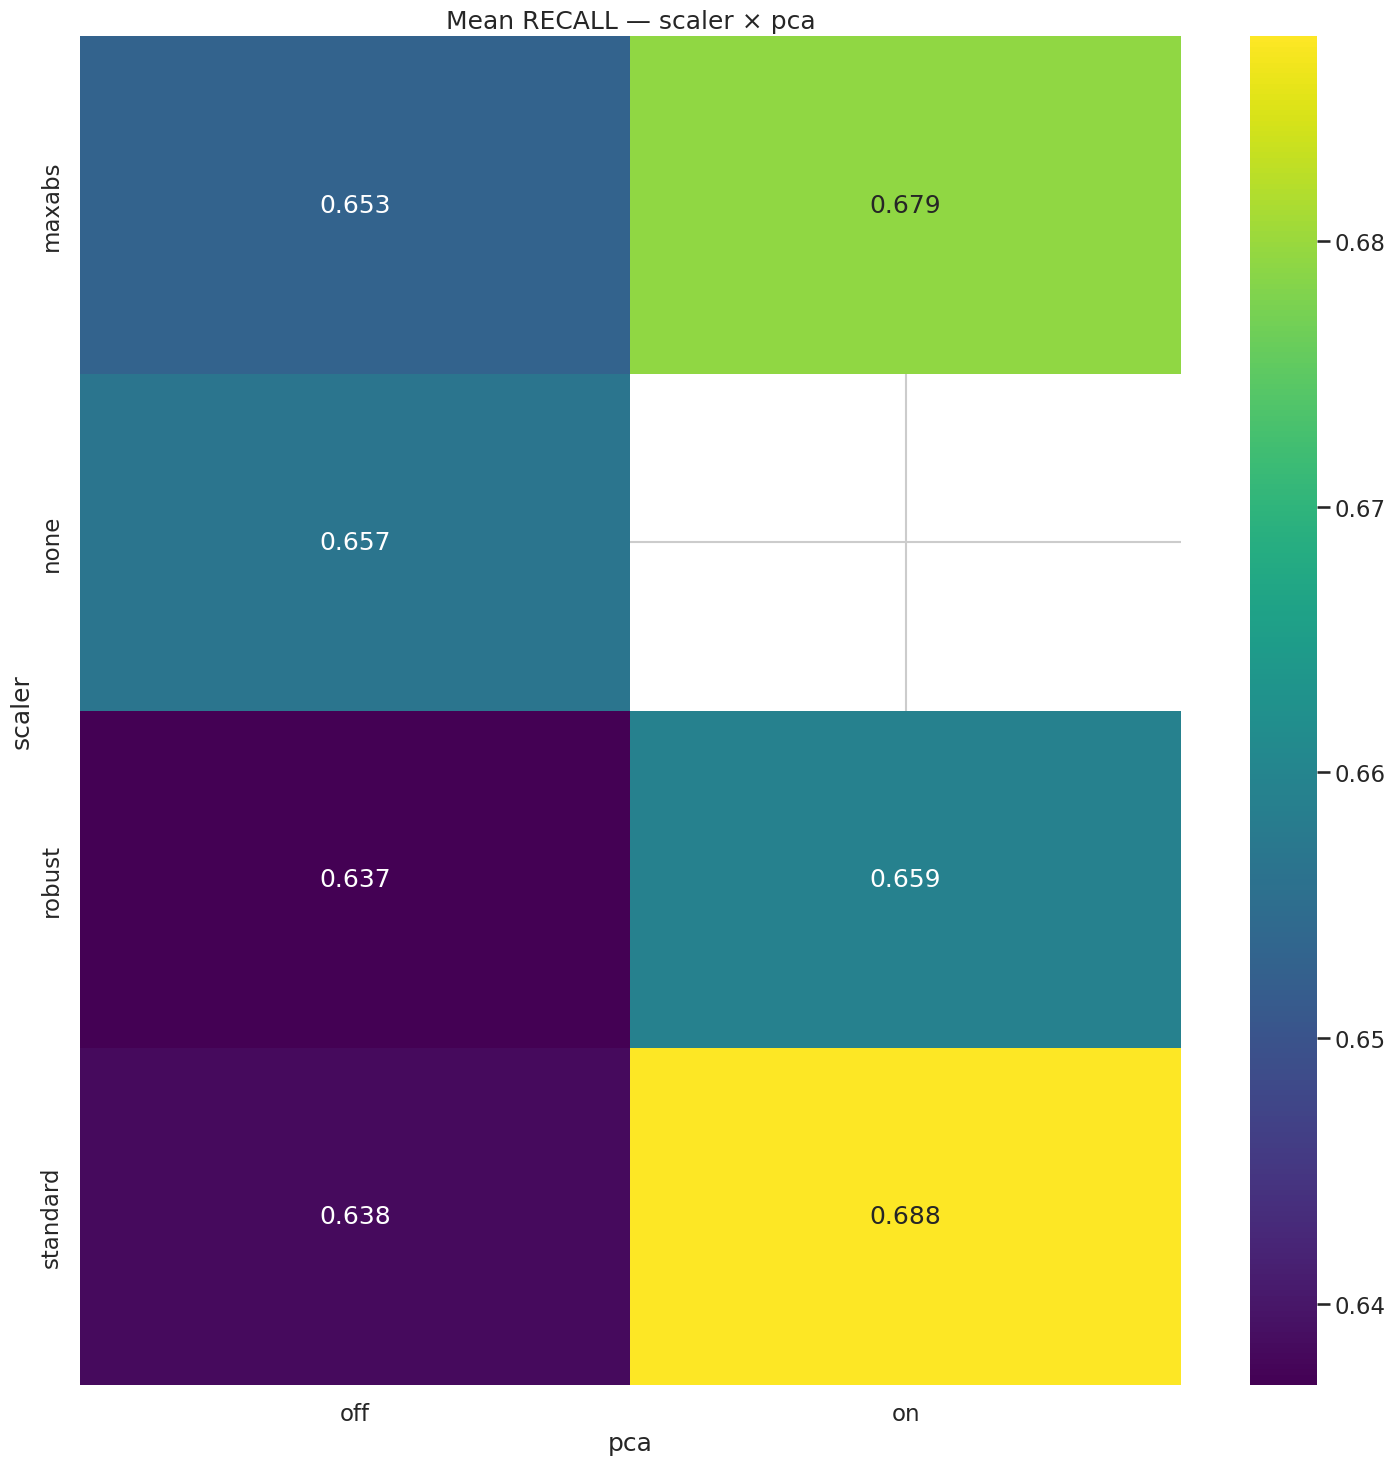

Saved: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/03_interaction_effects/heatmap_mean_recall_scaler_x_pca.png


In [27]:
metric_interaction_panels = [
    (MODEL_COL, RESAMPLING_COL),
    (SCALER_COL, PCA_COL),
]

for metric in AVAILABLE_METRICS:
    for row_factor, col_factor in metric_interaction_panels:
        panel = build_heatmap_table(analysis_df, row_factor, col_factor, metric, aggfunc="mean")
        plot_heatmap(
            panel,
            title=f"Mean {metric.upper()} — {row_factor} × {col_factor}",
            filename=f"heatmap_mean_{metric}_{row_factor}_x_{col_factor}",
            center=None,
            annot=True,
            fmt=".3f",
        )


## 9. Export concise results for downstream reporting

The following compact tables summarize the most directly reportable findings from this notebook.


In [28]:
report_tables = {}

# Best pairwise cell for each interaction
best_cells = []
for key, tbl in pairwise_tables.items():
    if tbl.empty:
        continue
    row_factor, col_factor = key.split("__")
    top = tbl.sort_values(["mean", "count"], ascending=[False, False]).iloc[0].to_dict()
    top["row_factor"] = row_factor
    top["col_factor"] = col_factor
    best_cells.append(top)

best_cells_df = pd.DataFrame(best_cells).sort_values(["mean", "count"], ascending=[False, False])
best_cells_df.to_csv(TABLES_DIR / "03_best_pairwise_cells.csv", index=False)
report_tables["best_pairwise_cells"] = best_cells_df

# Most context-sensitive contrasts
all_contrasts = []
for key, tbl in contrast_results.items():
    if tbl.empty:
        continue
    tbl = tbl.copy()
    tbl["contrast_key"] = key
    all_contrasts.append(tbl)

if all_contrasts:
    all_contrasts_df = pd.concat(all_contrasts, ignore_index=True)
    all_contrasts_df = all_contrasts_df.sort_values("delta_best_worst", ascending=False)
    all_contrasts_df.to_csv(TABLES_DIR / "03_all_context_contrasts.csv", index=False)
    report_tables["all_context_contrasts"] = all_contrasts_df

for name, tbl in report_tables.items():
    print("\n", "=" * 80)
    print(name)
    display(tbl.head(20))



best_pairwise_cells


,dataset_variant,scaler,mean,std,count,median,row_factor,col_factor,resampling,pca,model_key,config_name
3,NaN,standard,0.488630,0.116740,86592,0.494920,model_key,scaler,NaN,NaN,LogisticRegression,NaN
4,NaN,NaN,0.477228,0.133270,16400,0.483995,model_key,resampling,smote,NaN,LinearDiscriminantAnalysis_svd,NaN
9,NaN,NaN,0.467625,0.165523,11000,0.473206,config_name,model_key,NaN,NaN,LinearDiscriminantAnalysis_svd,config_strat80
5,NaN,NaN,0.456003,0.150066,227260,0.479996,model_key,pca,NaN,on,LogisticRegression,NaN
6,NaN,standard,0.423558,0.122590,110619,0.425912,scaler,resampling,undersample,NaN,NaN,NaN
7,NaN,standard,0.412886,0.133223,432061,0.411798,scaler,pca,NaN,on,NaN,NaN
0,IMPUTED,standard,0.411978,0.134019,299860,0.409890,dataset_variant,scaler,NaN,NaN,NaN,NaN
1,IMPUTED,NaN,0.407045,0.148627,178916,0.413518,dataset_variant,resampling,undersample,NaN,NaN,NaN
8,NaN,NaN,0.406373,0.118716,128222,0.412214,resampling,pca,undersample,off,NaN,NaN
2,STRICT,NaN,0.398200,0.110738,364634,0.407550,dataset_variant,pca,NaN,off,NaN,NaN



all_context_contrasts


,model_key,best_level,best_mean,best_std,best_count,worst_level,worst_mean,worst_std,worst_count,delta_best_worst,contrast_key,dataset_variant,config_name
18,NaN,LogisticRegression,0.457378,0.103030,132000,QuadraticDiscriminantAnalysis,0.325304,0.106475,66000,0.132074,config_name__model_key,NaN,config_kfold
19,NaN,LinearDiscriminantAnalysis_svd,0.467625,0.165523,11000,QuadraticDiscriminantAnalysis,0.340152,0.180897,33000,0.127472,config_name__model_key,NaN,config_strat80
20,NaN,LogisticRegression,0.446662,0.179349,66000,QuadraticDiscriminantAnalysis,0.321962,0.173480,33000,0.124700,config_name__model_key,NaN,config_random80
21,NaN,LogisticRegression,0.454609,0.081691,6548,QuadraticDiscriminantAnalysis,0.336464,0.081831,3220,0.118145,config_name__model_key,NaN,config_loo
0,SVC_linear,smote,0.456068,0.166233,91488,none,0.343480,0.157807,22860,0.112588,model_key__resampling,NaN,NaN
1,QuadraticDiscriminantAnalysis,undersample,0.361314,0.144494,24588,none,0.256756,0.176814,12236,0.104558,model_key__resampling,NaN,NaN
7,SVC_linear,standard,0.475148,0.126768,80817,maxabs,0.380205,0.221270,80203,0.094943,model_key__scaler,NaN,NaN
8,QuadraticDiscriminantAnalysis,standard,0.363130,0.120021,43296,maxabs,0.287095,0.170976,43216,0.076035,model_key__scaler,NaN,NaN
9,LogisticRegression,standard,0.488630,0.116740,86592,maxabs,0.420835,0.170931,86540,0.067795,model_key__scaler,NaN,NaN
2,LogisticRegression,smote,0.475329,0.144392,98400,none,0.410870,0.181278,24568,0.064459,model_key__resampling,NaN,NaN


## 10. Interpretation guide

When writing the Results section, the outputs of this notebook can support statements such as the following:

- Certain preprocessing decisions are only beneficial under specific model families.
- Some interactions show strong mean performance but poor support or high instability, suggesting caution.
- Top-performing combinations are enriched for a subset of factor levels, indicating non-random dominance.
- The effect of dataset representation, resampling, and dimensionality reduction is conditional rather than universal.

These conclusions should be cross-checked with the global performance overview from Notebook 01 and the marginal factor analyses from Notebook 02.
